In [1]:
import gc
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
ON0099_data_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/token_dwell_bq"
ON0099_data_paths = glob.glob(f"{ON0099_data_path}/*.npz")

ON0093_data_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0093/ON0093/result/dorado-070/intermediates/segmented_tokenized/token_dwell_bq"
ON0093_data_paths = glob.glob(f"{ON0093_data_path}/*.npz")

In [3]:
def read_data(data_paths):
    keys = ["kmer_token", "segment_len_arr", "signal_token"]
    data = {key: [] for key in keys}
    for data_path in tqdm.tqdm(data_paths):
        with np.load(data_path) as f:
            for key in keys:
                data[key].append(f[key])
    data = {key: np.concatenate(data[key]) for key in keys}
    return data

In [4]:
ON0093_data = read_data(np.random.choice(ON0093_data_paths,10000))
ON0099_data = read_data(np.random.choice(ON0099_data_paths,10000))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [13:12<00:00, 12.61it/s]


In [5]:
def get_signal_centre(segment_len_arr, signal_arr):
    return np.array_split(signal_arr[12:-12],np.cumsum(segment_len_arr*6))[8].mean()

def get_signal_centre_df(data):
    motif_list = []
    signal_centre_list = []
    
    for k in tqdm.tqdm(range(len(data["kmer_token"]))):
        motif = "".join([chr(x) for x in data["kmer_token"][k][6:-6]])
        signal_centre = get_signal_centre(data["segment_len_arr"][k], data["signal_token"][k])
        motif_list.append(motif)
        signal_centre_list.append(signal_centre)
    
    df = pd.DataFrame({"motif": motif_list, "signal_centre": signal_centre_list})
    return df
    

In [6]:
ON0093_signal_df = get_signal_centre_df(ON0093_data)
ON0099_signal_df = get_signal_centre_df(ON0099_data)

  1%|█▍                                                                                                                                                  | 74787/7720950 [00:04<07:13, 17648.99it/s]/tmp/ipykernel_74082/3788425444.py:2: RuntimeWarning: Mean of empty slice.
  return np.array_split(signal_arr[12:-12],np.cumsum(segment_len_arr*6))[8].mean()
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7732484/7732484 [07:59<00:00, 16140.66it/s]


In [7]:
ON0093_signal_df["index_ON0093"] = ON0093_signal_df.index
ON0099_signal_df["index_ON0099"] = ON0099_signal_df.index

ON0093_signal_df.rename(columns = {"signal_centre": "signal_centre_ON0093"}, inplace = True)
ON0099_signal_df.rename(columns = {"signal_centre": "signal_centre_ON0099"}, inplace = True)

In [10]:
## Find motifs that have at least 10 samples in both ON0093 and ON0099
ON0093_motif_count = ON0093_signal_df["motif"].value_counts()
ON0099_motif_count = ON0099_signal_df["motif"].value_counts()
motif_common = ON0093_motif_count.index.intersection(ON0099_motif_count.index)
motif_common = motif_common[(ON0093_motif_count[motif_common] >= 100) & (ON0099_motif_count[motif_common] >= 100)]
print(motif_common, len(motif_common))

Index(['CGCCACCUC', 'GCUCAGCCC', 'GCUCAACGC', 'GCUCAGCCA', 'CGCCACCAA',
       'CGCCACCGC', 'GGCCACCUC', 'GCUCAGCAC', 'AGCCACCUC', 'CAGCAUGGC',
       ...
       'ACCAAACGU', 'ACCGAACGC', 'UGUUAACUA', 'CUCCAUAUA', 'CGUUACACU',
       'CUGUAAACA', 'CCGUAUUGG', 'ACCUACUCC', 'ACCAAUUCC', 'AAACACGGC'],
      dtype='object', name='motif', length=21549) 21549


In [12]:
## Groupby 5mer and calculate mean signal
def get_motif_signal(df_dict, key = "5mer"):
    motif_dict = {}
    for k in df_dict.keys():
        df = df_dict[k]
        motif_df = df[["bq_centre", "signal_centre", "bq_avg", "signal_avg", key]].groupby(key).mean()
        motif_count_df = df[key].value_counts()
        motif_df = pd.merge(motif_df, motif_count_df, left_index = True, right_index = True)
        motif_dict[k] = motif_df
    return motif_dict

## Find motifs with largest discrepancy: ON0093 vs. ON0099
def get_discrepancy(df_dict, k1, k2, feature = "signal_avg", min_count = 100):
    merged_df = pd.merge(df_dict[k1][df_dict[k1]["count"] > min_count][[feature]],
                         df_dict[k2][df_dict[k2]["count"] > min_count][[feature]],
                         how = "inner", left_index = True, right_index = True).dropna()
    merged_df = merged_df[[f"{feature}_x", f"{feature}_y"]]
    merged_df.columns = [k1, k2]
    merged_df["discrepancy"] = (merged_df[k1] - merged_df[k2]).abs()
    merged_df = merged_df.sort_values("discrepancy", ascending = False)
    return merged_df


ON0093_df_norm_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0093/ON0093/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/temp.merged.light.pkl"
ON0099_df_norm_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/temp.merged.light.pkl"
ON0093_df_norm = pd.read_pickle(ON0093_df_norm_path)
ON0099_df_norm = pd.read_pickle(ON0099_df_norm_path)


df_dict = {"ON0093_norm": ON0093_df_norm, "ON0099_norm": ON0099_df_norm}
for df in df_dict.values():
    df["9mer"] = df["motif"].apply(lambda x: x[6:15])

dict_9mer = get_motif_signal(df_dict, key = "9mer")

discrepancy_df = get_discrepancy(dict_9mer, "ON0093_norm", "ON0099_norm", feature = "signal_centre")
print(discrepancy_df)

           ON0093_norm  ON0099_norm   discrepancy
9mer                                             
AGACAGACG    -0.293305     1.623121  1.916426e+00
AAACAGACG    -0.243384     1.649628  1.893012e+00
GAACAGUCC    -0.460429     1.417194  1.877623e+00
CCAGAGUCC    -0.048483     1.816082  1.864565e+00
CAACAGAUG     0.017523     1.878333  1.860810e+00
...                ...          ...           ...
GGUAAUCCA    -0.961555    -0.961542  1.267452e-05
UGGUAUGCC    -0.457865    -0.457877  1.211402e-05
GCGCACUGC    -0.033575    -0.033566  8.872534e-06
GUCGACGGC    -0.201281    -0.201279  1.643737e-06
UACAAUGCC    -0.356716    -0.356715  6.309868e-07

[34228 rows x 3 columns]


In [13]:
## only common motif from discrepancy_df
discrepancy_df = discrepancy_df[discrepancy_df.index.isin(motif_common)]
print(discrepancy_df)


           ON0093_norm  ON0099_norm   discrepancy
9mer                                             
GCUGAGUCC    -0.182018     1.638651  1.820669e+00
AAACAGACA    -0.025884     1.739035  1.764919e+00
CUUCAGUCC    -0.412376     1.332758  1.745134e+00
AAUCAGUCC    -0.350024     1.381722  1.731746e+00
CAACAGACG    -0.139401     1.581028  1.720429e+00
...                ...          ...           ...
AGCCAUAUU     0.116022     0.116005  1.662987e-05
UGGUAUGCC    -0.457865    -0.457877  1.211402e-05
GCGCACUGC    -0.033575    -0.033566  8.872534e-06
GUCGACGGC    -0.201281    -0.201279  1.643737e-06
UACAAUGCC    -0.356716    -0.356715  6.309868e-07

[18641 rows x 3 columns]


In [15]:
discrepancy_df[:30]

,ON0093_norm,ON0099_norm,discrepancy
9mer,,,
GCUGAGUCC,-0.182018,1.638651,1.820669
AAACAGACA,-0.025884,1.739035,1.764919
CUUCAGUCC,-0.412376,1.332758,1.745134
AAUCAGUCC,-0.350024,1.381722,1.731746
CAACAGACG,-0.139401,1.581028,1.720429
UGGCAGACG,-0.045315,1.672104,1.717419
AGUCAGUCC,-0.326989,1.375543,1.702532
GGCCAGACC,0.031804,1.732957,1.701153
UGUCAGUCC,-0.379589,1.295333,1.674922


In [17]:
print(ON0099_signal_df)

             motif  signal_centre_ON0099  index_ON0099
0        GGAGAGCAA              2.025676             0
1        GGUUACUAA             -0.474209             1
2        CCUGAACCA             -0.365406             2
3        CCGGAGCCC              1.541374             3
4        AUCGAGUUC              0.923874             4
...            ...                   ...           ...
7732479  CCACAUCGU             -0.528611       7732479
7732480  GUGCAAAGA              1.857156       7732480
7732481  GCCUAACUG              0.151942       7732481
7732482  UCACAUAUU             -0.007839       7732482
7732483  CCUGAGUCG              1.031179       7732483

[7732484 rows x 3 columns]


In [22]:
ON0099_grouped = ON0099_signal_df.groupby("motif")
ON0093_grouped = ON0093_signal_df.groupby("motif")

max_pair_dict = {}
min_pair_dict = {}

for motif in tqdm.tqdm(discrepancy_df.index[:10]):
    ON0093_df = ON0093_grouped.get_group(motif)
    ON0099_df = ON0099_grouped.get_group(motif)
    ## Find 5 pairs with the largest discrepancy and 5 pairs with the smallest discrepancy
    ON0093_min_5 = ON0093_df.sort_values("signal_centre_ON0093").head(5)
    ON0099_max_5 = ON0099_df.sort_values("signal_centre_ON0099", ascending = False).head(5)
    idx_tuple = [(ON0099_max_5.index[i], ON0093_min_5.index[i], ON0099_max_5.iloc[i]["signal_centre_ON0099"], ON0093_min_5.iloc[i]["signal_centre_ON0093"]) for i in range(5)]
    pair_df = pd.DataFrame(idx_tuple, columns = ["index_ON0099", "index_ON0093", "signal_centre_ON0099", "signal_centre_ON0093"])
    max_pair_dict[motif] = pair_df
    
    model_value = discrepancy_df.loc[motif]["ON0093_norm"]
    ## Find closest 5 pairs to the model value
    ON0093_df["deviation"] = (ON0093_df["signal_centre_ON0093"] - model_value).abs()
    ON0099_df["deviation"] = (ON0099_df["signal_centre_ON0099"] - model_value).abs()
    ON0093_closest_5 = ON0093_df.sort_values("deviation").head(5)
    ON0099_closest_5 = ON0099_df.sort_values("deviation").head(5)
    
    idx_tuple = [(ON0099_closest_5.index[i], ON0093_closest_5.index[i], ON0099_closest_5.iloc[i]["signal_centre_ON0099"], ON0093_closest_5.iloc[i]["signal_centre_ON0093"]) for i in range(5)]
    pair_df = pd.DataFrame(idx_tuple, columns = ["index_ON0099", "index_ON0093", "signal_centre_ON0099", "signal_centre_ON0093"])
    min_pair_dict[motif] = pair_df
    
    
    

  0%|                                                                                                                                                                        | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_74082/313861340.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ON0093_df["deviation"] = (ON0093_df["signal_centre_ON0093"] - model_value).abs()
/tmp/ipykernel_74082/313861340.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ON0099_df["deviation"] = (ON0099_df["signal_centre_ON0099"] - model

In [133]:
discrepancy_df_rev = discrepancy_df.copy()
discrepancy_df_rev["discrepancy"] = discrepancy_df_rev["ON0093_norm"] - discrepancy_df_rev["ON0099_norm"]
discrepancy_df_rev = discrepancy_df_rev.sort_values("discrepancy", ascending = False)
print(discrepancy_df_rev)

           ON0093_norm  ON0099_norm  discrepancy
9mer                                            
CCGGACGAC    -0.145599    -0.624830     0.479231
GCAGACGAC    -0.142623    -0.596801     0.454178
CCAGACGUA    -0.303663    -0.742146     0.438483
CCGGACGUA    -0.348616    -0.760123     0.411507
CAGGACGUA    -0.356643    -0.766096     0.409453
...                ...          ...          ...
CAACAGACG    -0.139401     1.581028    -1.720429
AAUCAGUCC    -0.350024     1.381722    -1.731746
CUUCAGUCC    -0.412376     1.332758    -1.745134
AAACAGACA    -0.025884     1.739035    -1.764919
GCUGAGUCC    -0.182018     1.638651    -1.820669

[18641 rows x 3 columns]


In [138]:

max_pair_dict_rev = {}
min_pair_dict_rev = {}

for motif in tqdm.tqdm(discrepancy_df_rev.index[:10]):
    ON0093_df = ON0093_grouped.get_group(motif)
    ON0099_df = ON0099_grouped.get_group(motif)
    ## Find 5 pairs with the largest discrepancy and 5 pairs with the smallest discrepancy
    ON0093_min_5 = ON0093_df.sort_values("signal_centre_ON0093", ascending = False).head(5)
    ON0099_max_5 = ON0099_df.sort_values("signal_centre_ON0099").head(5)
    idx_tuple = [(ON0099_max_5.index[i], ON0093_min_5.index[i], ON0099_max_5.iloc[i]["signal_centre_ON0099"], ON0093_min_5.iloc[i]["signal_centre_ON0093"]) for i in range(5)]
    pair_df = pd.DataFrame(idx_tuple, columns = ["index_ON0099", "index_ON0093", "signal_centre_ON0099", "signal_centre_ON0093"])
    max_pair_dict_rev[motif] = pair_df

    model_value = discrepancy_df.loc[motif]["ON0099_norm"]
    ## Find closest 5 pairs to the model value
    ON0093_df["deviation"] = (ON0093_df["signal_centre_ON0093"] - model_value).abs()
    ON0099_df["deviation"] = (ON0099_df["signal_centre_ON0099"] - model_value).abs()
    ON0093_closest_5 = ON0093_df.sort_values("deviation").head(5)
    ON0099_closest_5 = ON0099_df.sort_values("deviation").head(5)

    idx_tuple = [(ON0099_closest_5.index[i], ON0093_closest_5.index[i], ON0099_closest_5.iloc[i]["signal_centre_ON0099"], ON0093_closest_5.iloc[i]["signal_centre_ON0093"]) for i in range(5)]
    pair_df = pd.DataFrame(idx_tuple, columns = ["index_ON0099", "index_ON0093", "signal_centre_ON0099", "signal_centre_ON0093"])
    min_pair_dict_rev[motif] = pair_df




  0%|                                                                                                                                                                        | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_74082/1937217813.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ON0093_df["deviation"] = (ON0093_df["signal_centre_ON0093"] - model_value).abs()
/tmp/ipykernel_74082/1937217813.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ON0099_df["deviation"] = (ON0099_df["signal_centre_ON0099"] - mod

In [29]:
def plot_signal(ax, data, k):
    segment_len_arr = data["segment_len_arr"][k]
    signal_arr = data["signal_token"][k]
    motif = data["kmer_token"][k]
    motif = "".join([chr(i) for i in motif])[2:-2]
    end = int(np.sum(segment_len_arr)*6+12)
    signal_arr = signal_arr[12:end]
    ax.plot(signal_arr)
    ## Vline at the segment_len_arr 
    for n, i in enumerate(np.concatenate([[0],np.cumsum(segment_len_arr*6).astype(int)])):
        ax.axvline(i, color="k")
        if n < len(segment_len_arr):
            ax.text(i, 1.5, f"{n+1}\n{motif[n]}")
    ax.set_ylim(-3,3)


In [47]:
def get_center_signal(segment_len_arr, signal_arr):
    return np.array_split(signal_arr[12:-12],np.cumsum(segment_len_arr*6))[8]

In [120]:
def plot_center_signal(ax, data, k, color):
    segment_len_arr = data["segment_len_arr"][k]
    signal_arr = data["signal_token"][k]
    signal_arr = get_center_signal(segment_len_arr, signal_arr)
    ## signal mean as dashed horizontal line
    ax.axhline(signal_arr.mean(), color = "k", ls = "--", lw = 2)
    ax.axvline(len(signal_arr)-1, color = "k", ls = "--", lw = 2)
    ax.plot(signal_arr, color = color, lw = 4)
    ax.set_title(f"Mean={signal_arr.mean():.2f}, Std={signal_arr.std():.2f}, Len={len(signal_arr)}")
    return signal_arr


In [121]:
def plot_motif(title, ON0093_index, ON0099_index, xlim = None, ylim = None):
    fig, axes = plt.subplots(5, 2, figsize = (20,20))
    signal_list = []
    for i in range(5):
        signal_arr = plot_center_signal(axes[i, 0], ON0093_data, ON0093_index[i], "royalblue")
        signal_list.append(signal_arr)
        signal_arr = plot_center_signal(axes[i, 1], ON0099_data, ON0099_index[i], "tomato")
        signal_list.append(signal_arr)
    if xlim is None:    
        signal_len_max = max([len(signal) for signal in signal_list])
        xlim = (0, signal_len_max)
    
    if ylim is None:
        signal_max = np.max(np.concatenate(signal_list))
        signal_min = np.min(np.concatenate(signal_list))
        ylim = (signal_min, signal_max)
    
    
    for ax in axes.flatten():
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
    
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    
    return xlim, ylim


In [122]:
motifs = list(max_pair_dict.keys())

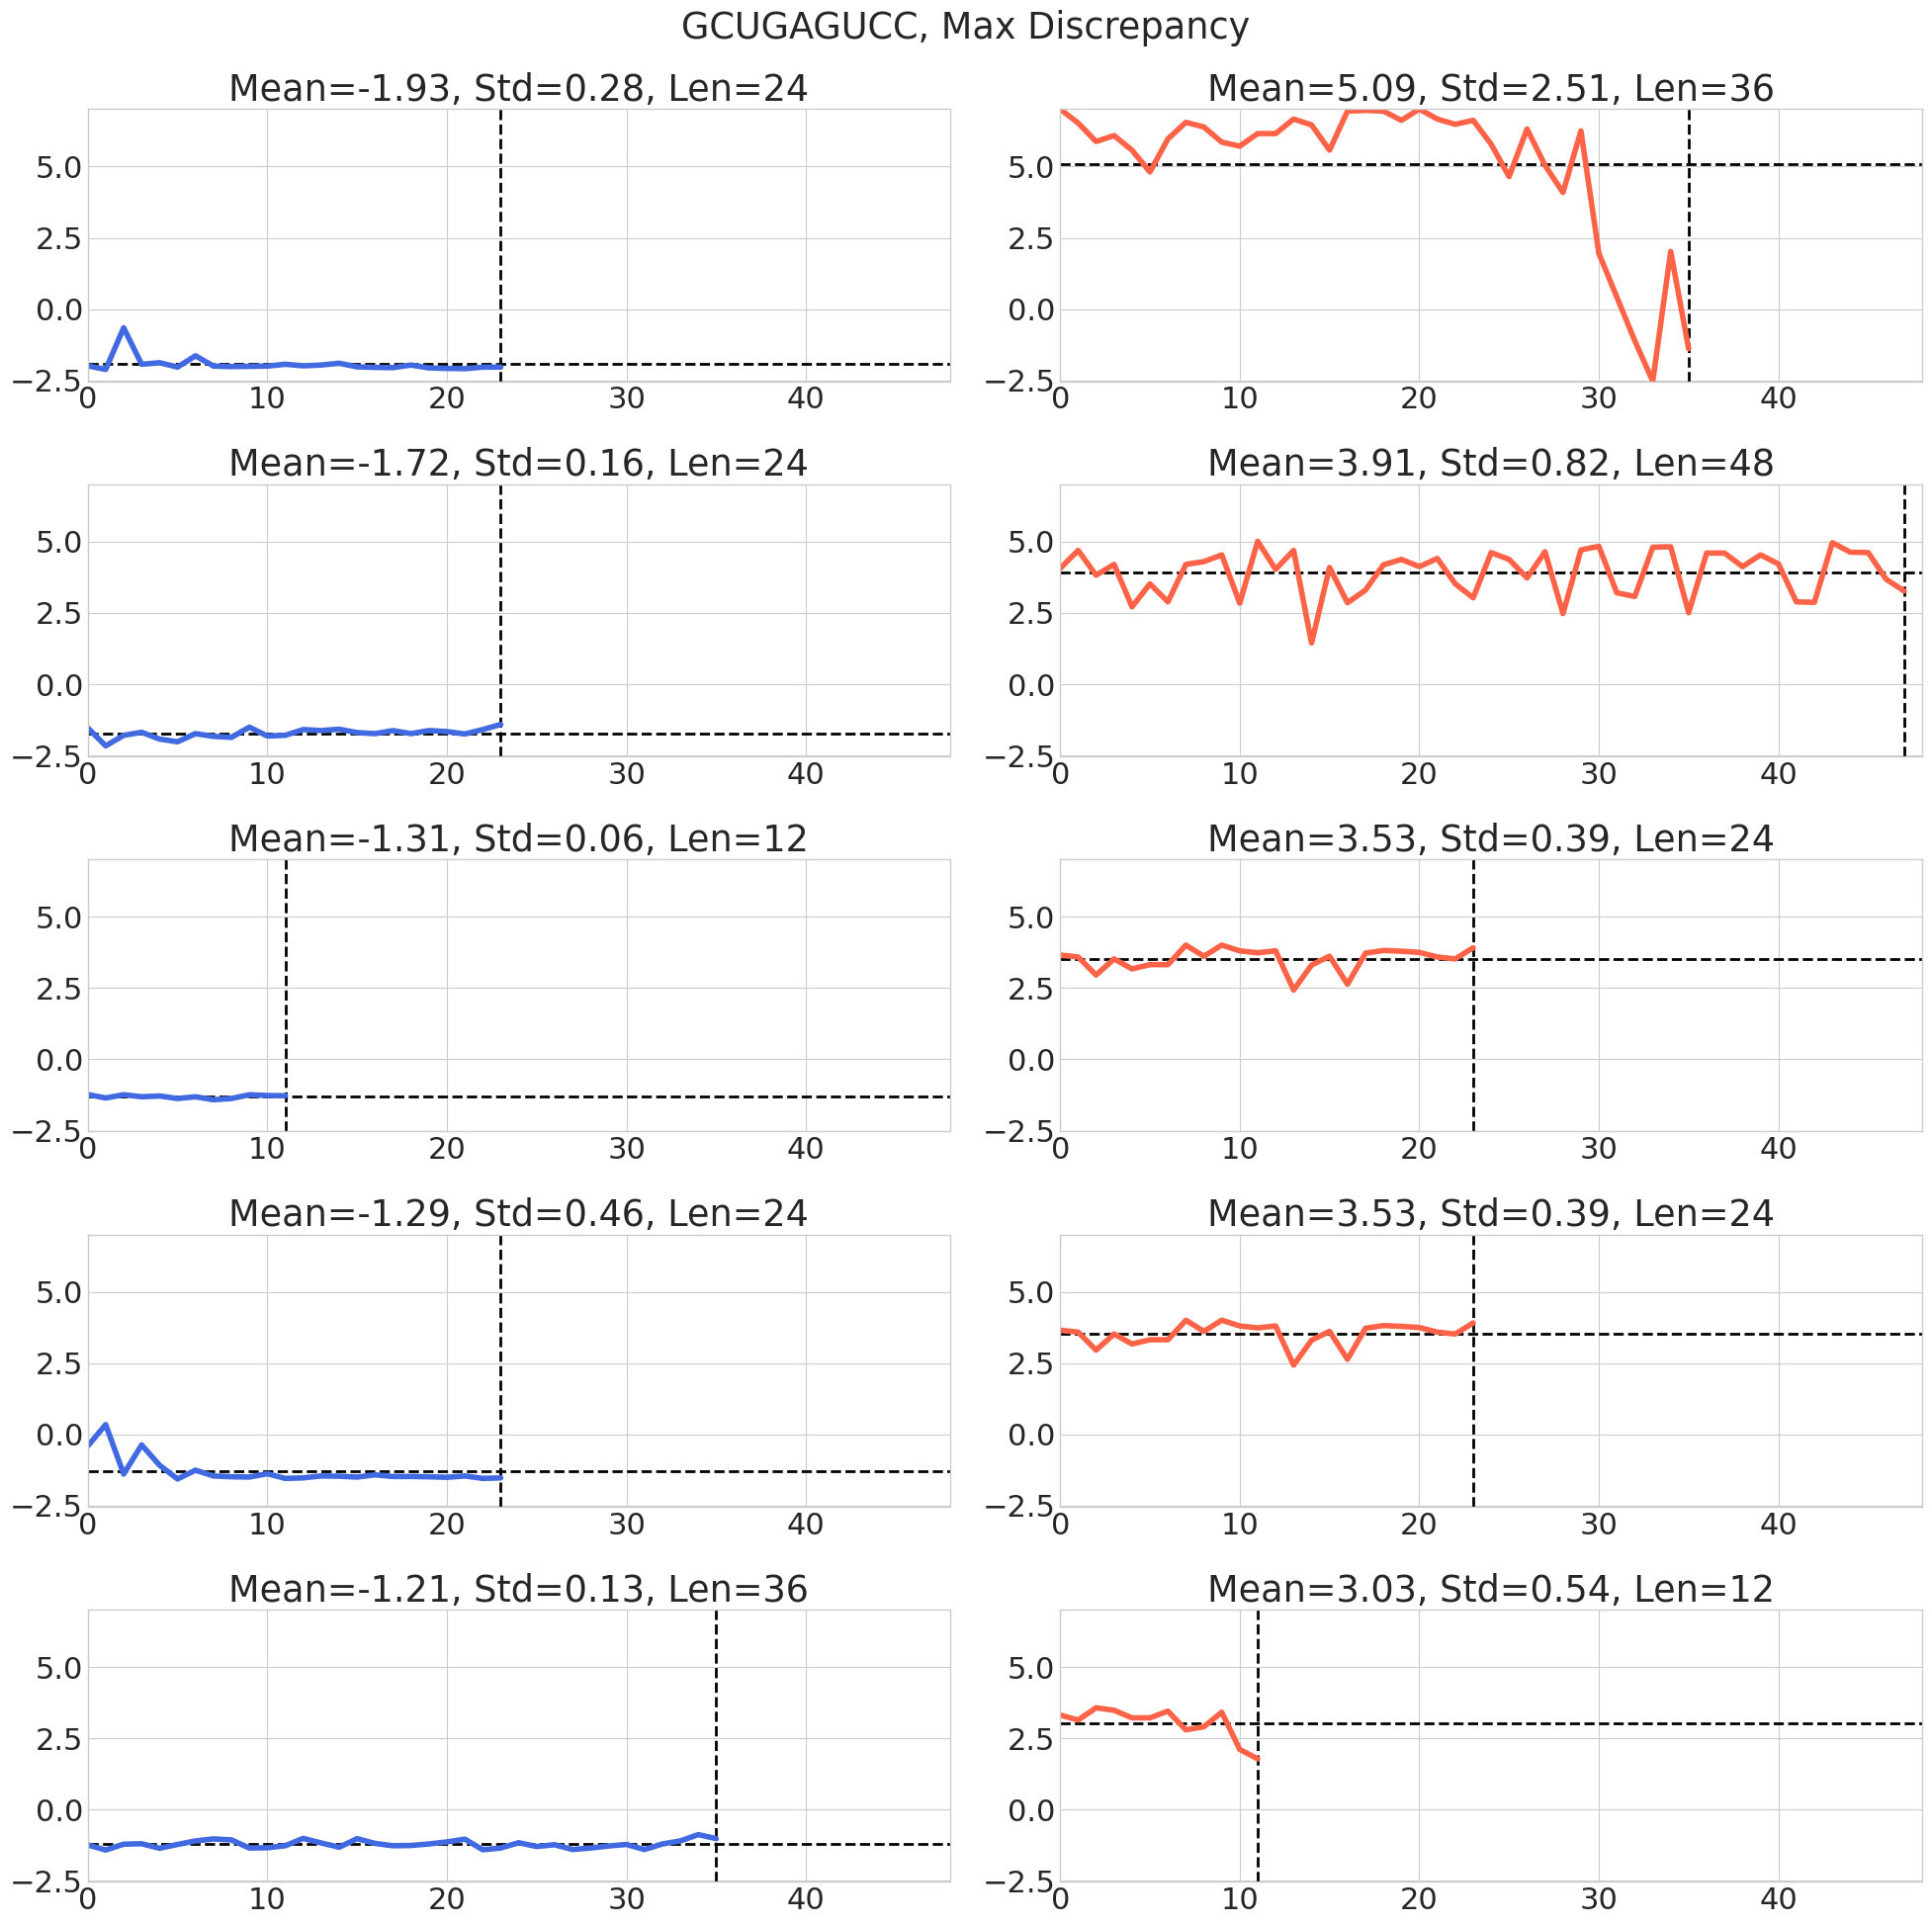

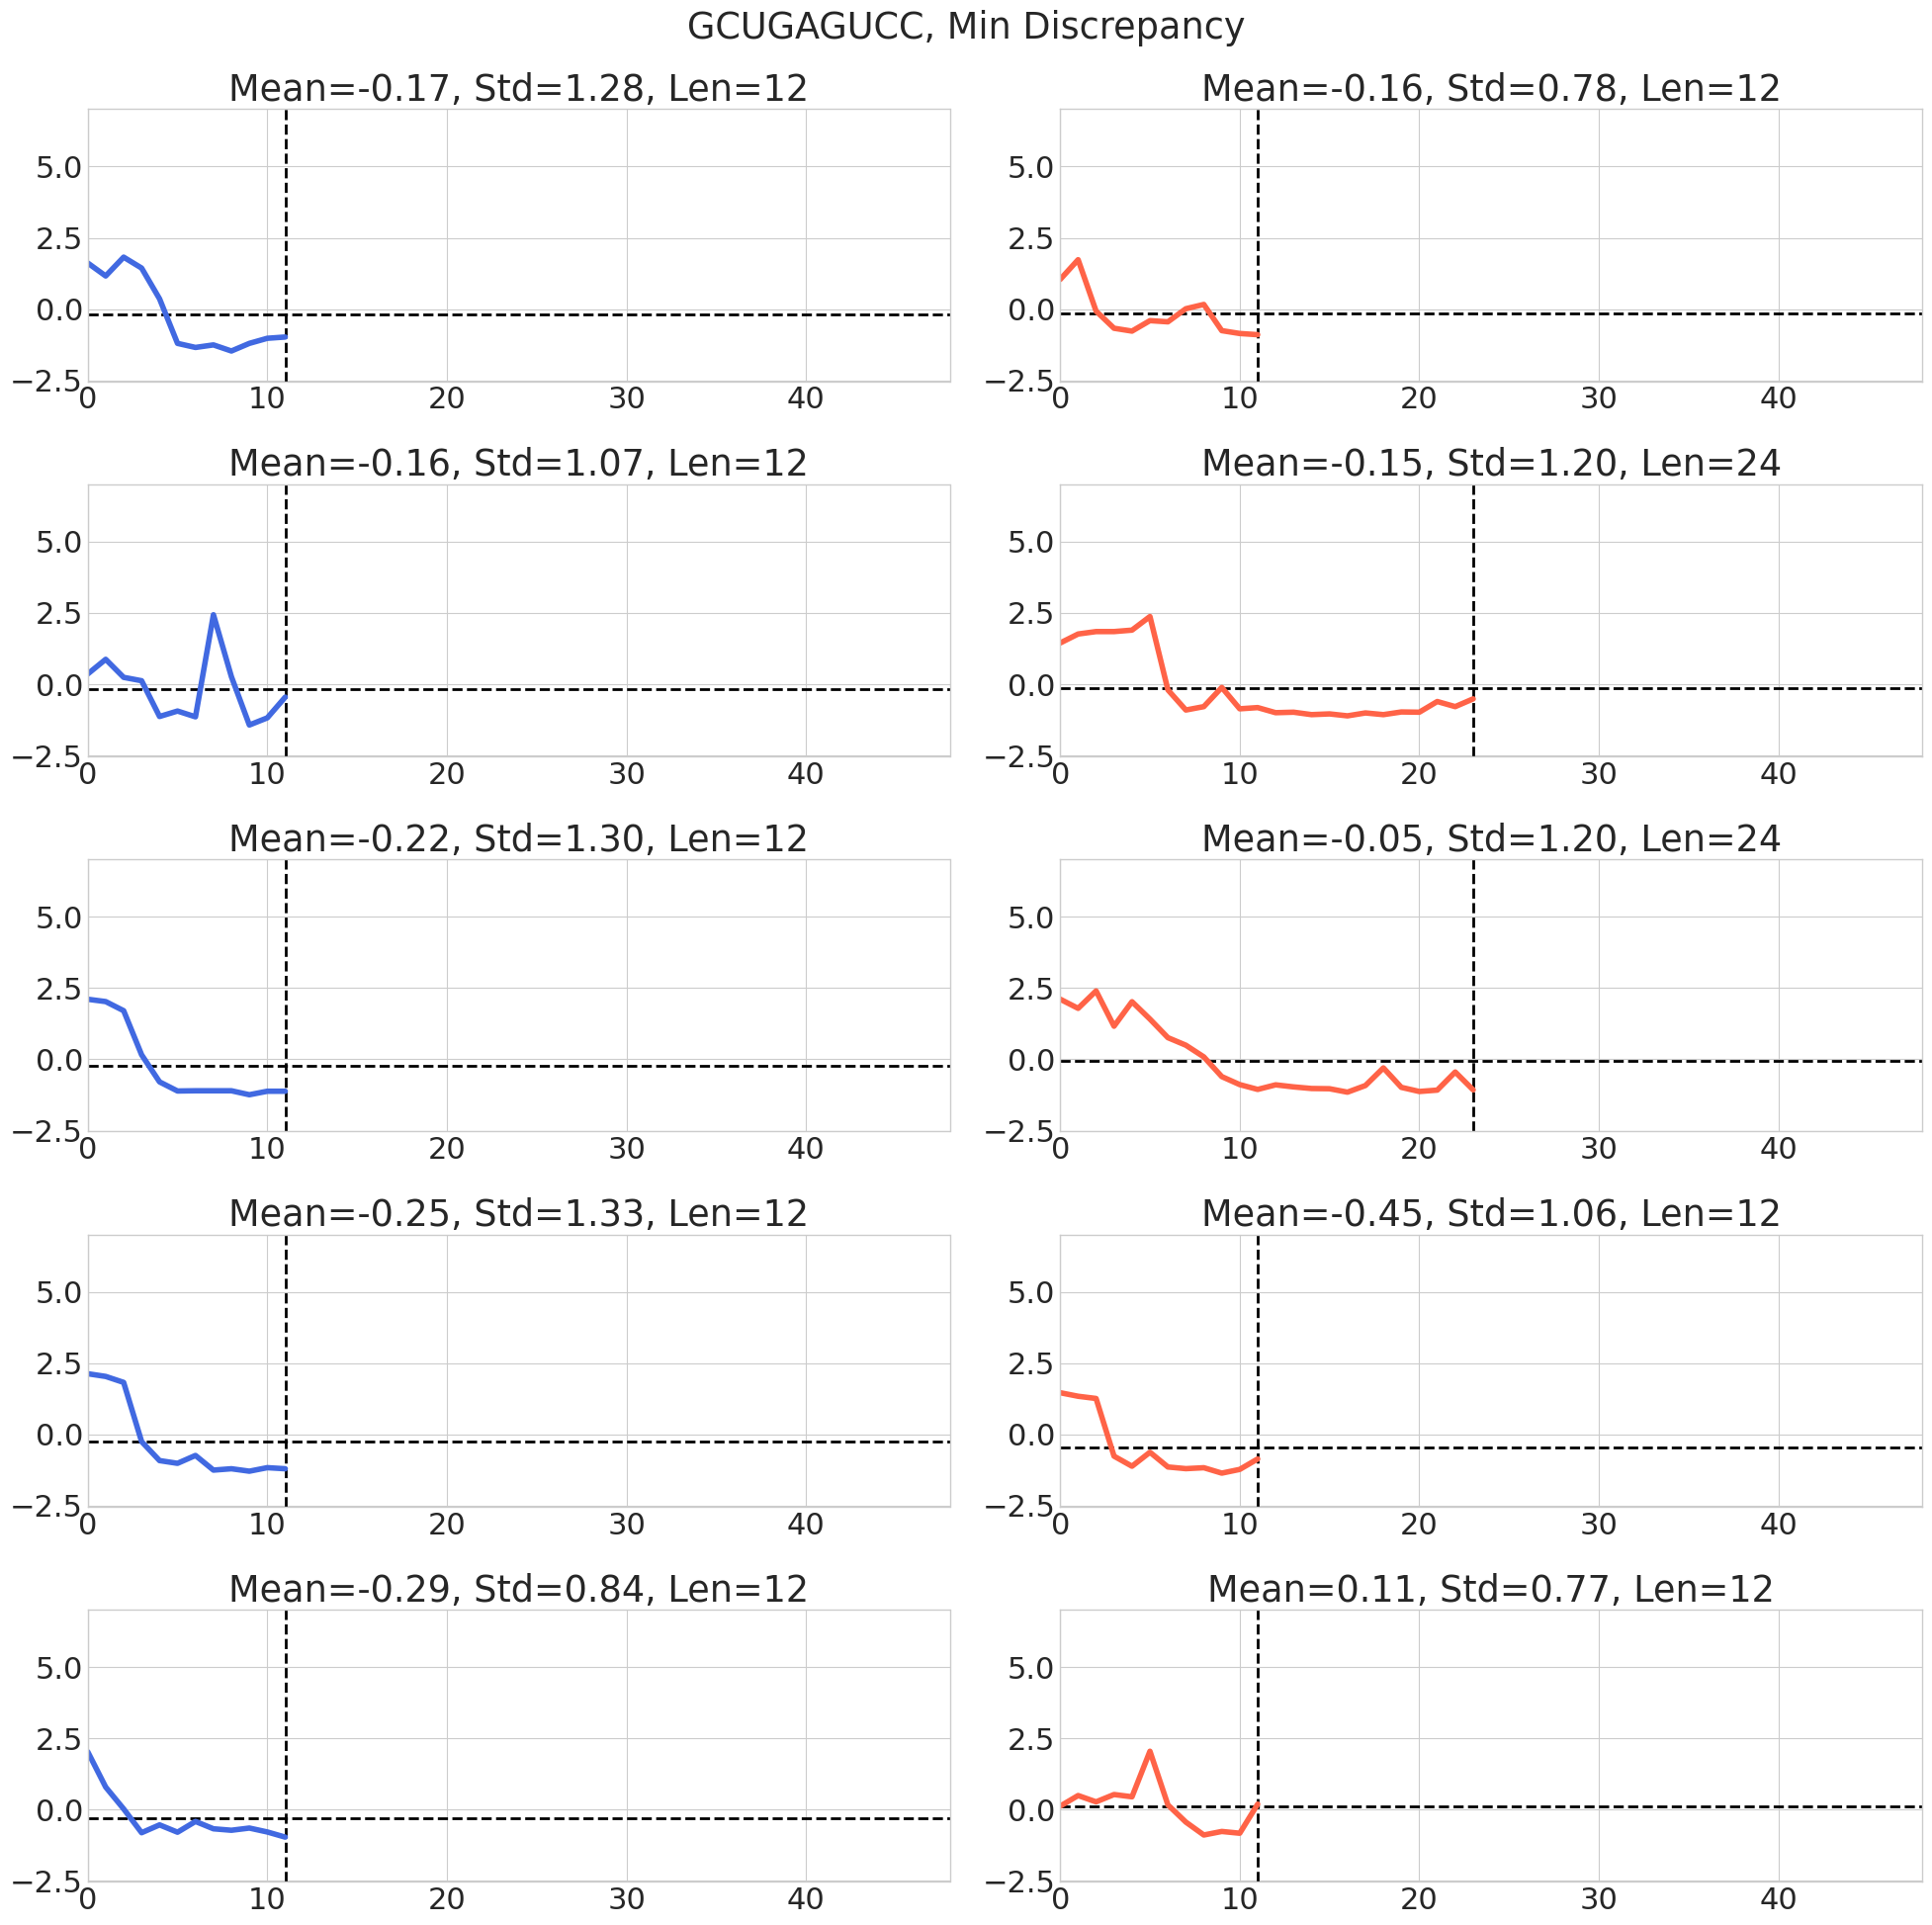

((0, 48), (-2.527049, 7.015556))

In [123]:
i = 0
xlim, ylim = plot_motif(motifs[i]+", Max Discrepancy", max_pair_dict[motifs[i]]["index_ON0093"], max_pair_dict[motifs[i]]["index_ON0099"])
plot_motif(motifs[i]+", Min Discrepancy", min_pair_dict[motifs[i]]["index_ON0093"], min_pair_dict[motifs[i]]["index_ON0099"],xlim, ylim)

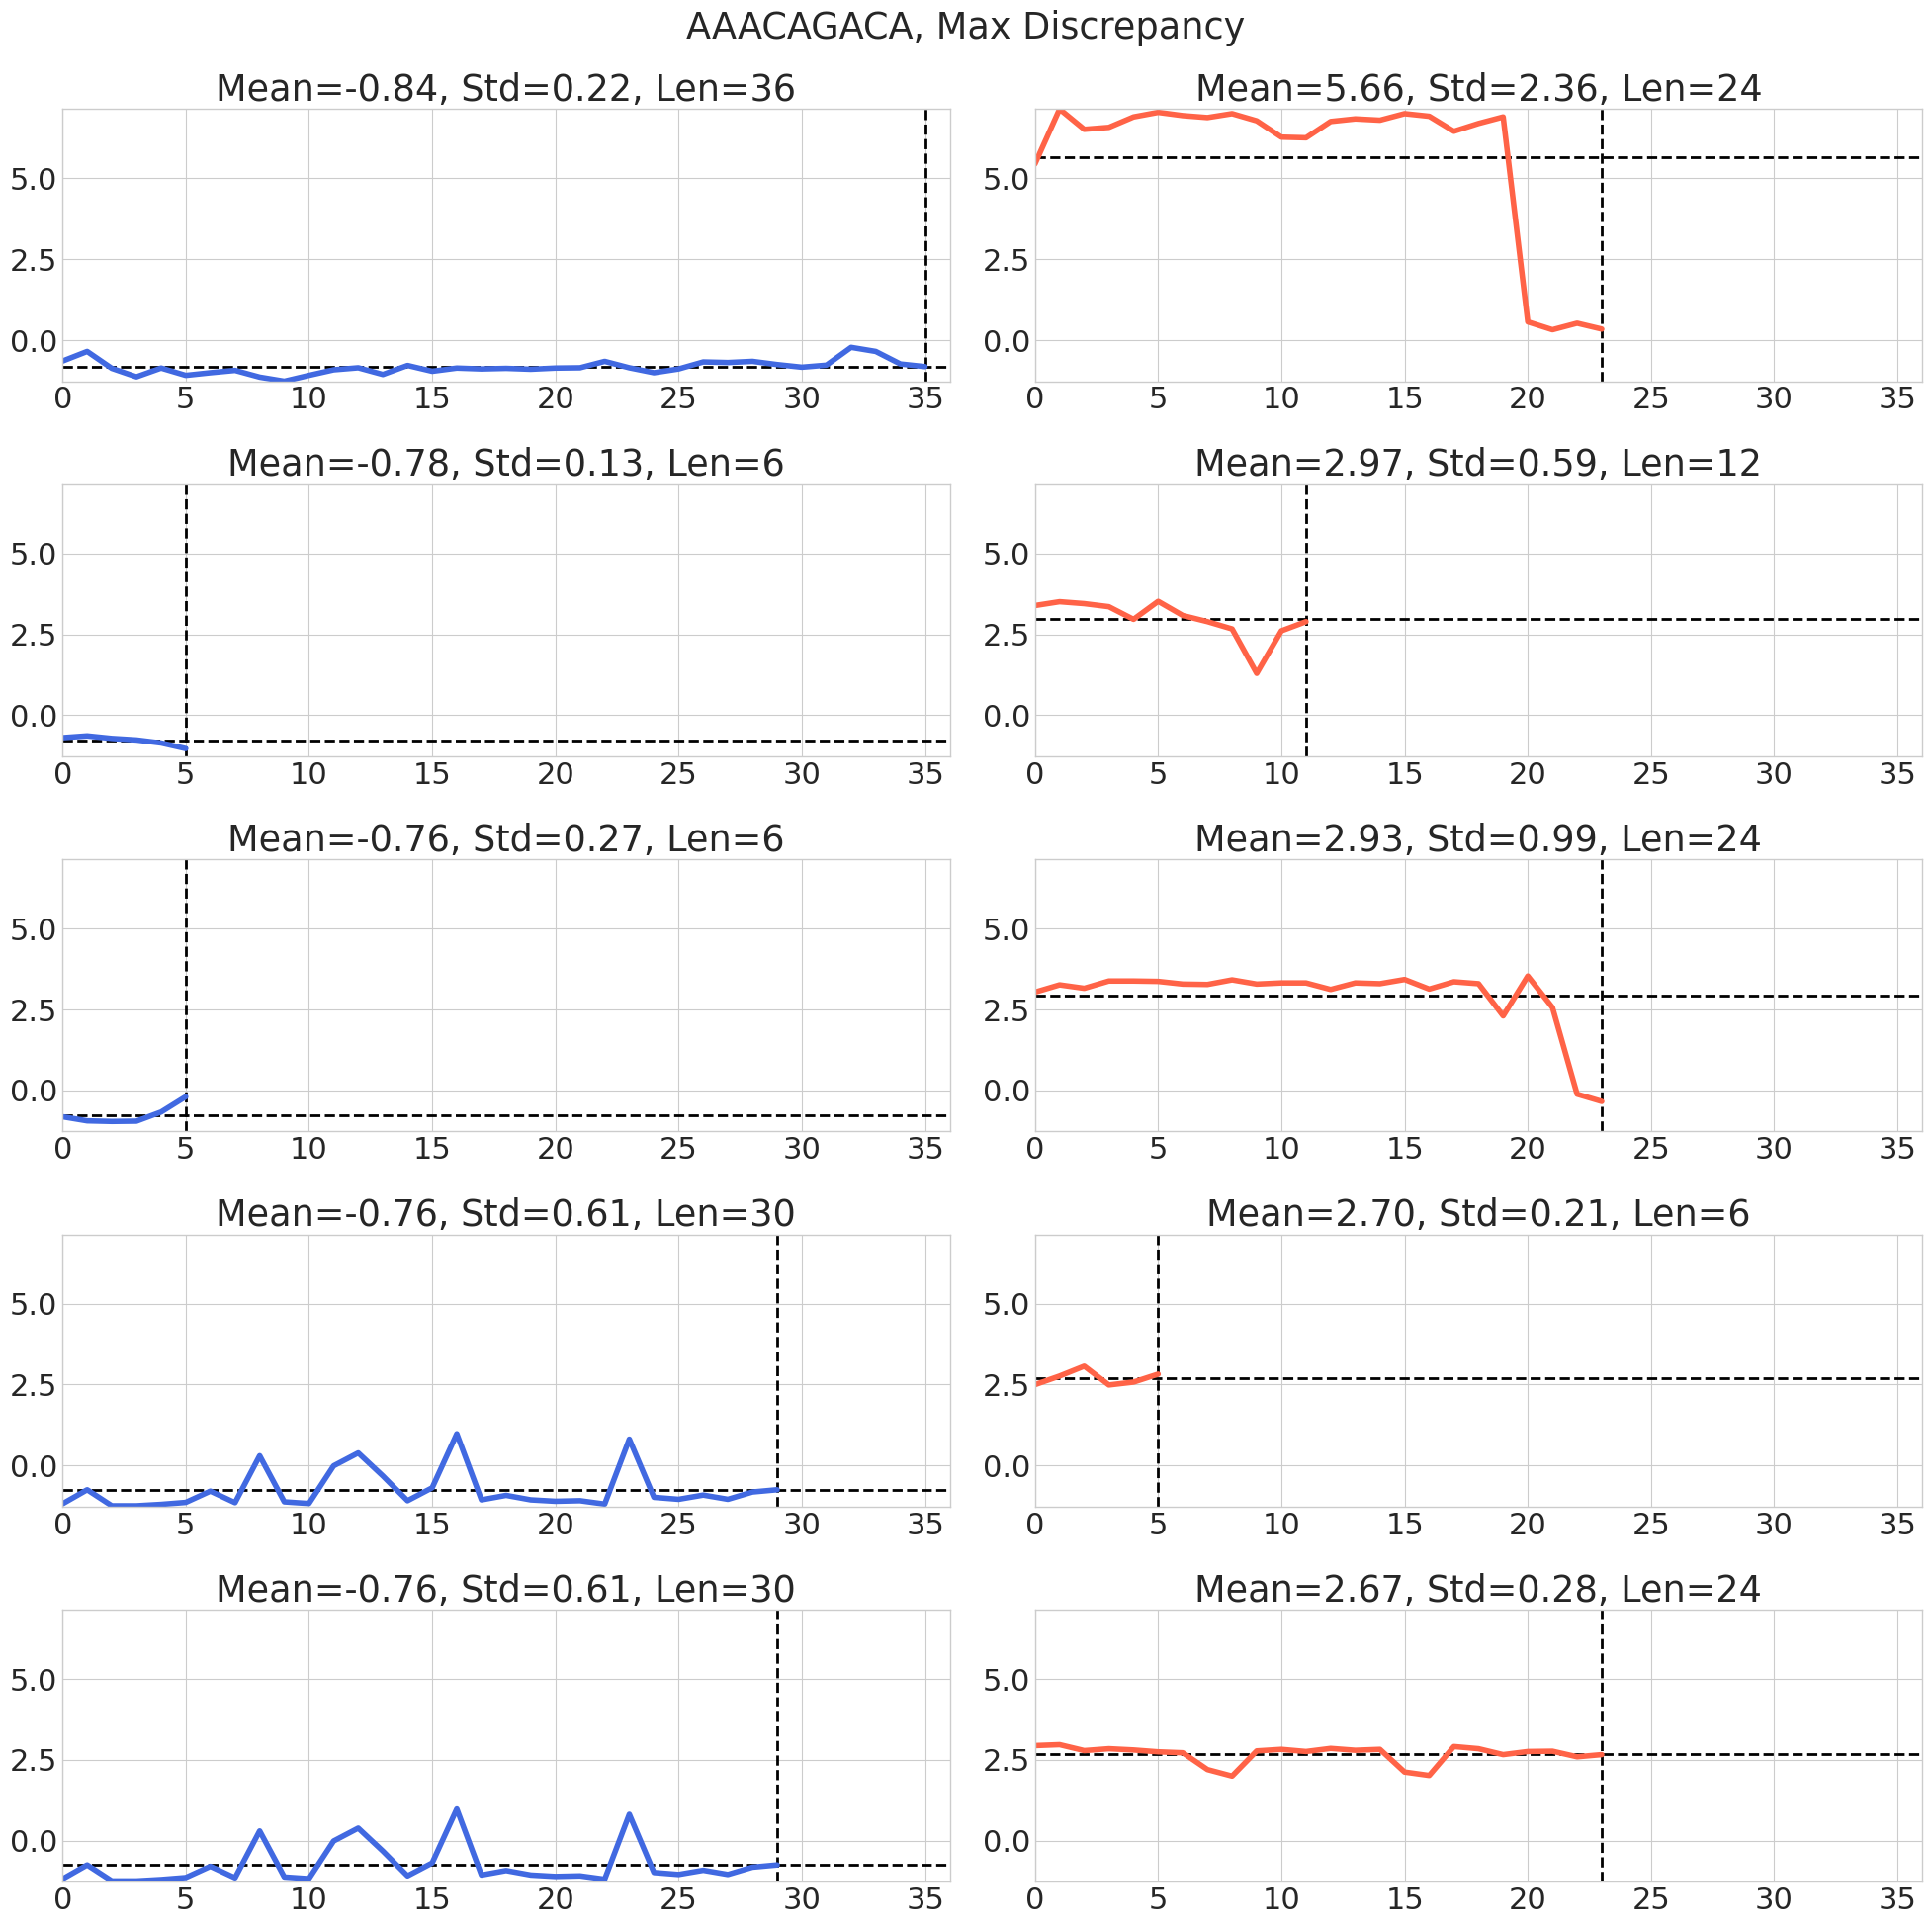

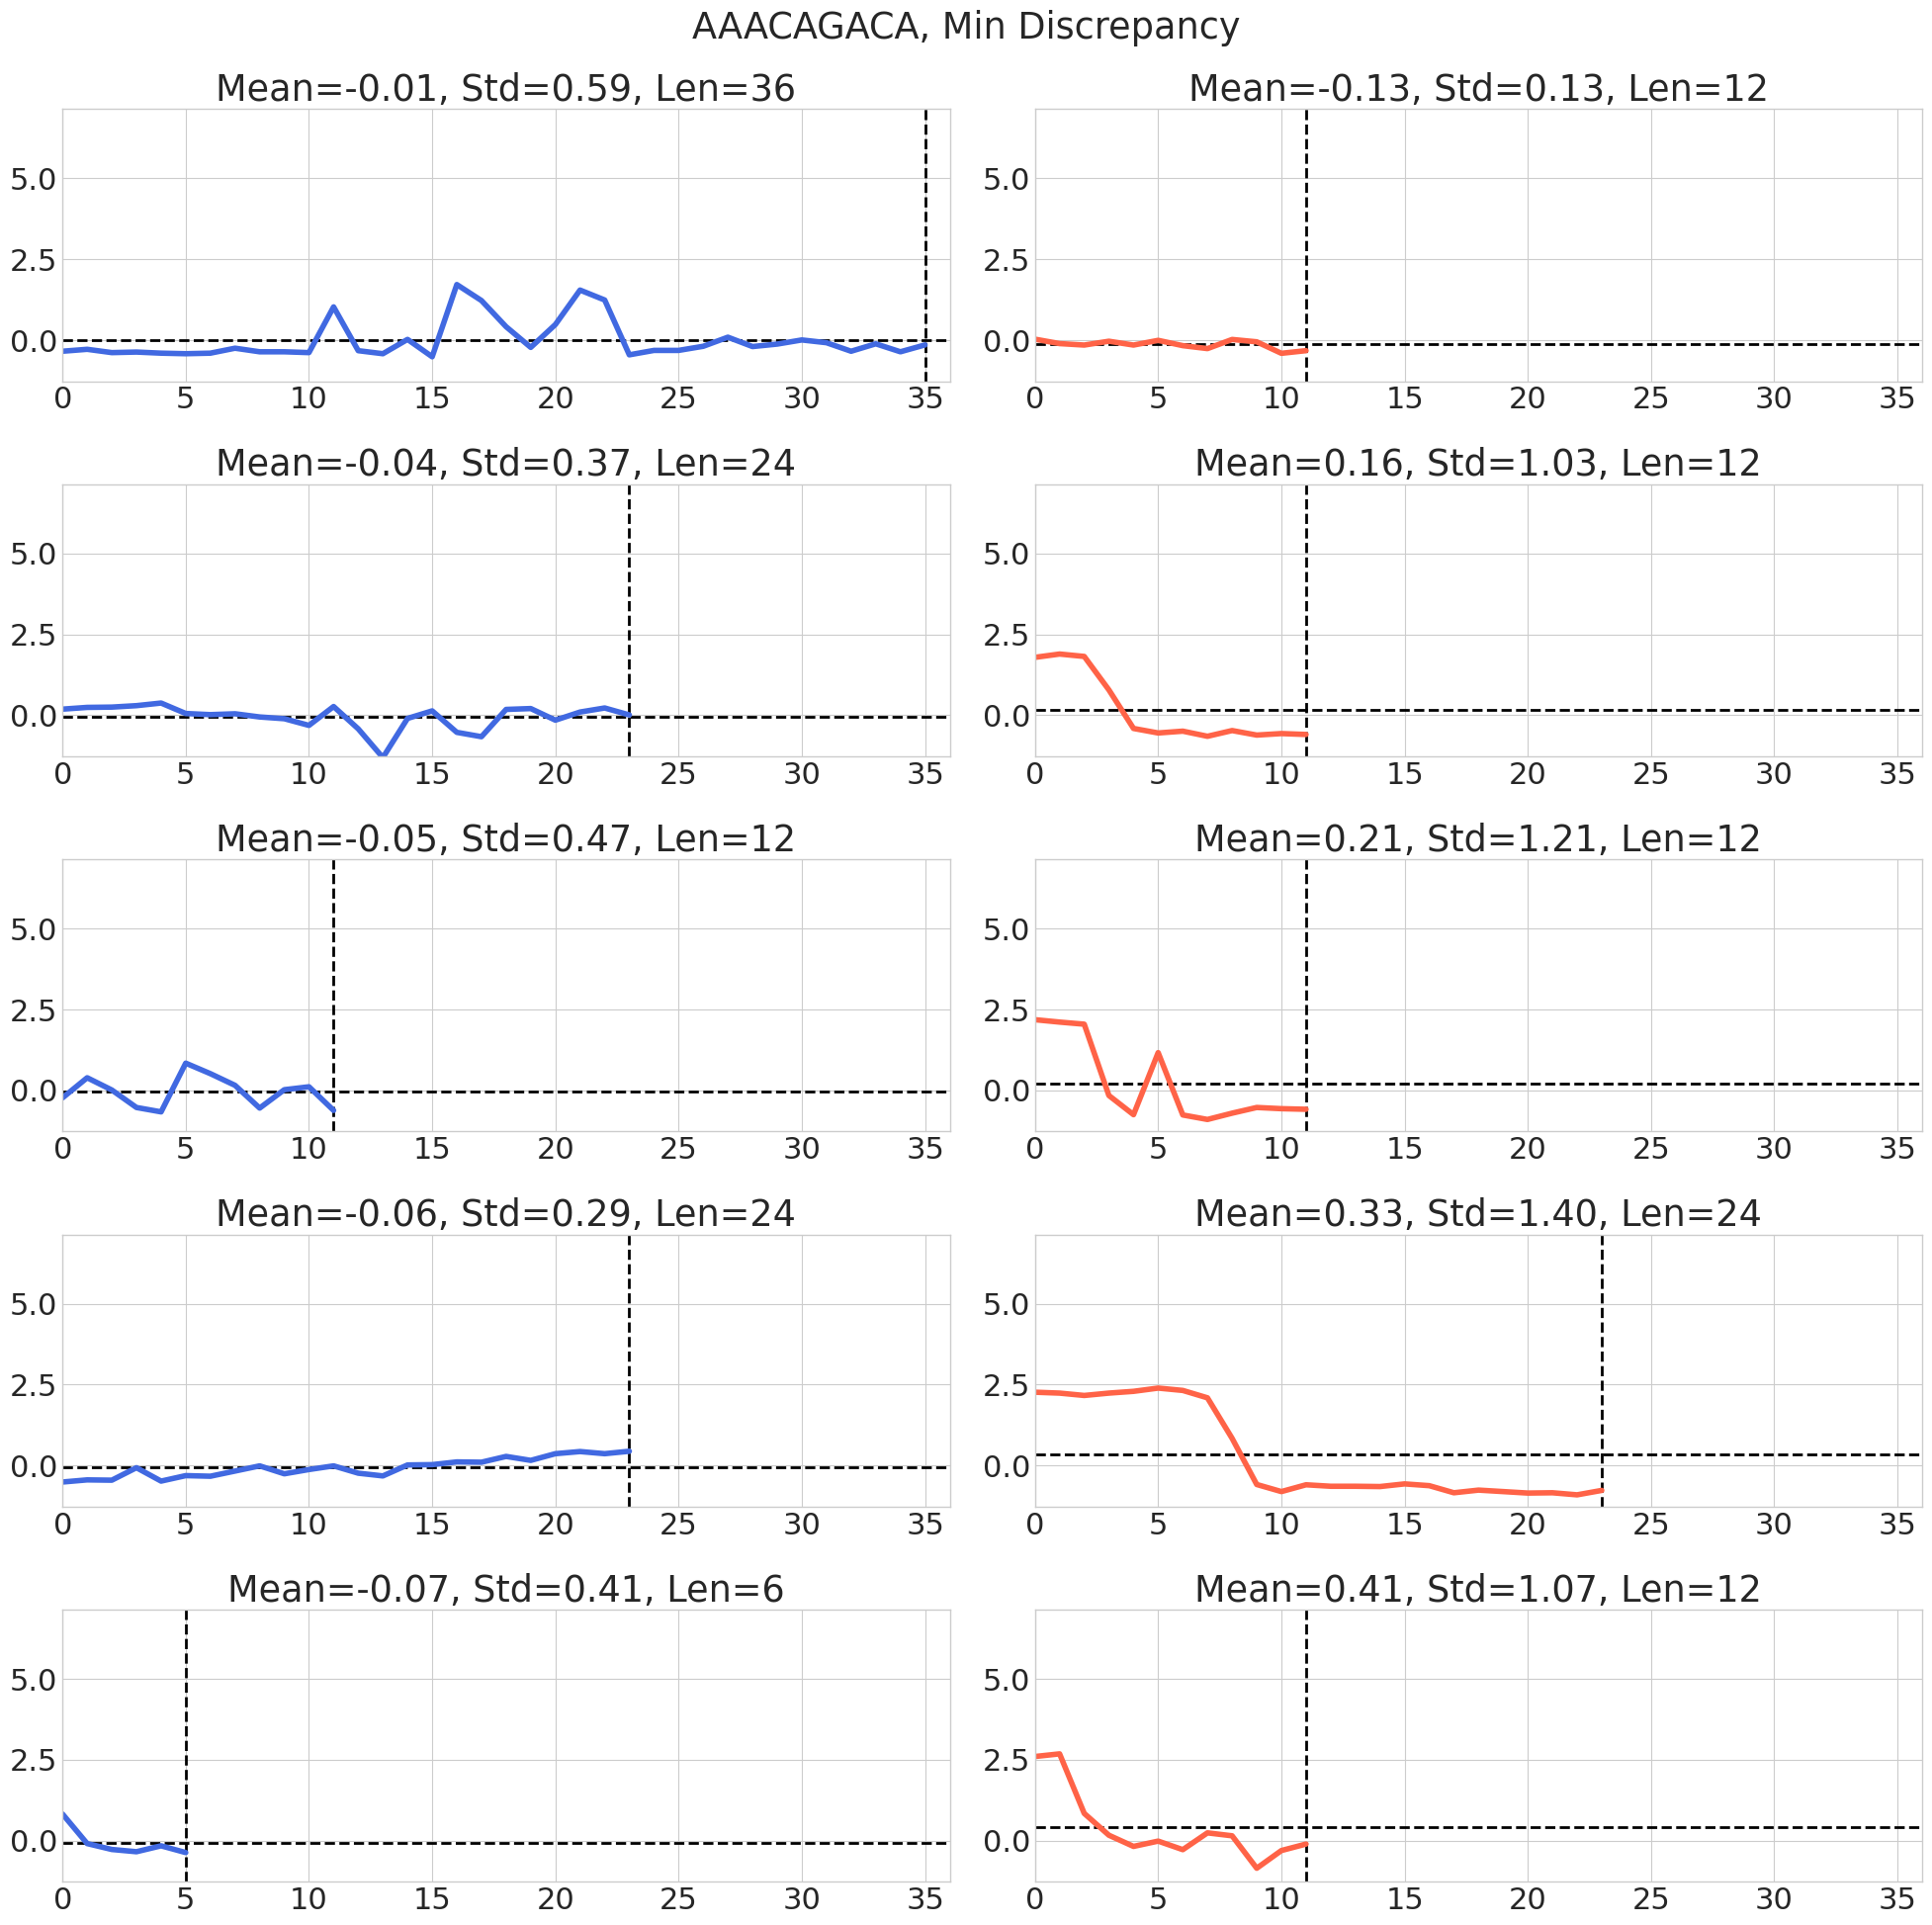

((0, 36), (-1.2690227, 7.1420503))

In [124]:
i = 1
xlim, ylim = plot_motif(motifs[i]+", Max Discrepancy", max_pair_dict[motifs[i]]["index_ON0093"], max_pair_dict[motifs[i]]["index_ON0099"])
plot_motif(motifs[i]+", Min Discrepancy", min_pair_dict[motifs[i]]["index_ON0093"], min_pair_dict[motifs[i]]["index_ON0099"],xlim, ylim)

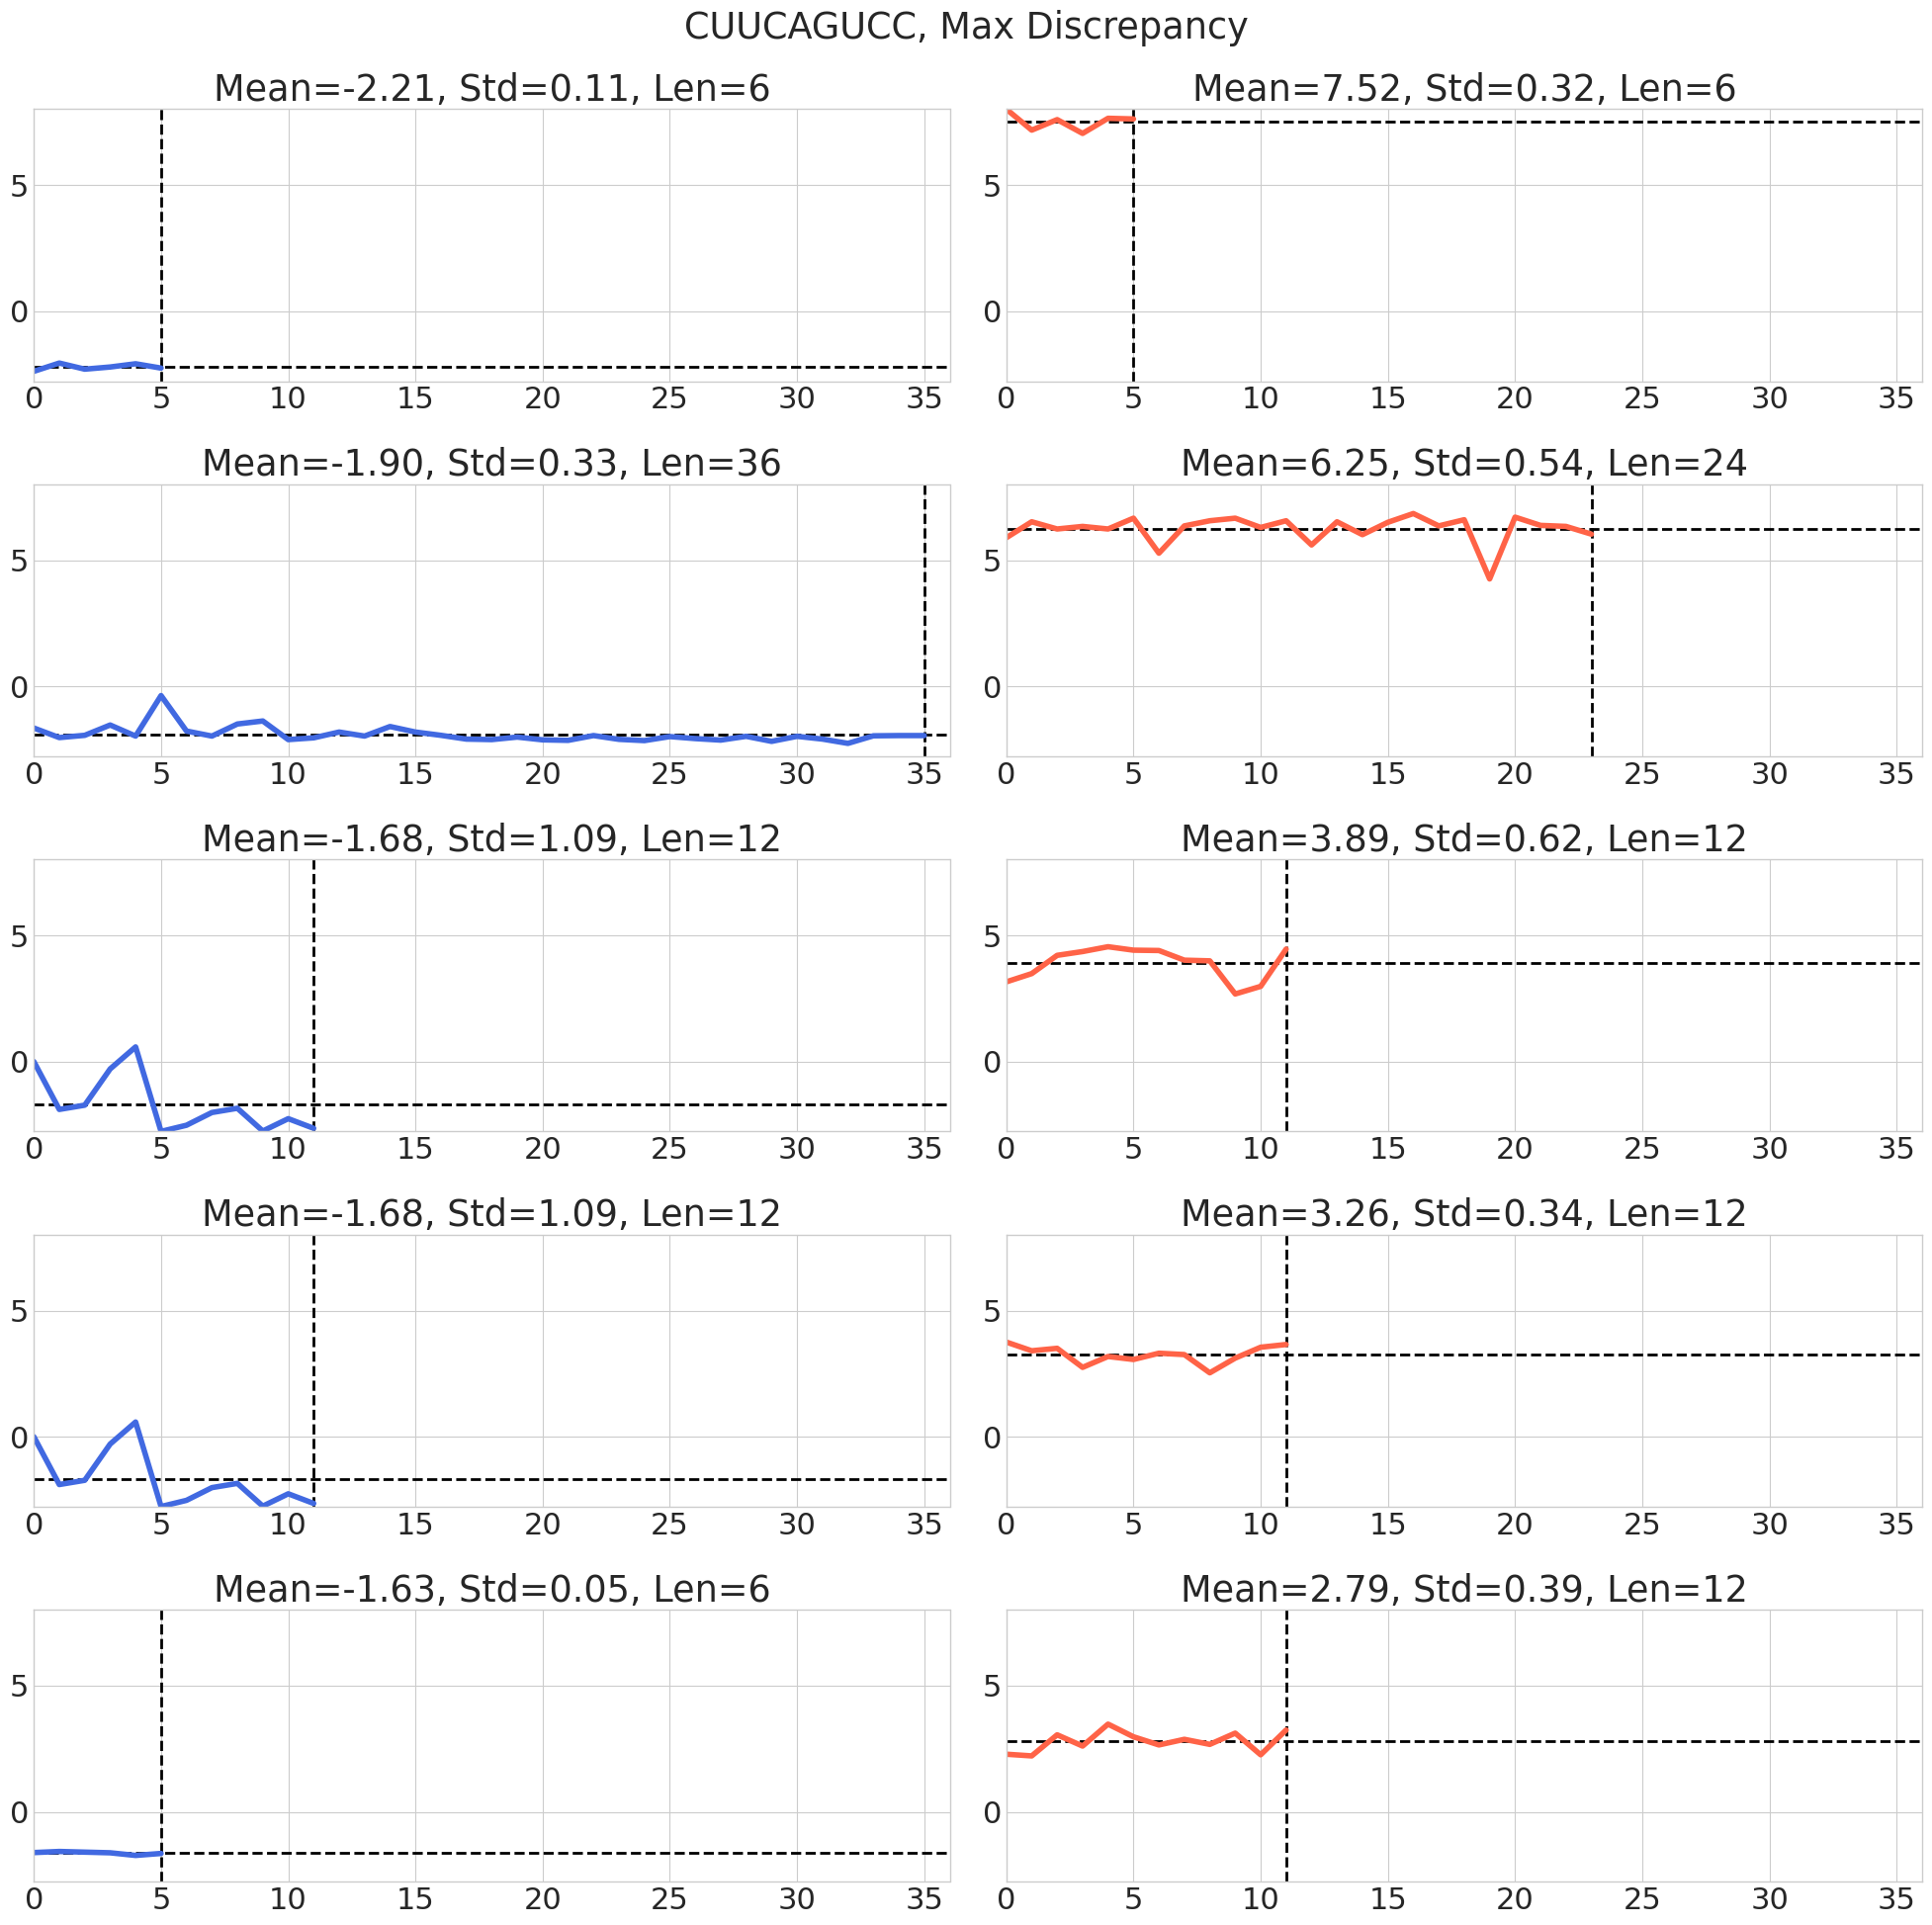

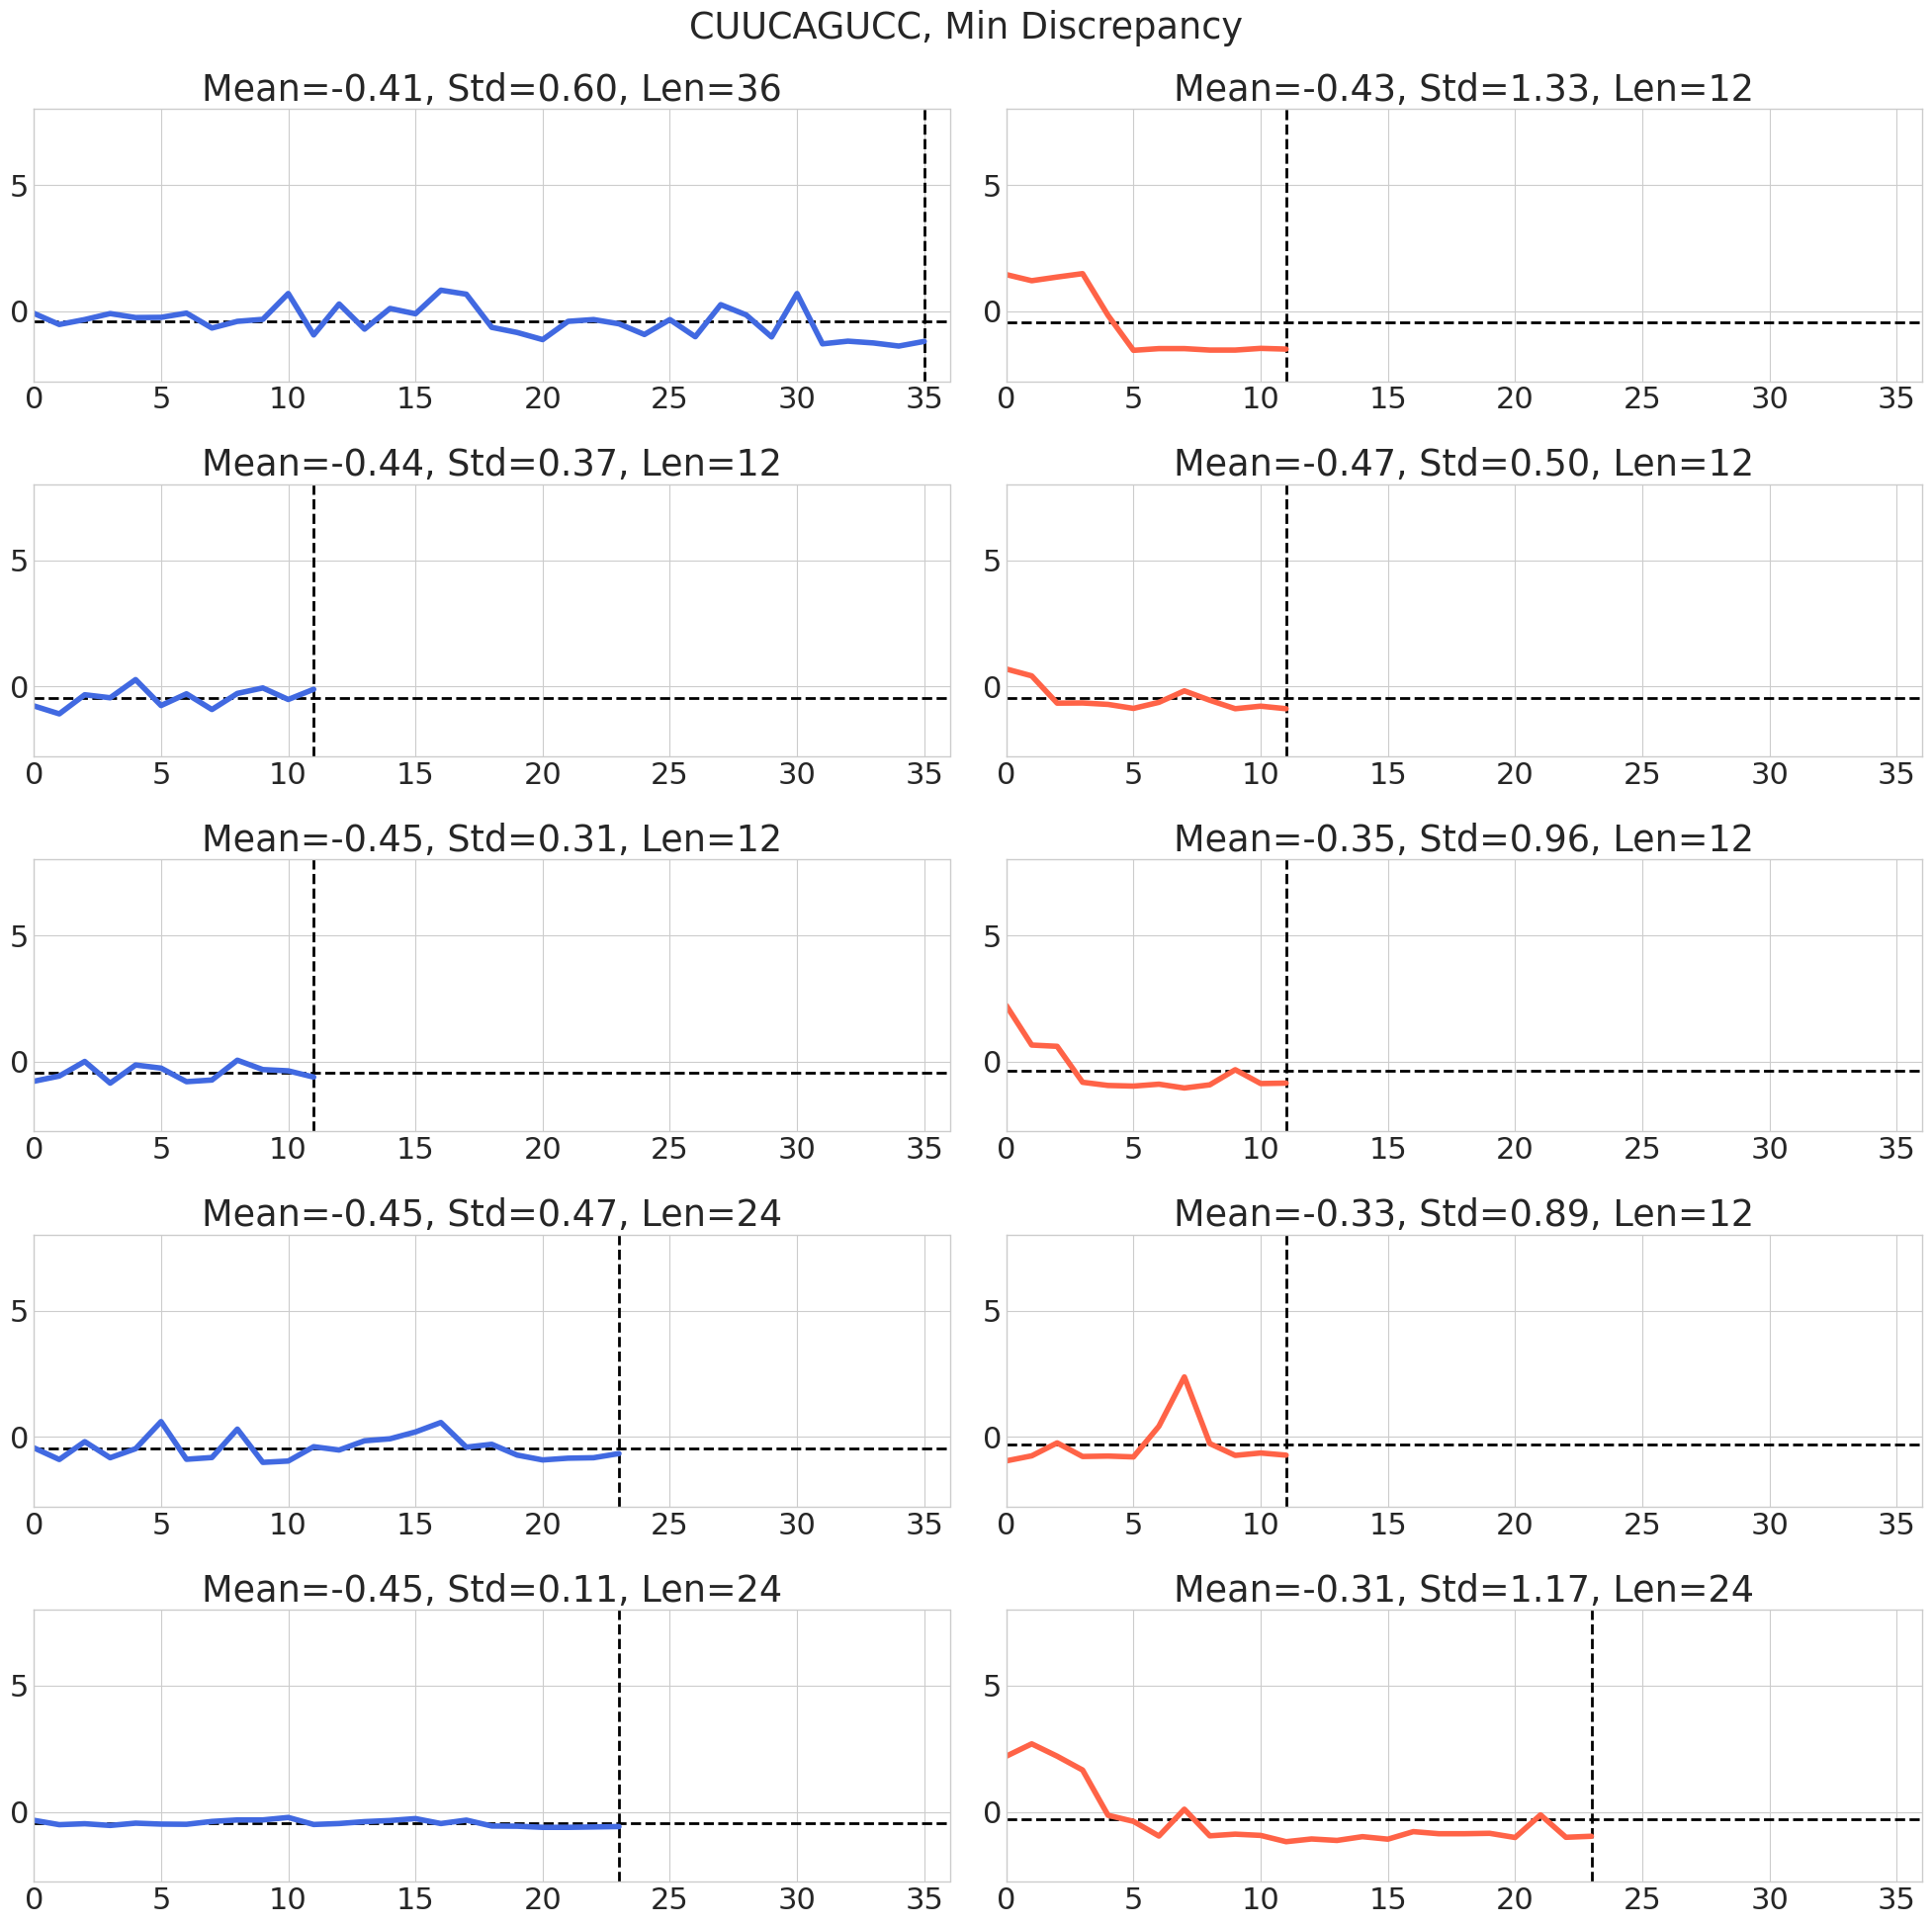

((0, 36), (-2.7691367, 8.019817))

In [125]:
i = 2
xlim, ylim = plot_motif(motifs[i]+", Max Discrepancy", max_pair_dict[motifs[i]]["index_ON0093"], max_pair_dict[motifs[i]]["index_ON0099"])
plot_motif(motifs[i]+", Min Discrepancy", min_pair_dict[motifs[i]]["index_ON0093"], min_pair_dict[motifs[i]]["index_ON0099"],xlim, ylim)

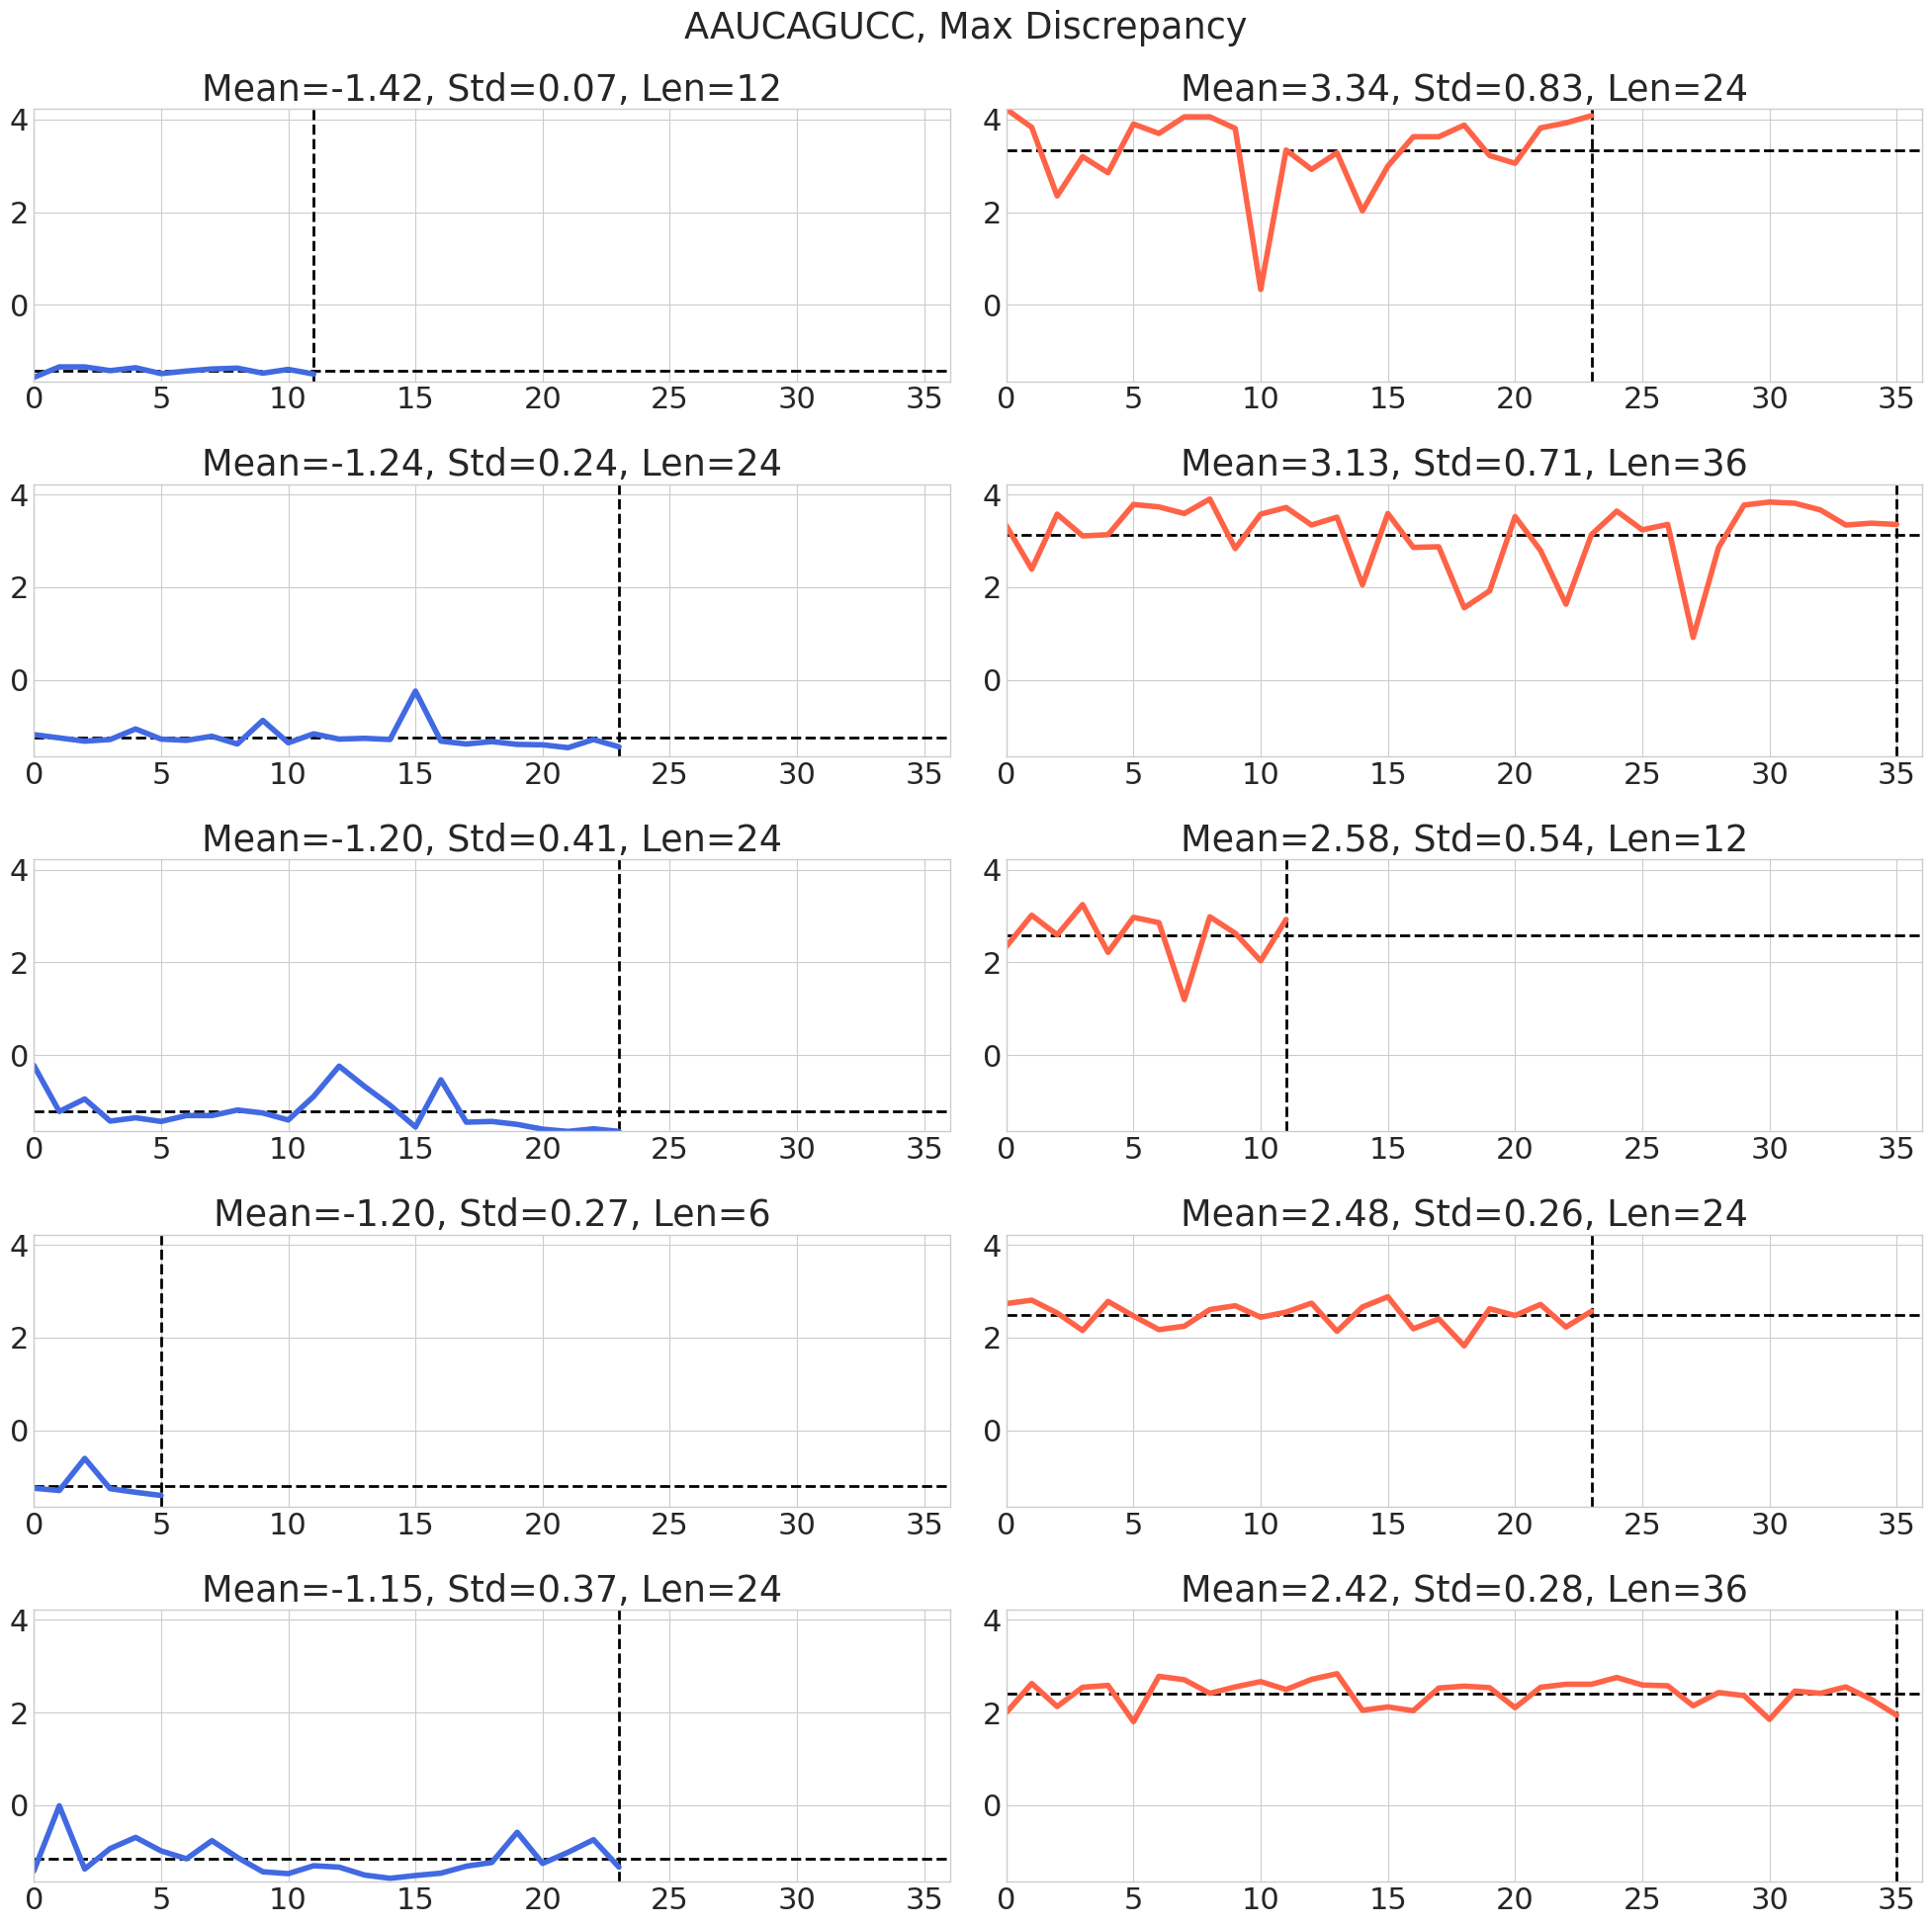

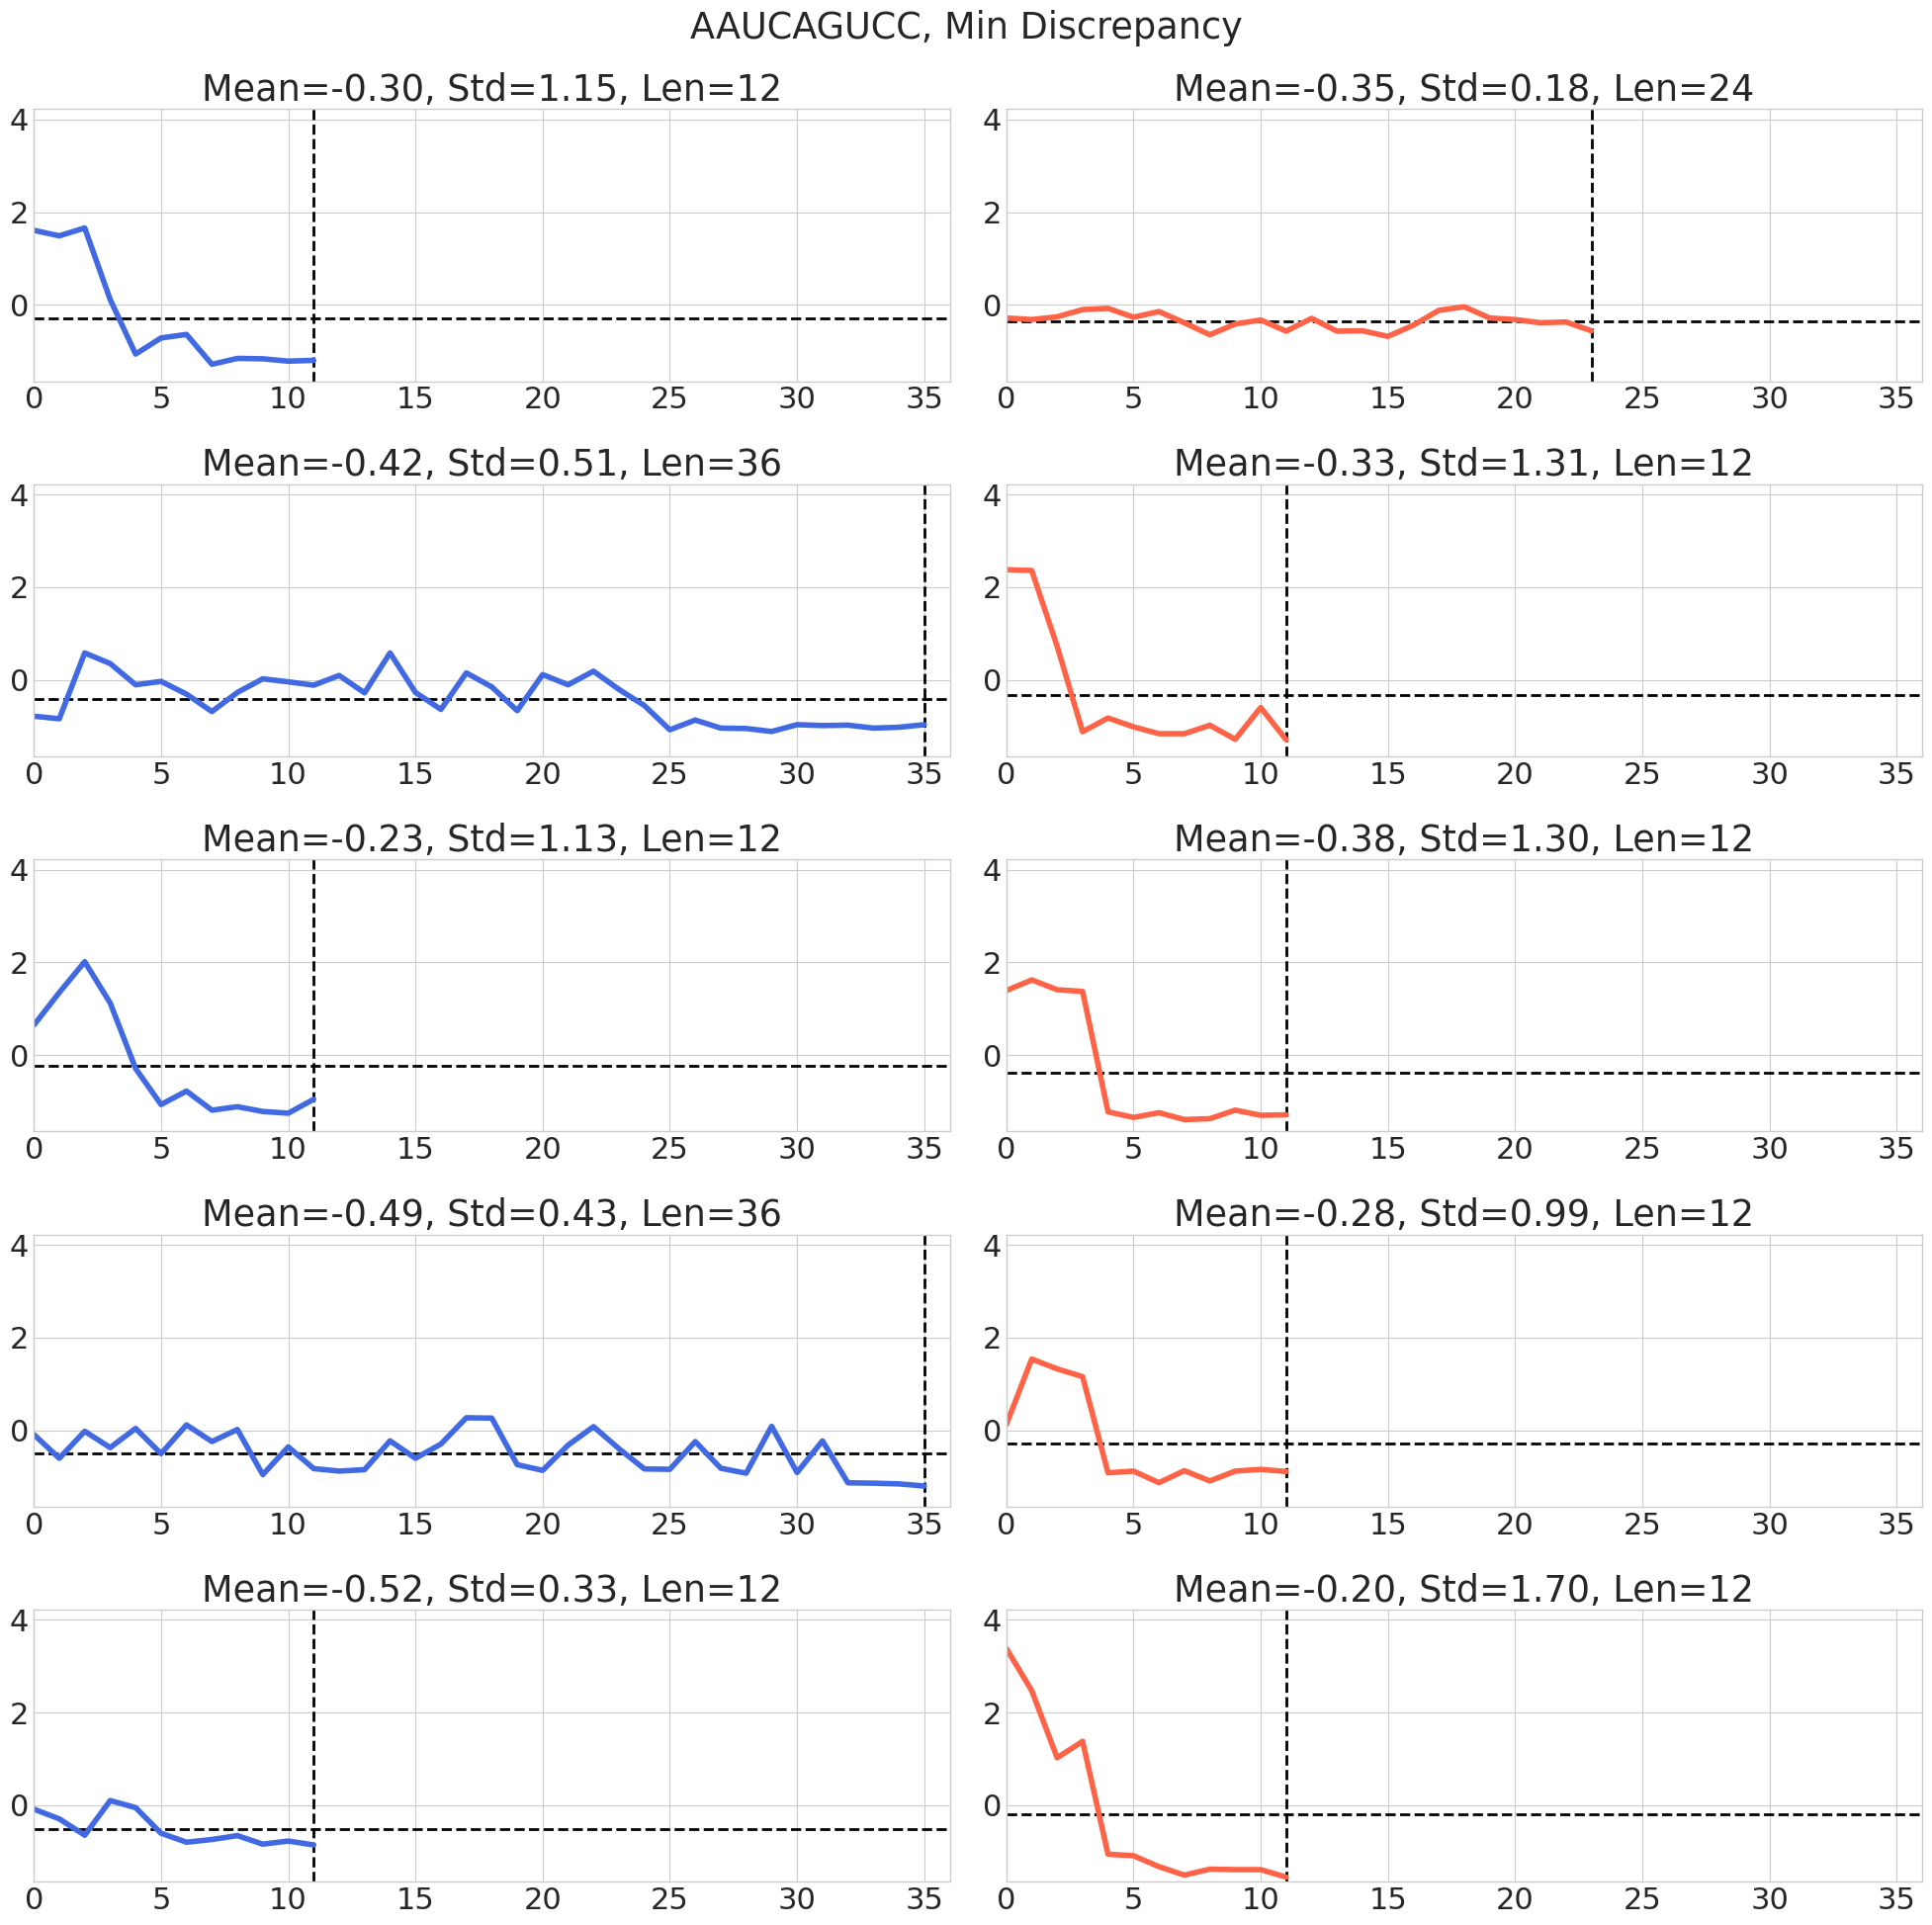

((0, 36), (-1.6465346, 4.2234426))

In [126]:
i = 3
xlim, ylim = plot_motif(motifs[i]+", Max Discrepancy", max_pair_dict[motifs[i]]["index_ON0093"], max_pair_dict[motifs[i]]["index_ON0099"])
plot_motif(motifs[i]+", Min Discrepancy", min_pair_dict[motifs[i]]["index_ON0093"], min_pair_dict[motifs[i]]["index_ON0099"],xlim, ylim)

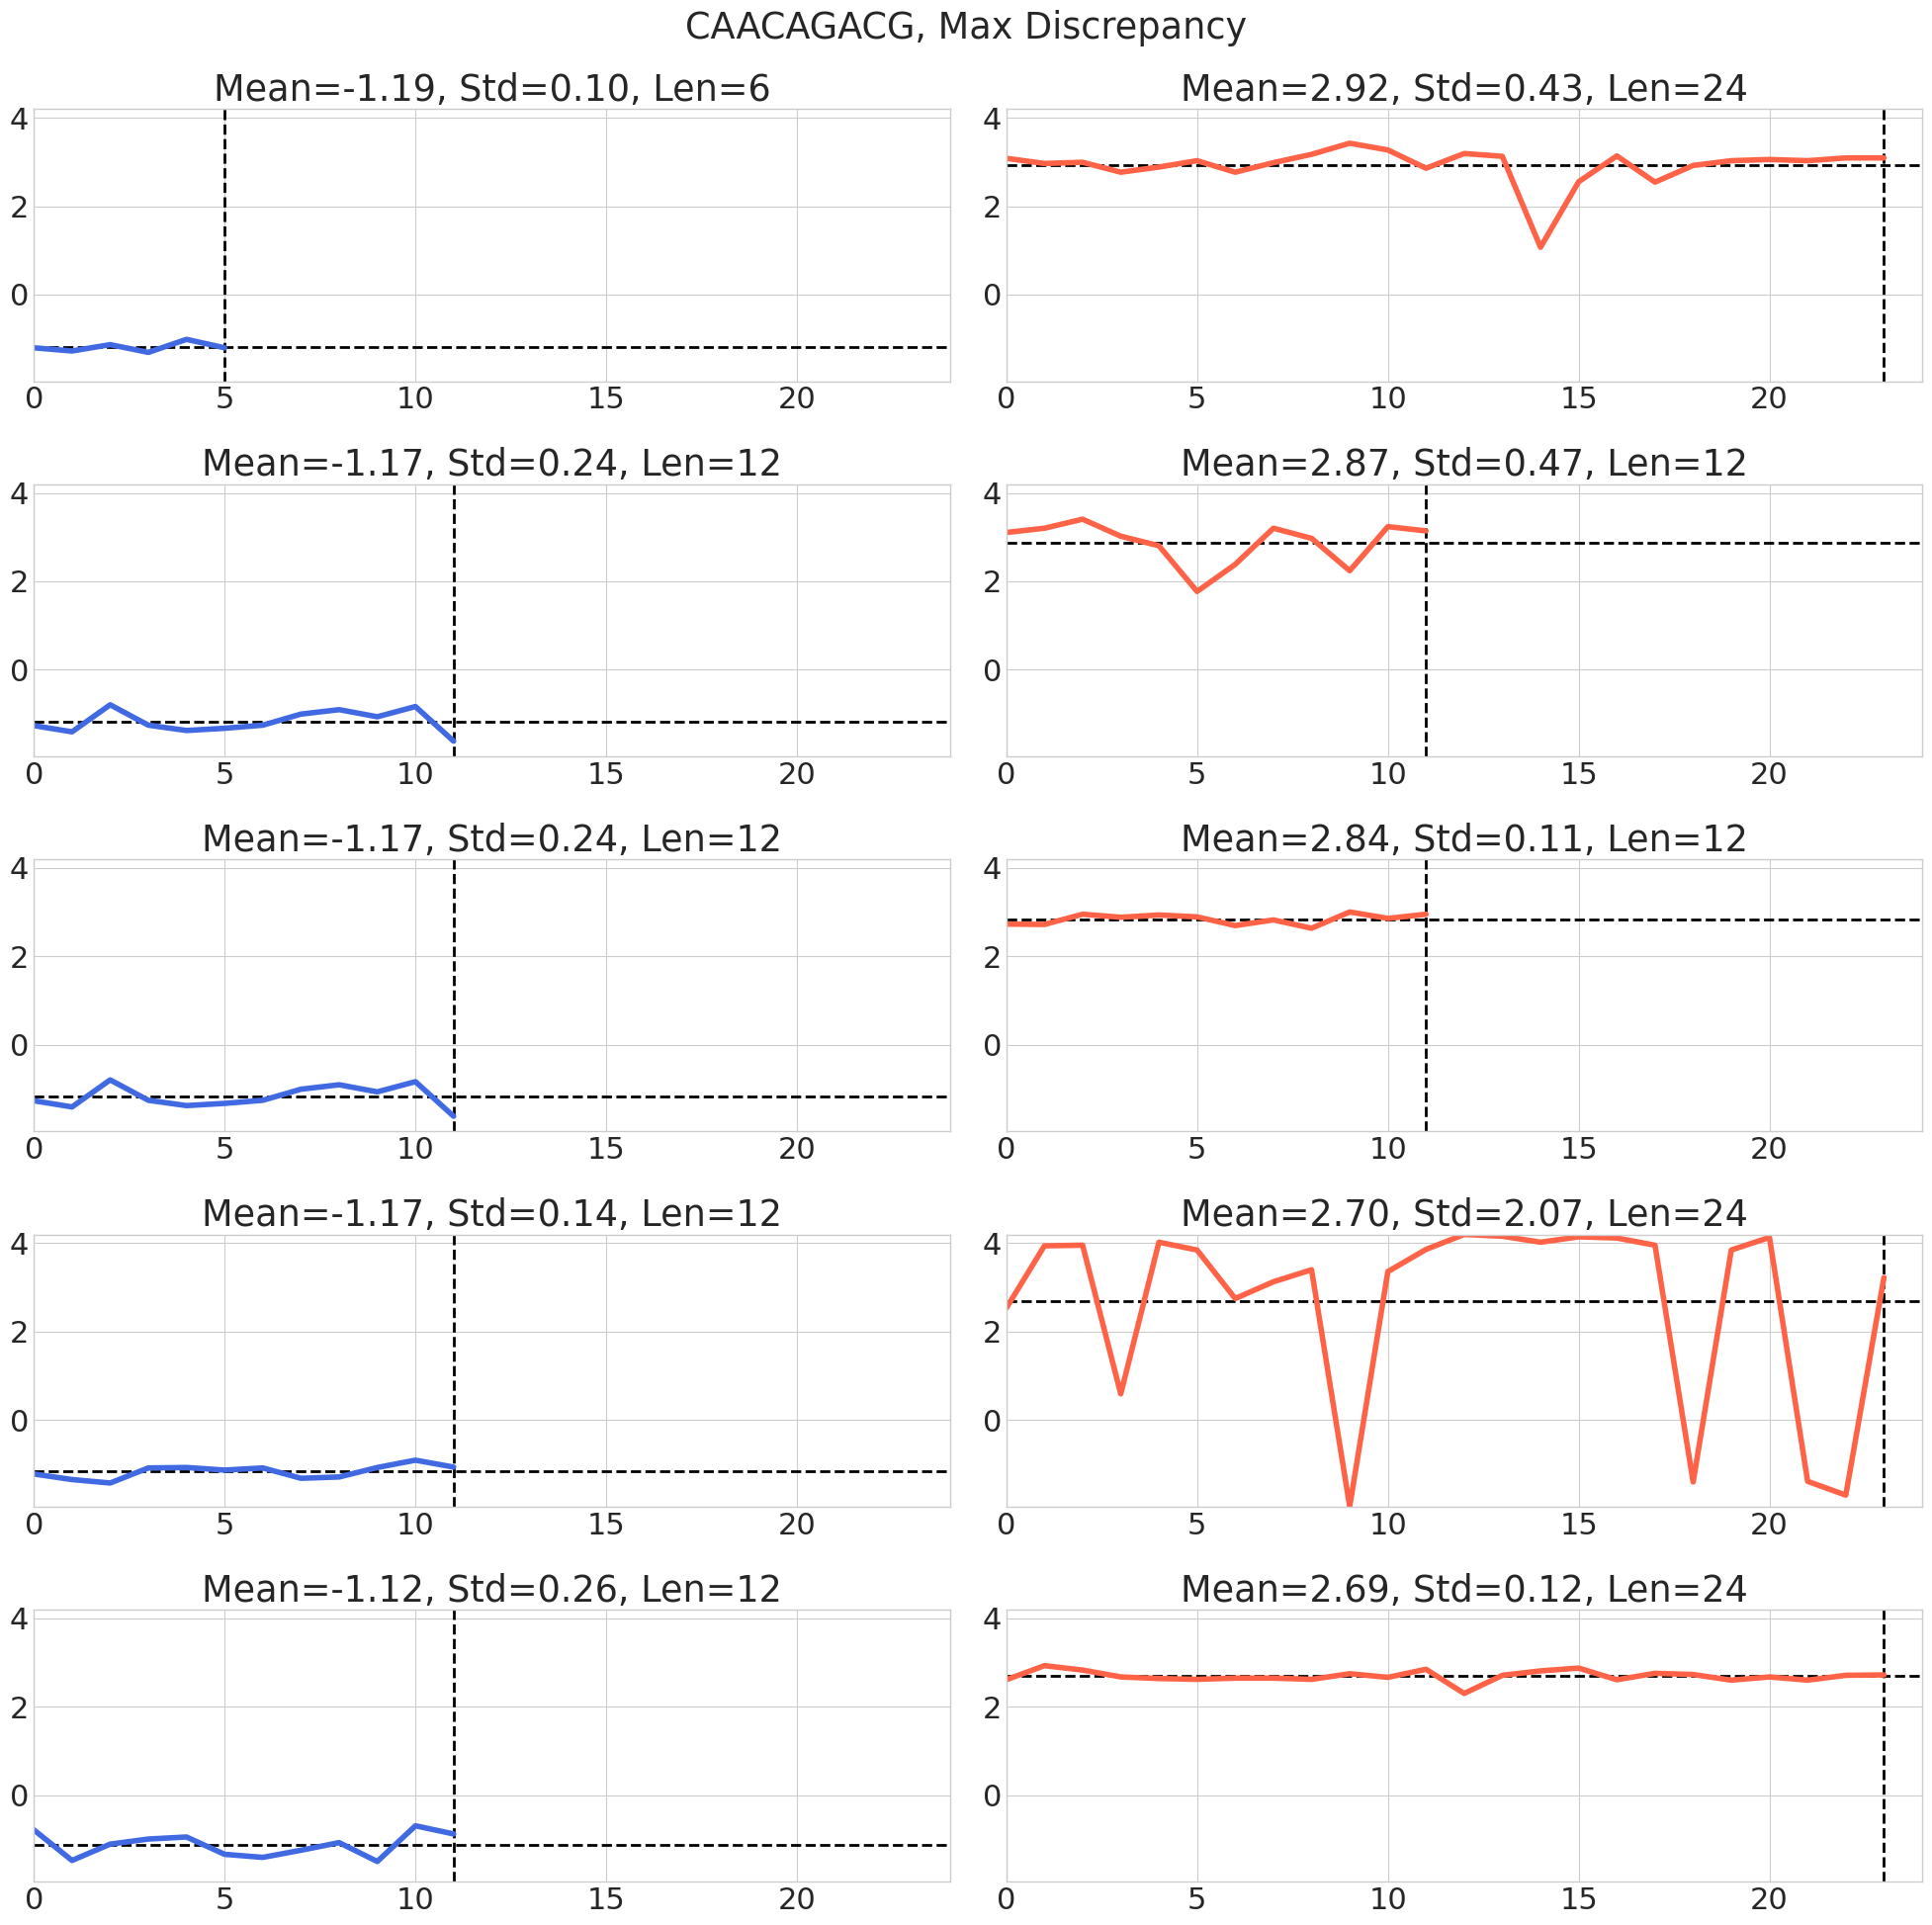

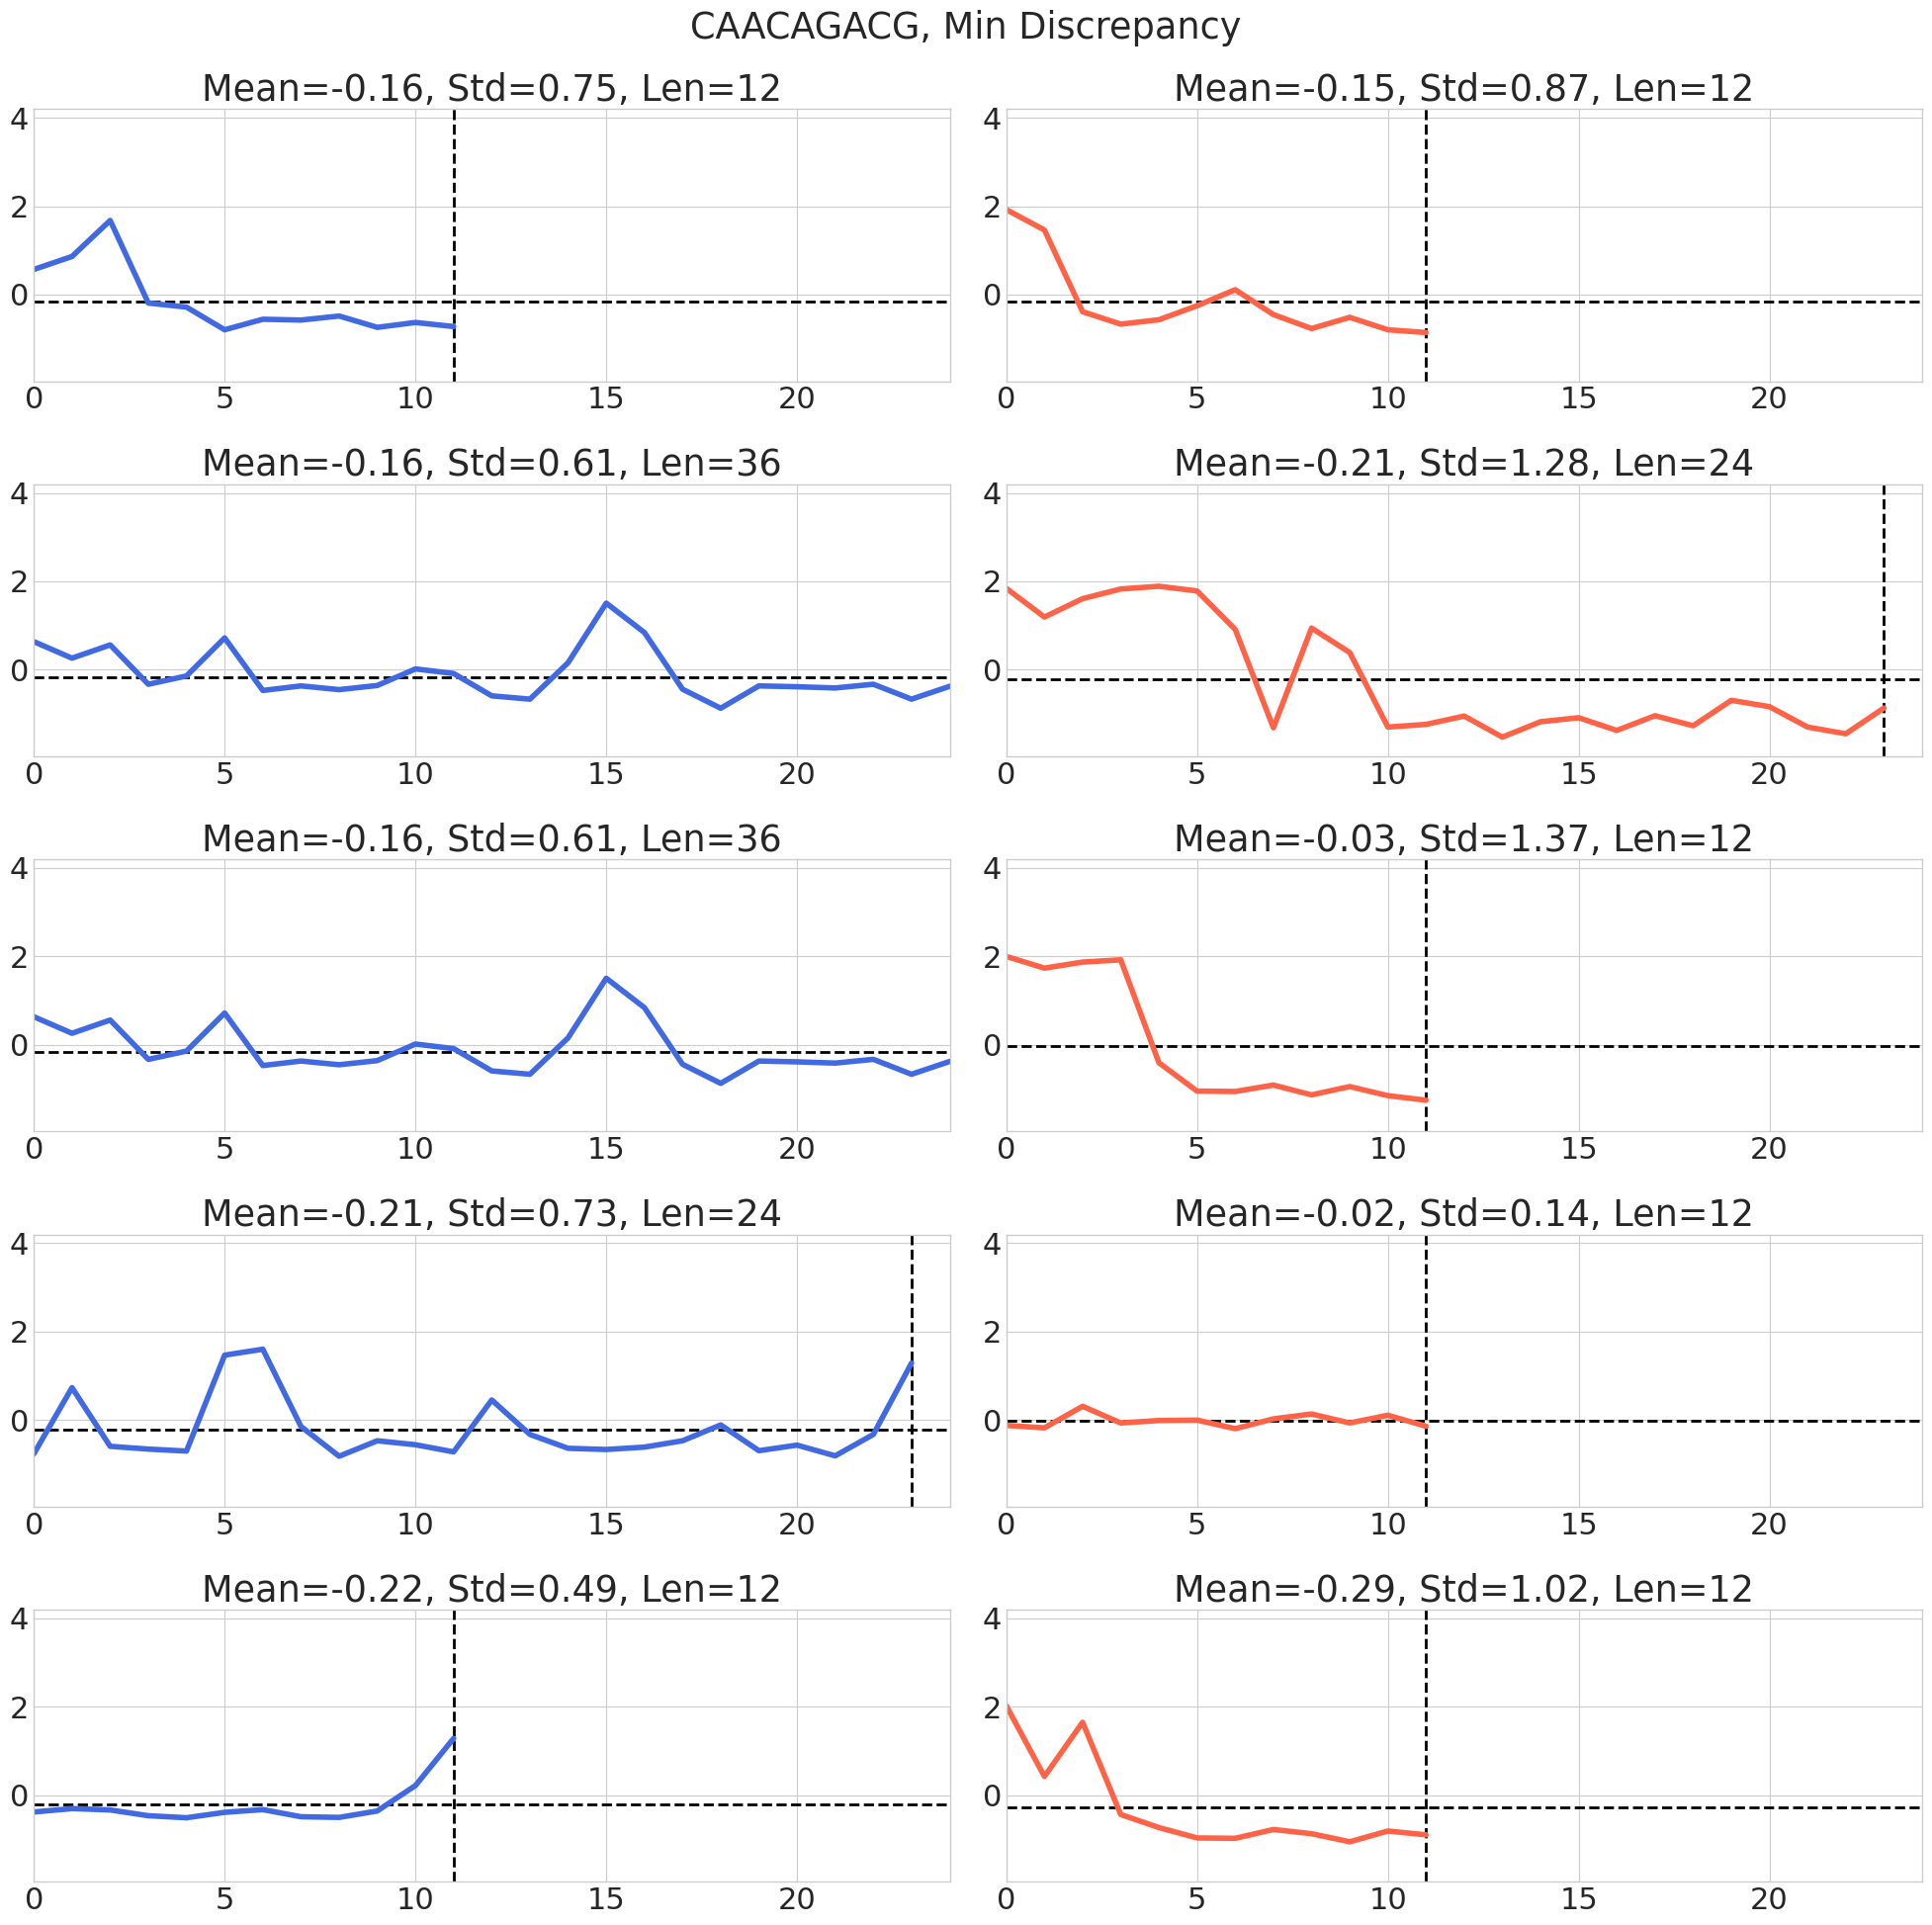

((0, 24), (-1.9585085, 4.197424))

In [127]:
i = 4
xlim, ylim = plot_motif(motifs[i]+", Max Discrepancy", max_pair_dict[motifs[i]]["index_ON0093"], max_pair_dict[motifs[i]]["index_ON0099"])
plot_motif(motifs[i]+", Min Discrepancy", min_pair_dict[motifs[i]]["index_ON0093"], min_pair_dict[motifs[i]]["index_ON0099"],xlim, ylim)

In [129]:
data = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/block_070/token_normalise_feature_analysis_v4/last-0-last.npz"
with np.load(data, allow_pickle = True) as f:
    data = {key: f[key] for key in f.keys()}
print(data)

{'dwell': array([[-0.33333334,  0.08728648,  0.08728648, ...,  0.08728648,
         0.50790626,  0.33333334],
       [ 0.22269577, -0.33333334, -0.33333334, ...,  0.08728648,
         0.08728648, -0.33333334],
       [ 0.33333334,  0.08728648, -0.33333334, ..., -0.08728648,
        -0.08728648,  0.08728648],
       ...,
       [-0.33333334,  0.08728648,  0.08728648, ..., -0.33333334,
         0.08728648,  0.42687592],
       [-0.33333334,  0.08728648,  0.08728648, ..., -0.33333334,
        -0.33333334, -0.33333334],
       [ 0.08728648,  0.08728648,  0.33333334, ...,  0.50790626,
         0.08728648, -0.33333334]], dtype=float32), 'signal_mean': array([[ 0.46948165, -0.17351294, -0.9500407 , ..., -0.521686  ,
         0.28475562,  0.2696445 ],
       [ 0.444502  , -0.6712555 , -0.6027928 , ..., -0.27158117,
        -1.0240545 , -1.1415514 ],
       [ 1.2558283 ,  1.6348689 ,  0.6896277 , ..., -0.0046874 ,
         0.34841993,  0.6350448 ],
       ...,
       [-0.07067427, -0.26207826, 

In [132]:
print(data.keys())


dict_keys(['dwell', 'signal_mean', 'signal_std', 'bq', 'label', 'motif'])


In [136]:
motifs = list(max_pair_dict_rev.keys())

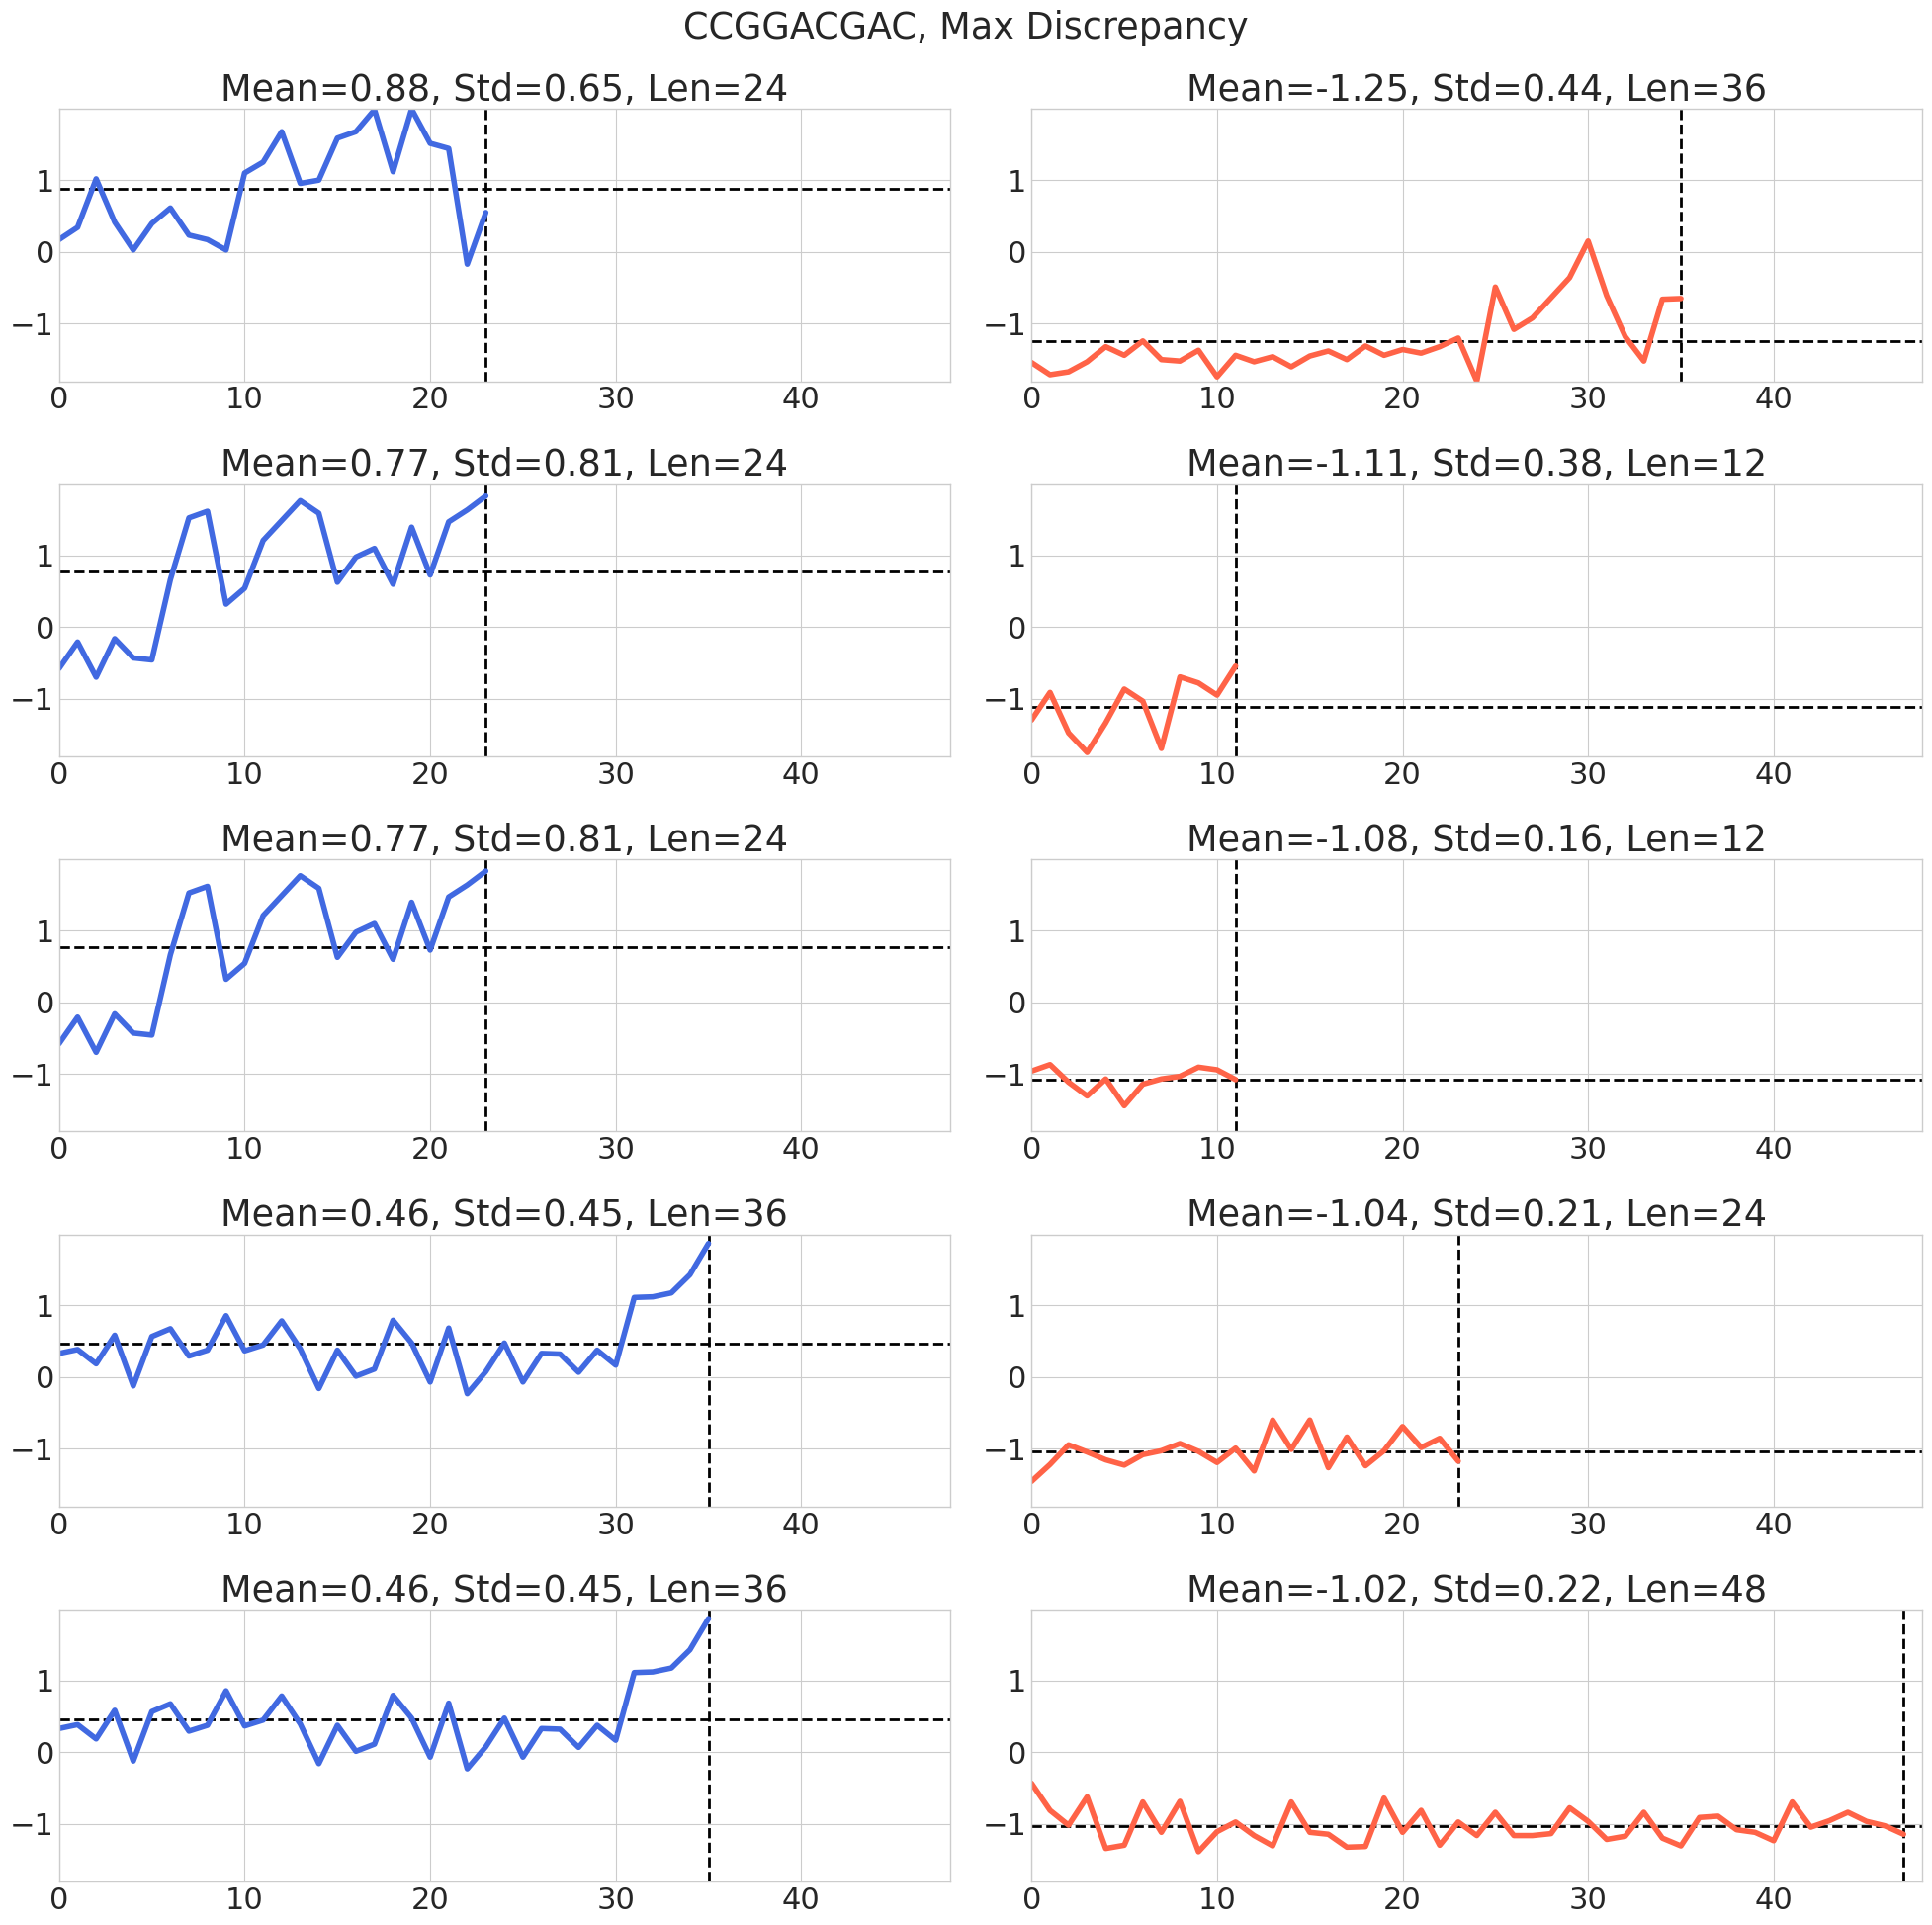

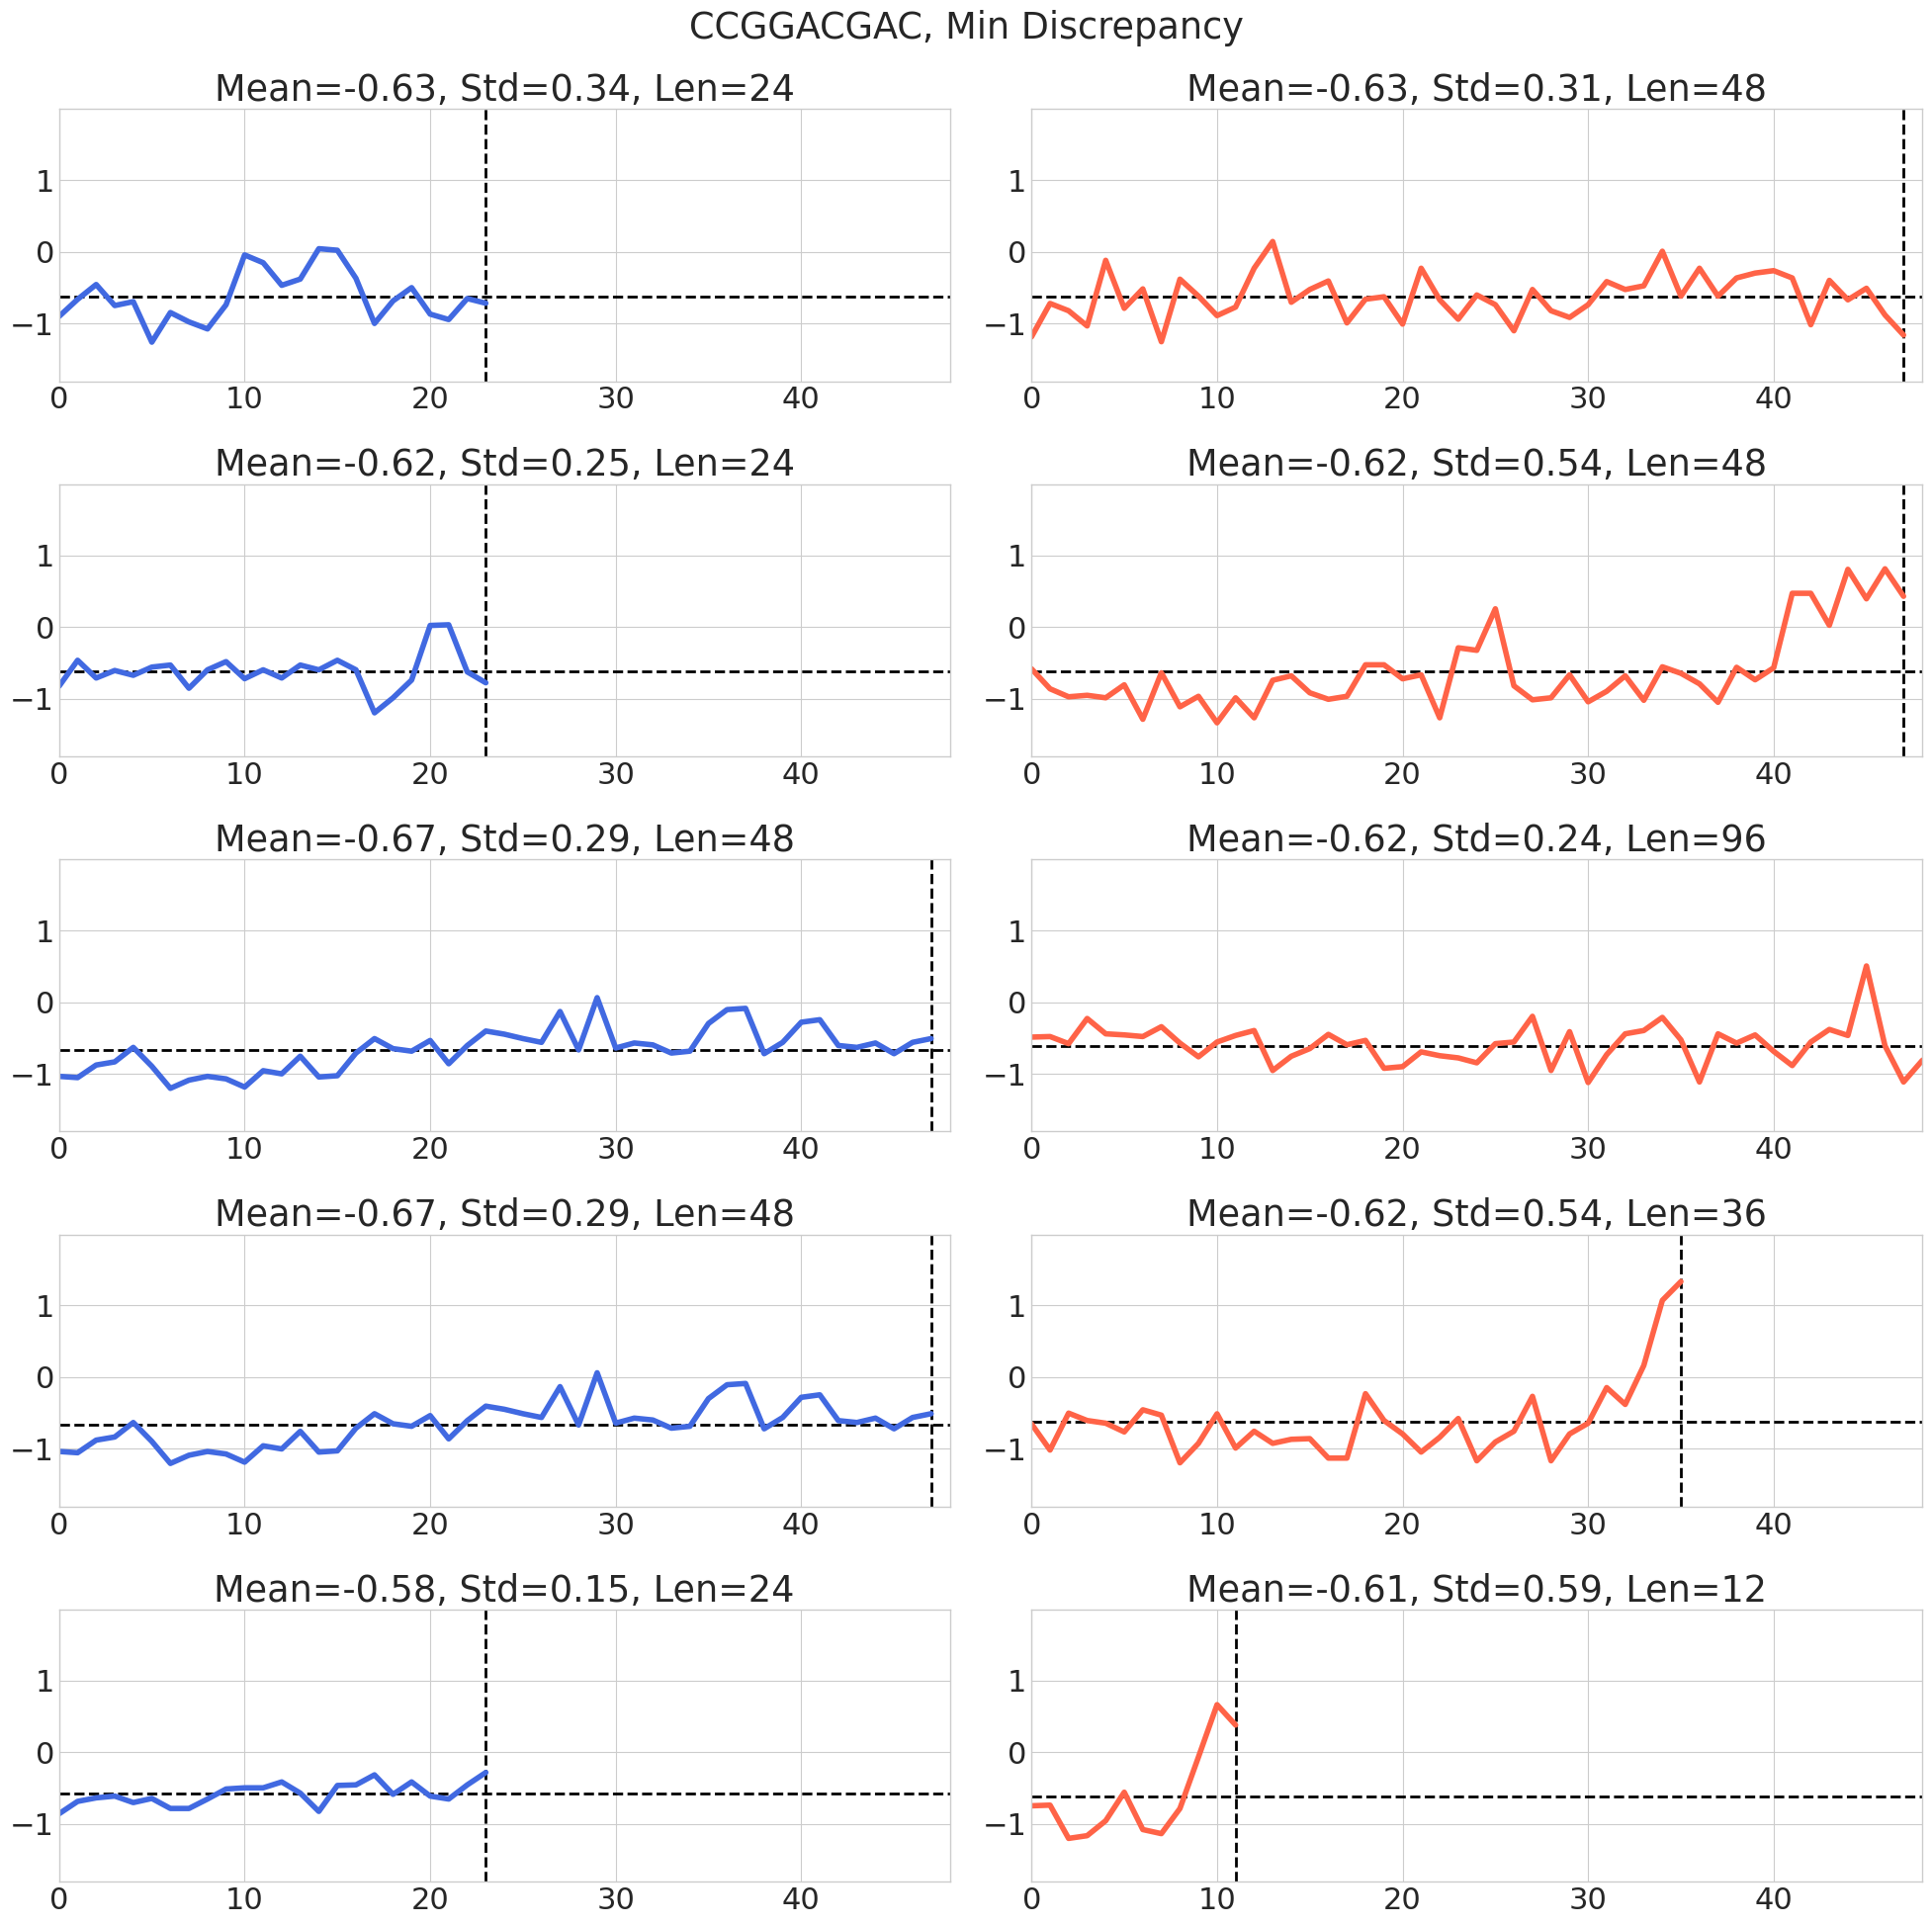

((0, 48), (-1.8040317, 1.9920664))

In [139]:
i = 0
xlim, ylim = plot_motif(motifs[i]+", Max Discrepancy", max_pair_dict_rev[motifs[i]]["index_ON0093"], max_pair_dict_rev[motifs[i]]["index_ON0099"])
plot_motif(motifs[i]+", Min Discrepancy", min_pair_dict_rev[motifs[i]]["index_ON0093"], min_pair_dict_rev[motifs[i]]["index_ON0099"],xlim, ylim)

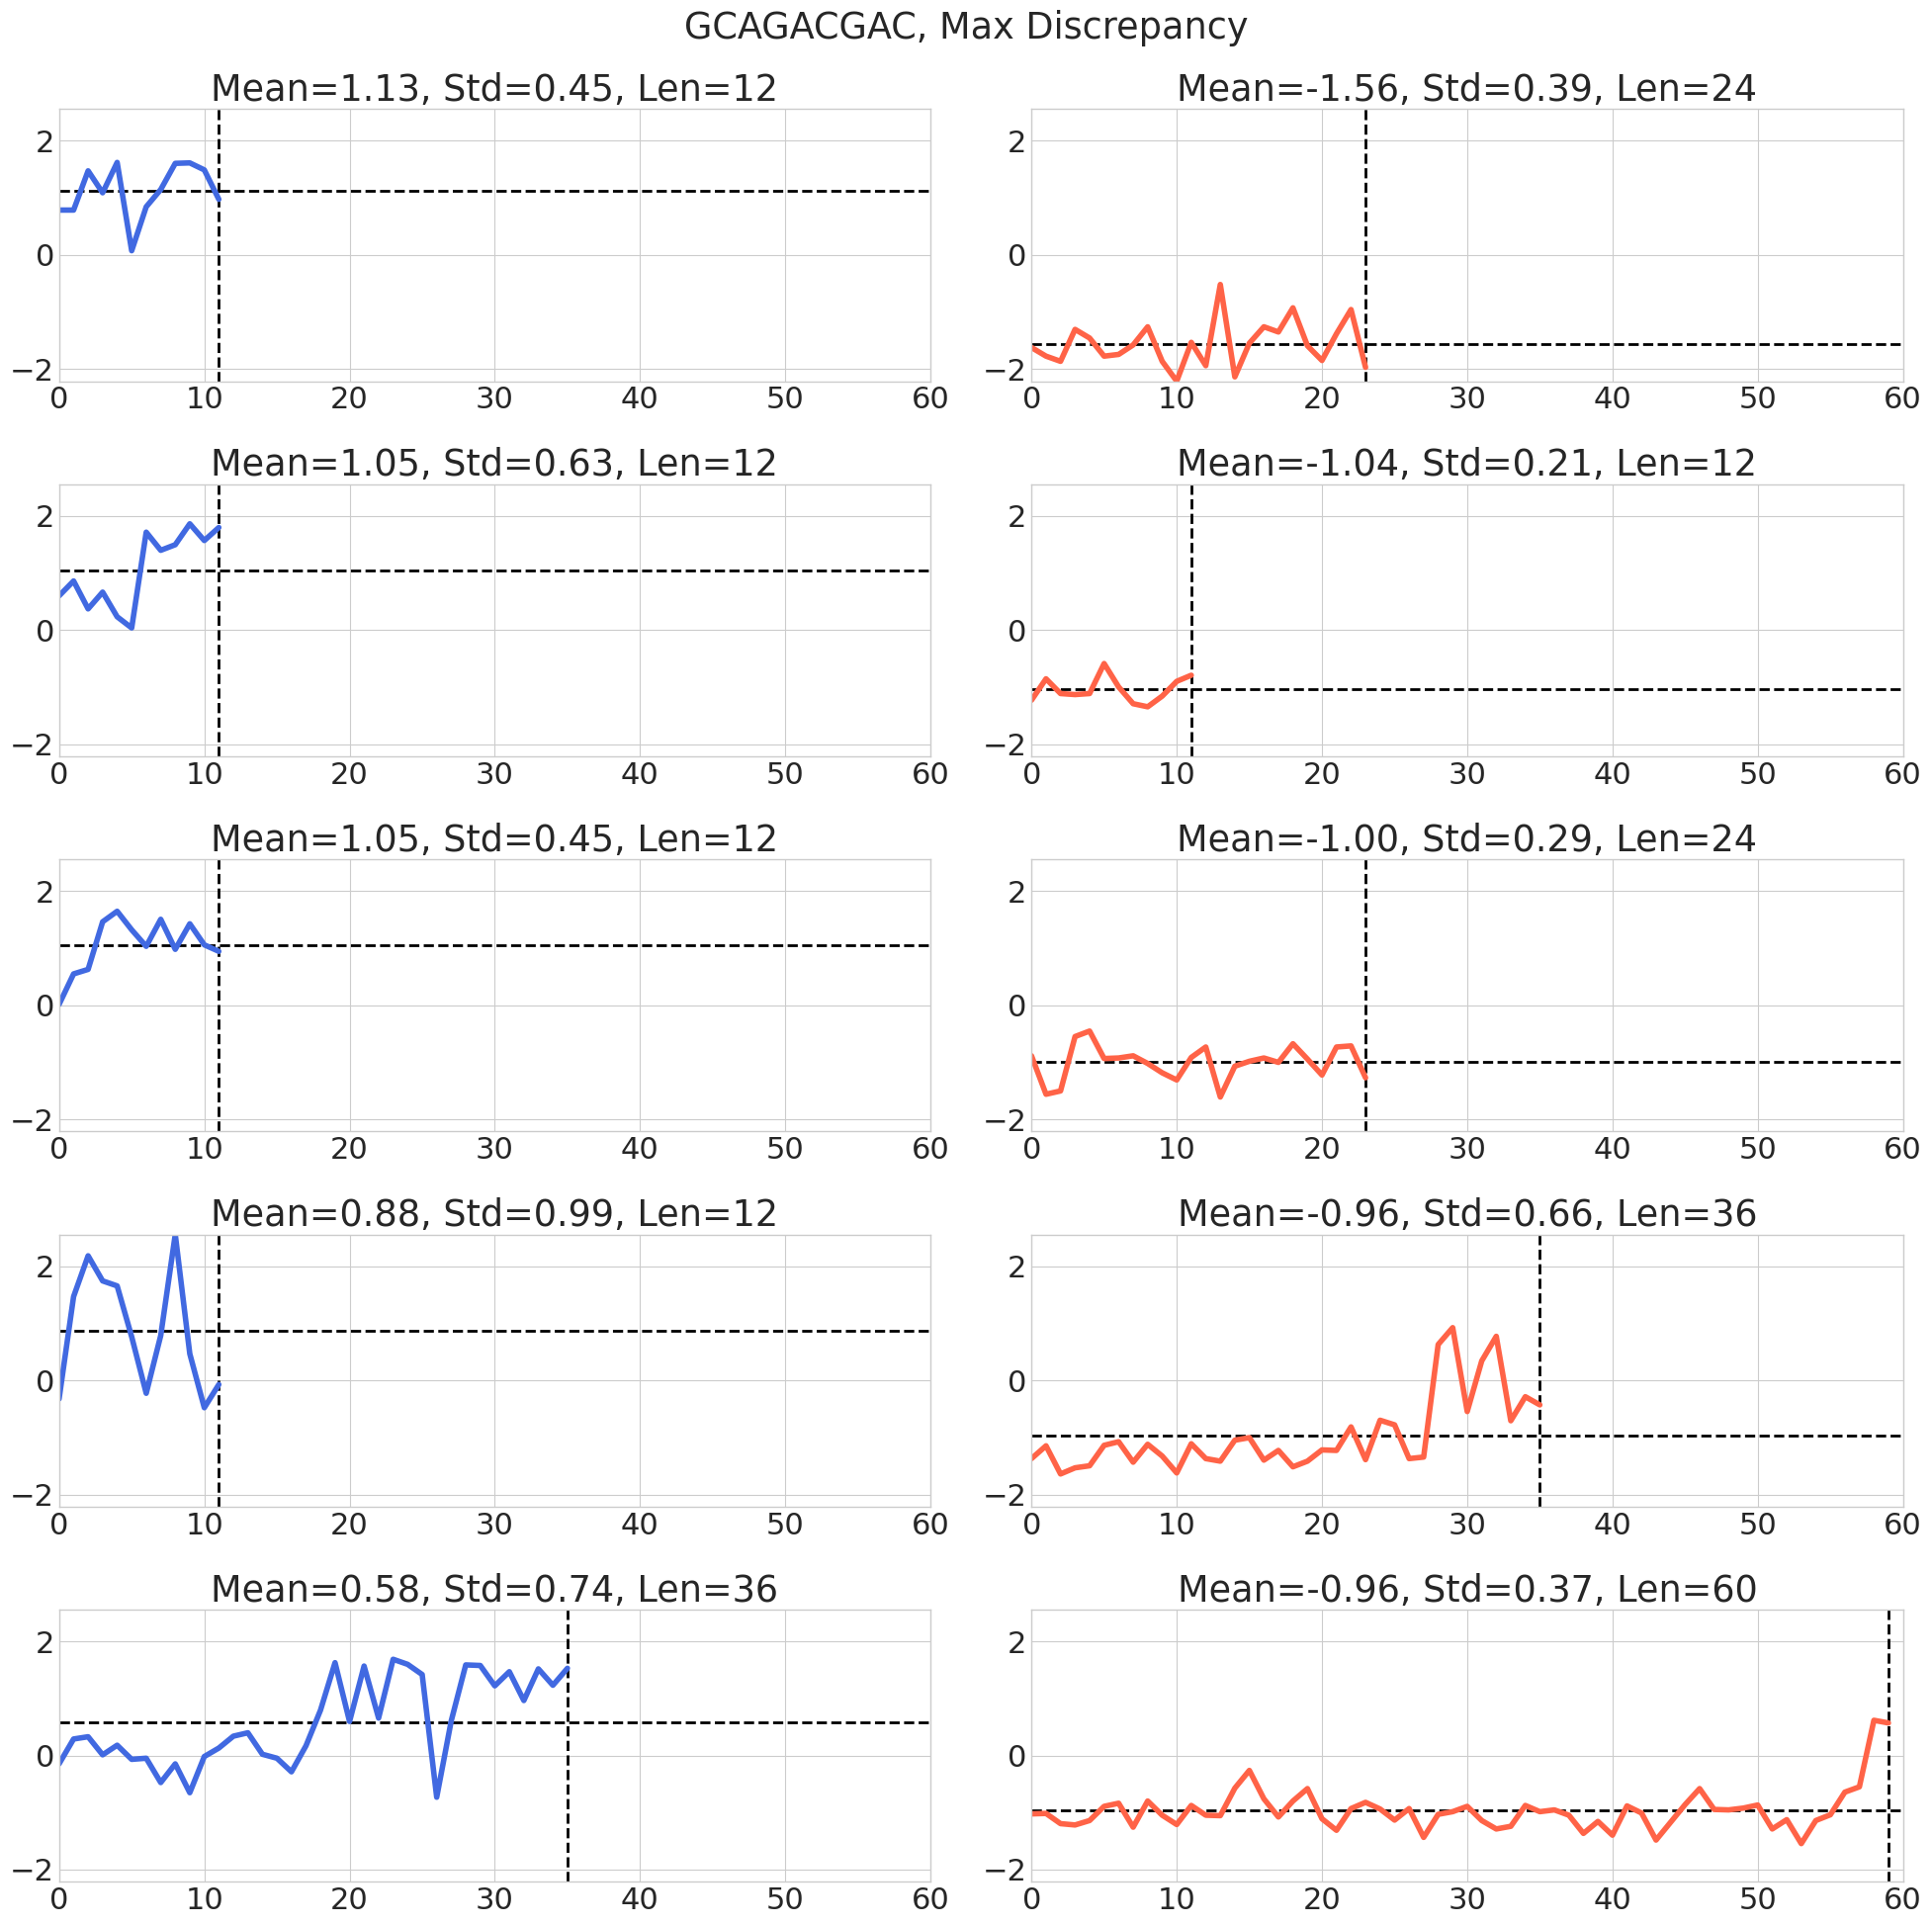

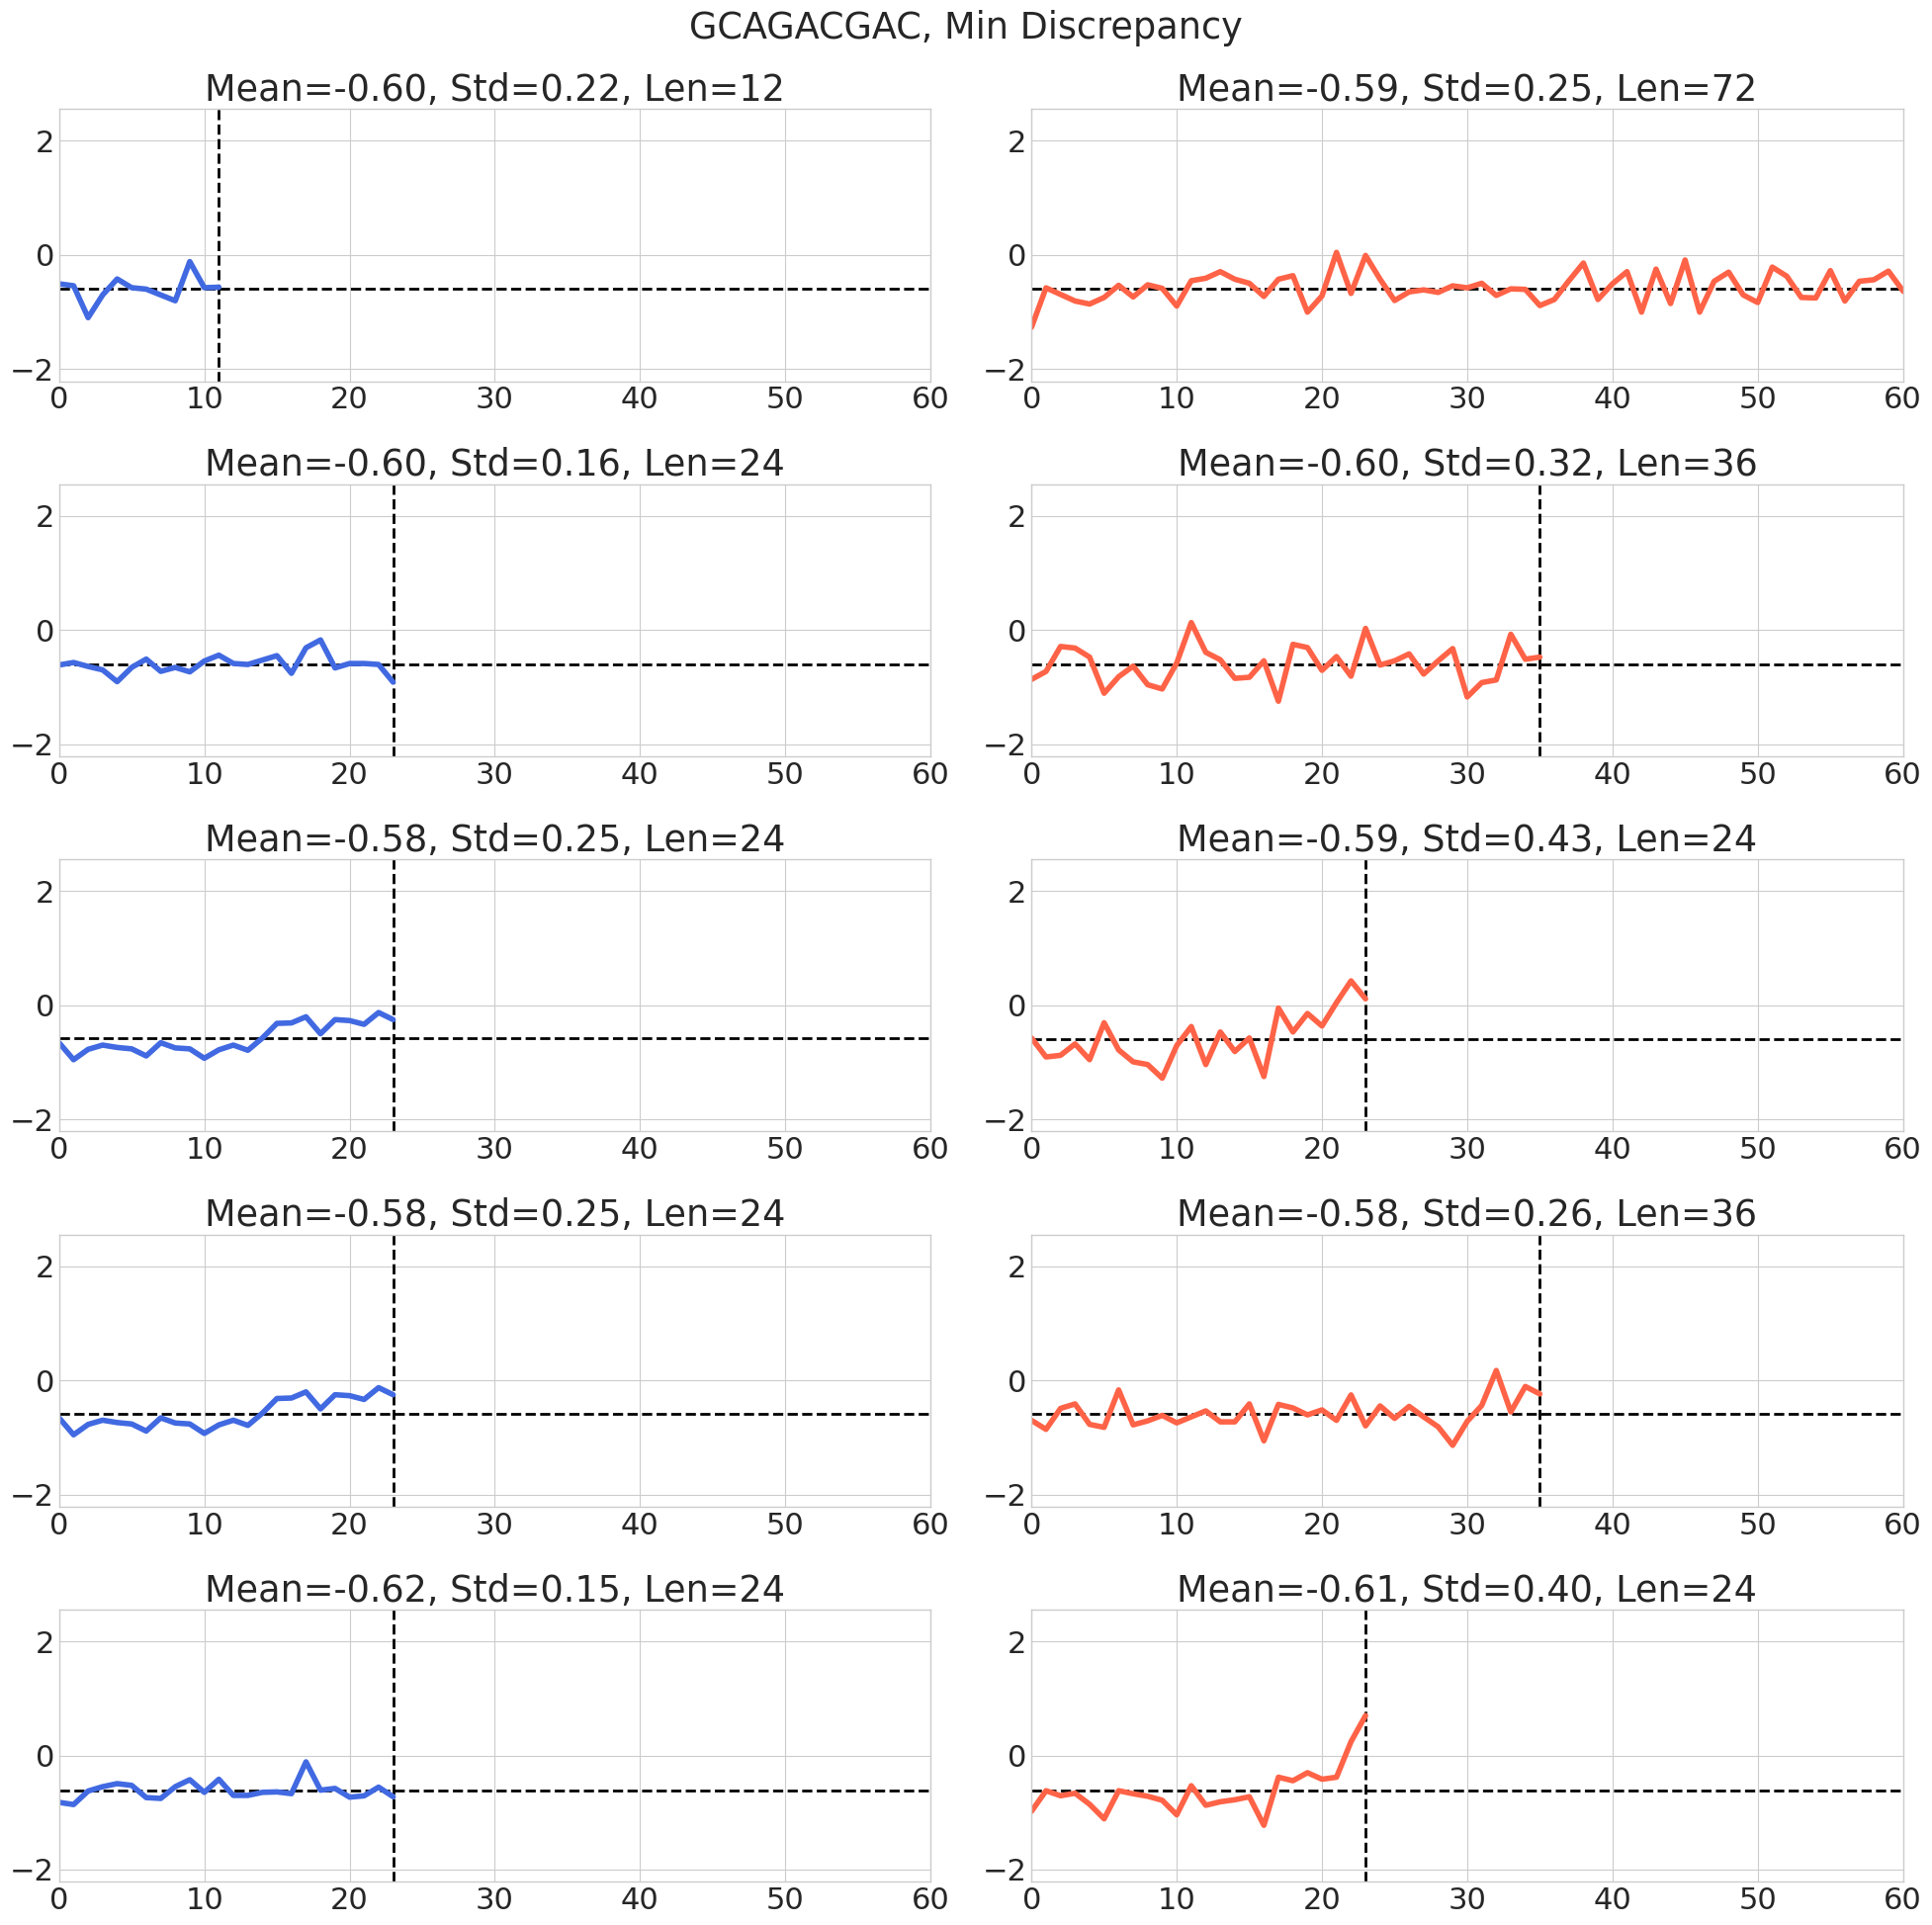

((0, 60), (-2.2118645, 2.5573409))

In [142]:
i = 1
xlim, ylim = plot_motif(motifs[i]+", Max Discrepancy", max_pair_dict_rev[motifs[i]]["index_ON0093"], max_pair_dict_rev[motifs[i]]["index_ON0099"])
plot_motif(motifs[i]+", Min Discrepancy", min_pair_dict_rev[motifs[i]]["index_ON0093"], min_pair_dict_rev[motifs[i]]["index_ON0099"],xlim, ylim)

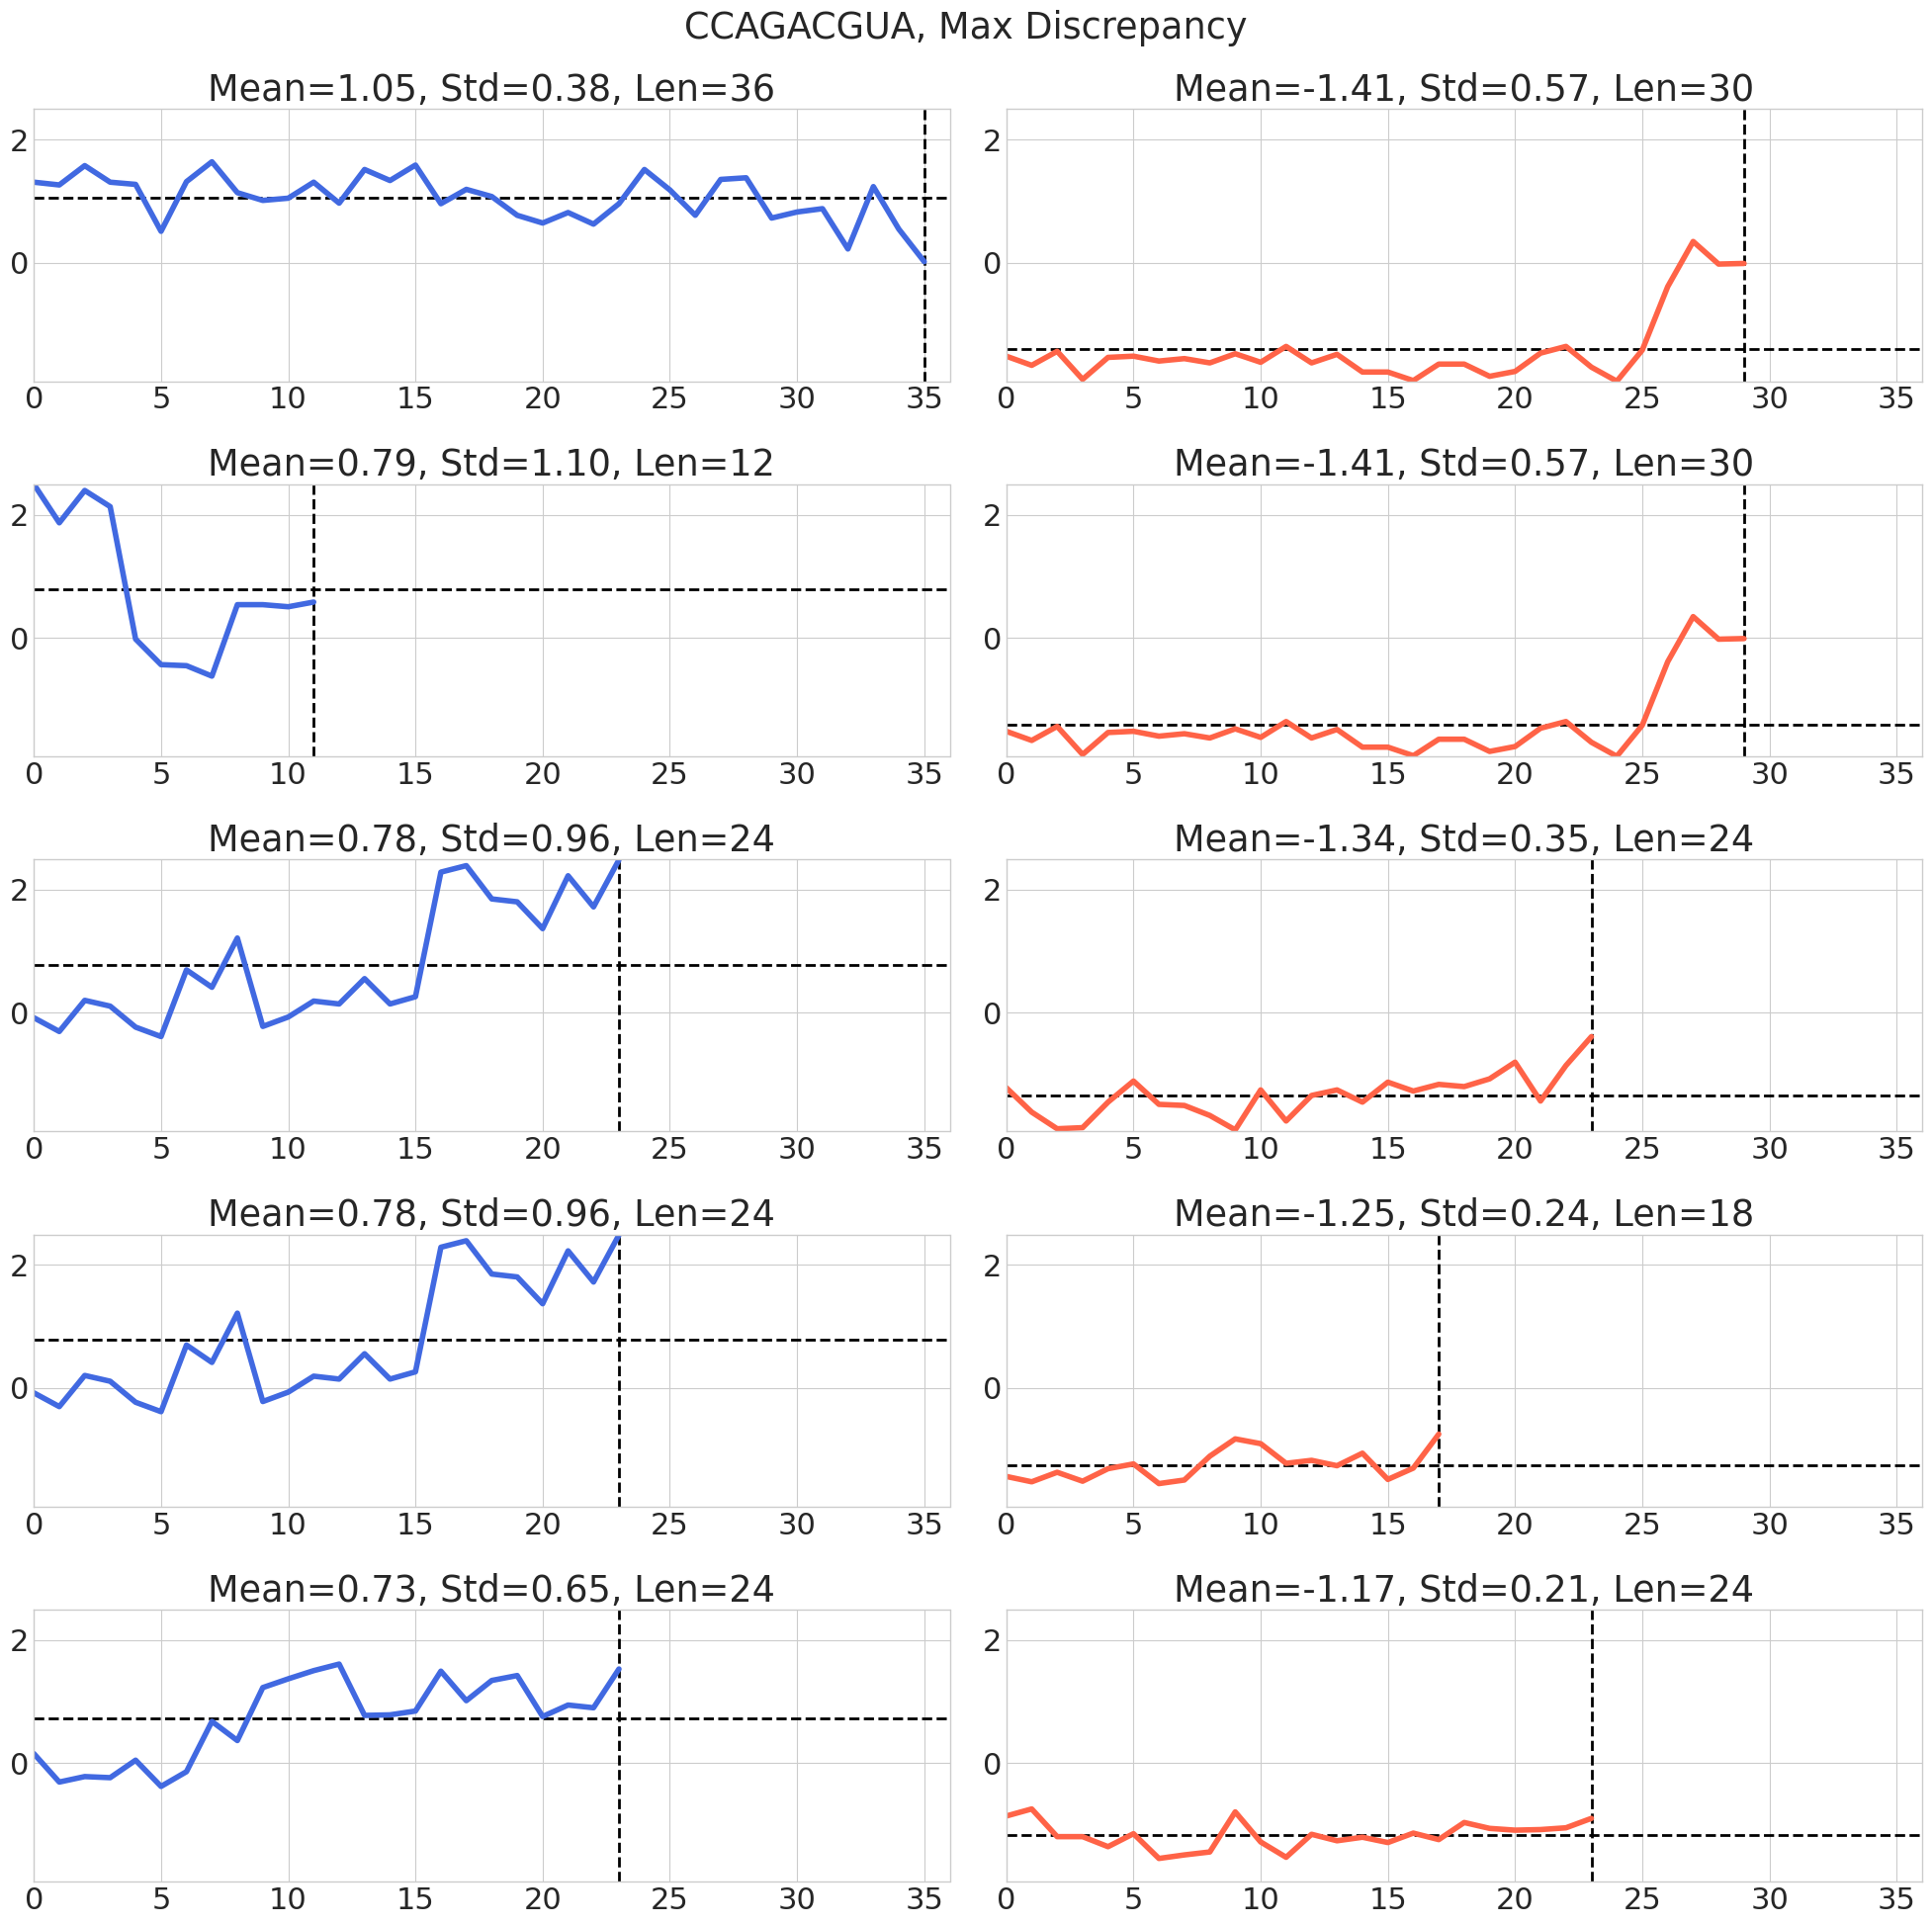

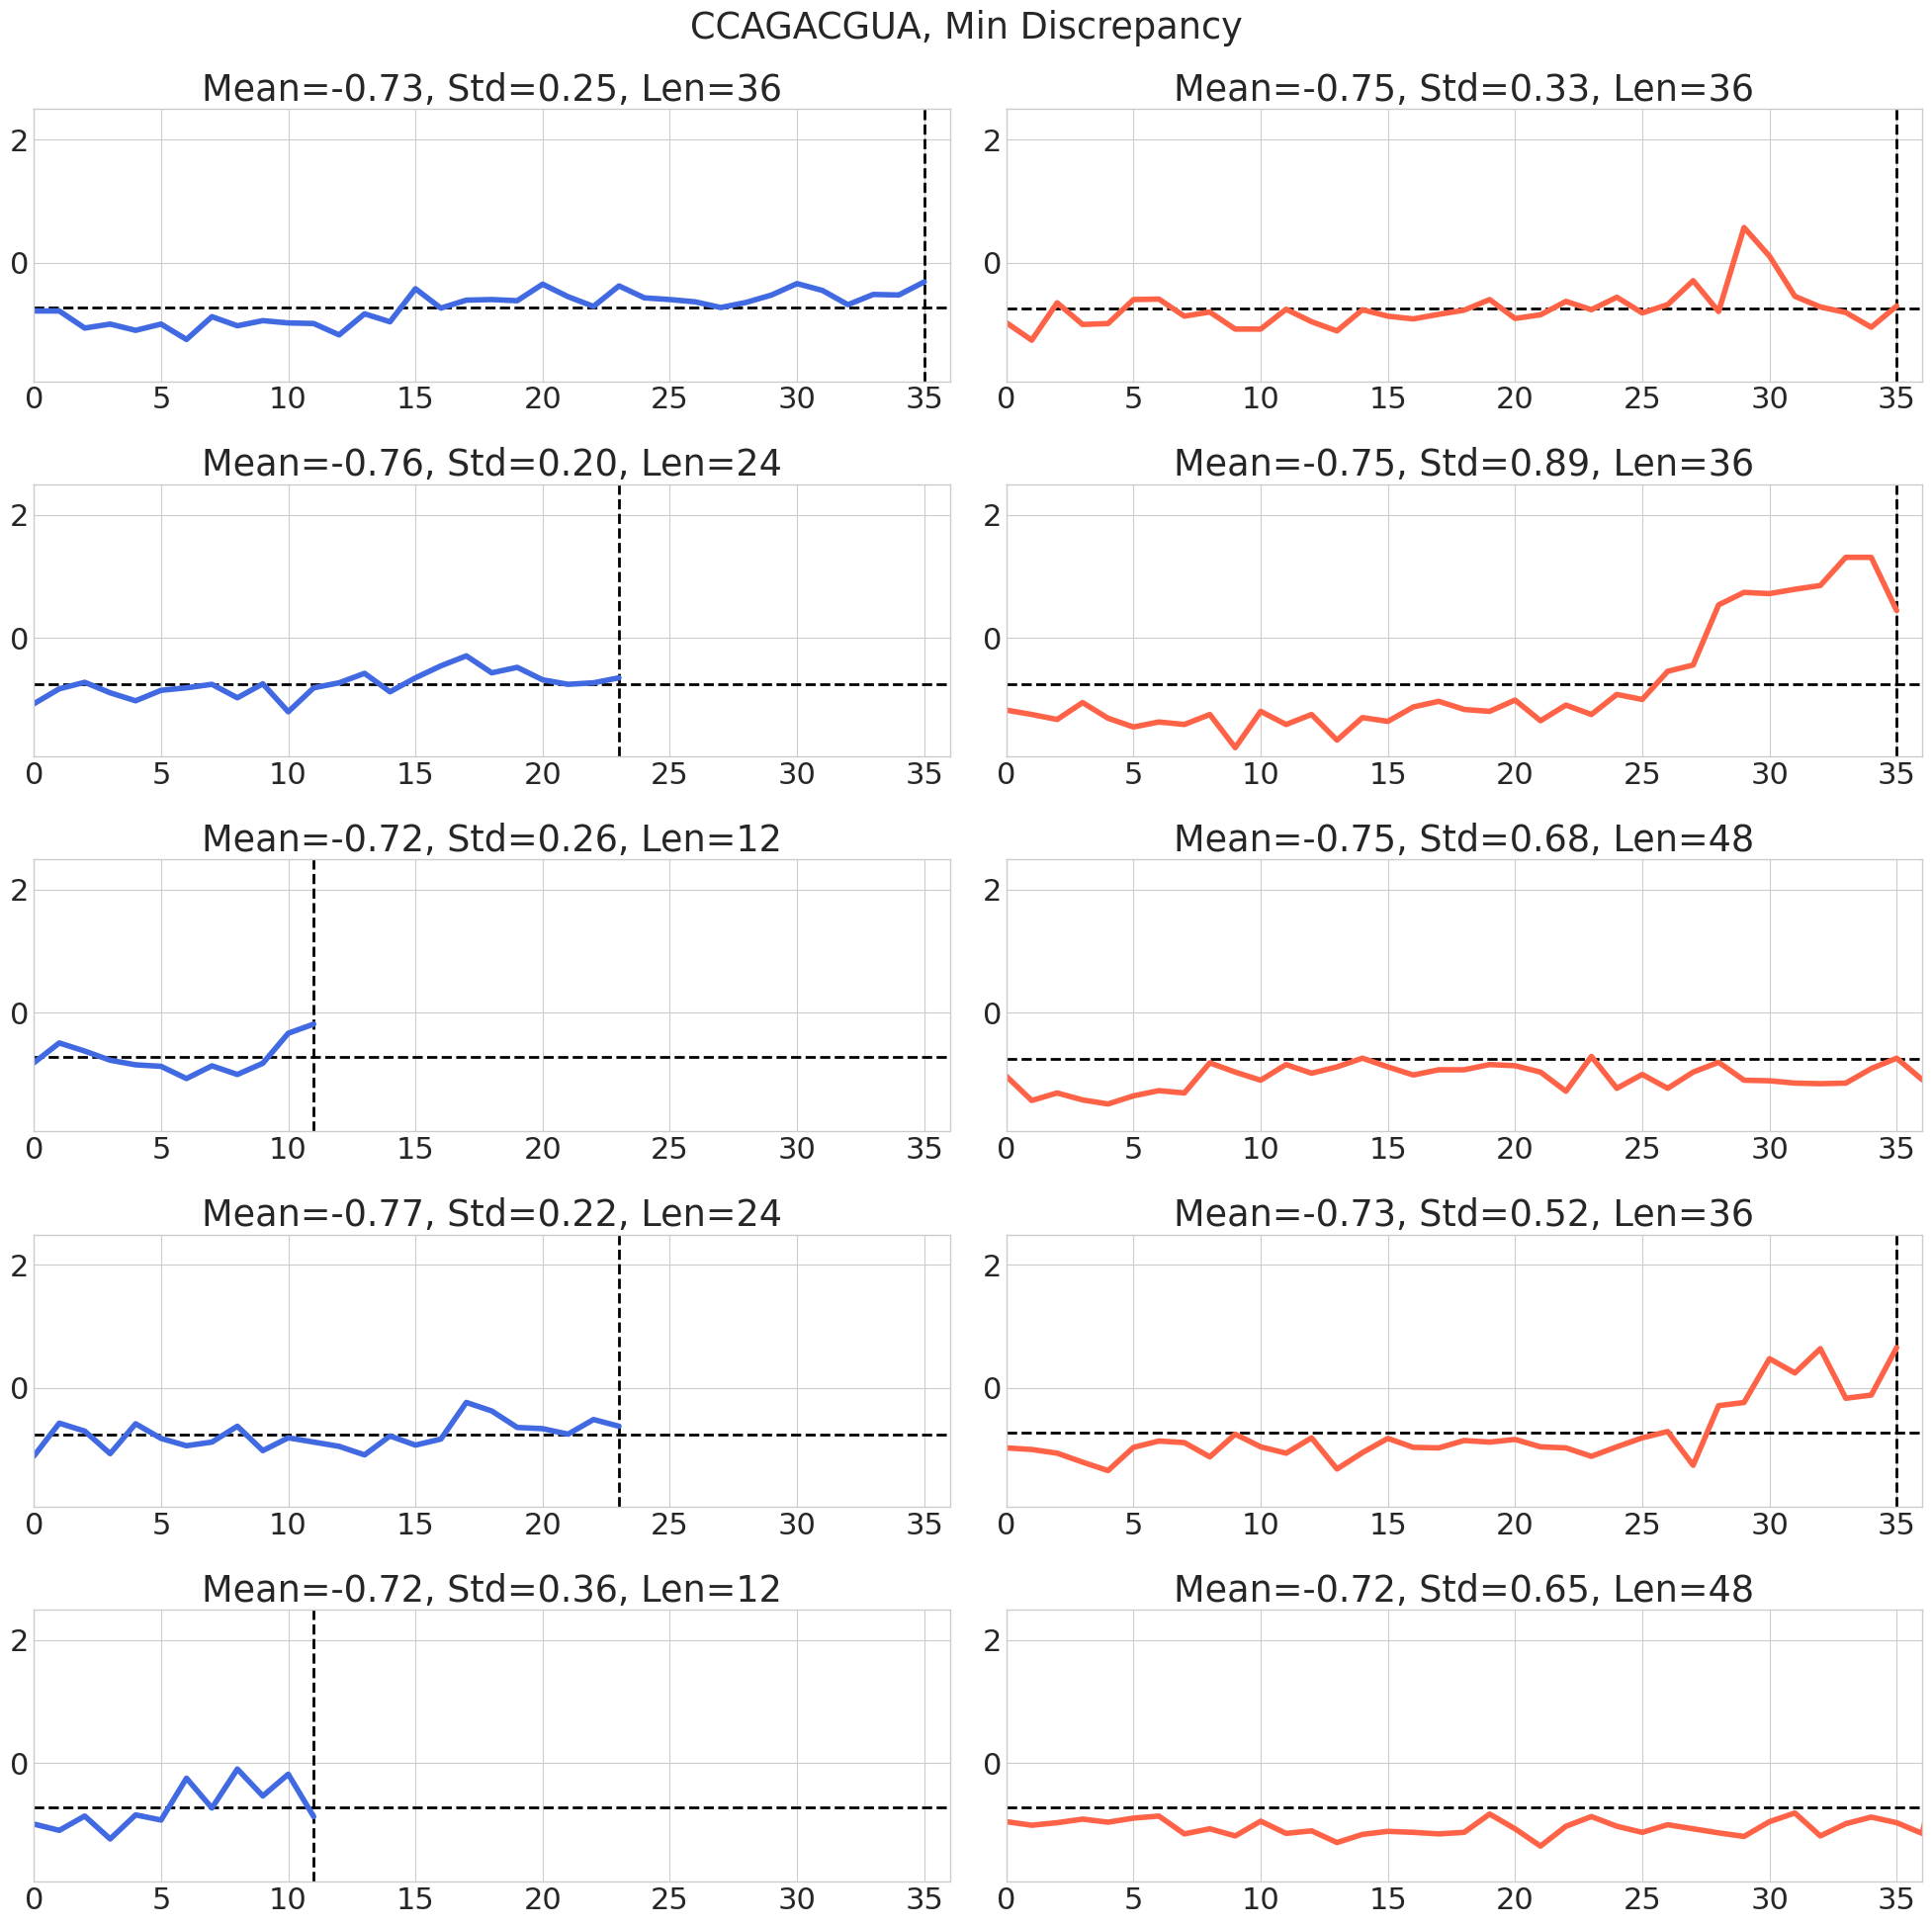

((0, 36), (-1.926851, 2.4945762))

In [143]:
i = 2
xlim, ylim = plot_motif(motifs[i]+", Max Discrepancy", max_pair_dict_rev[motifs[i]]["index_ON0093"], max_pair_dict_rev[motifs[i]]["index_ON0099"])
plot_motif(motifs[i]+", Min Discrepancy", min_pair_dict_rev[motifs[i]]["index_ON0093"], min_pair_dict_rev[motifs[i]]["index_ON0099"],xlim, ylim)

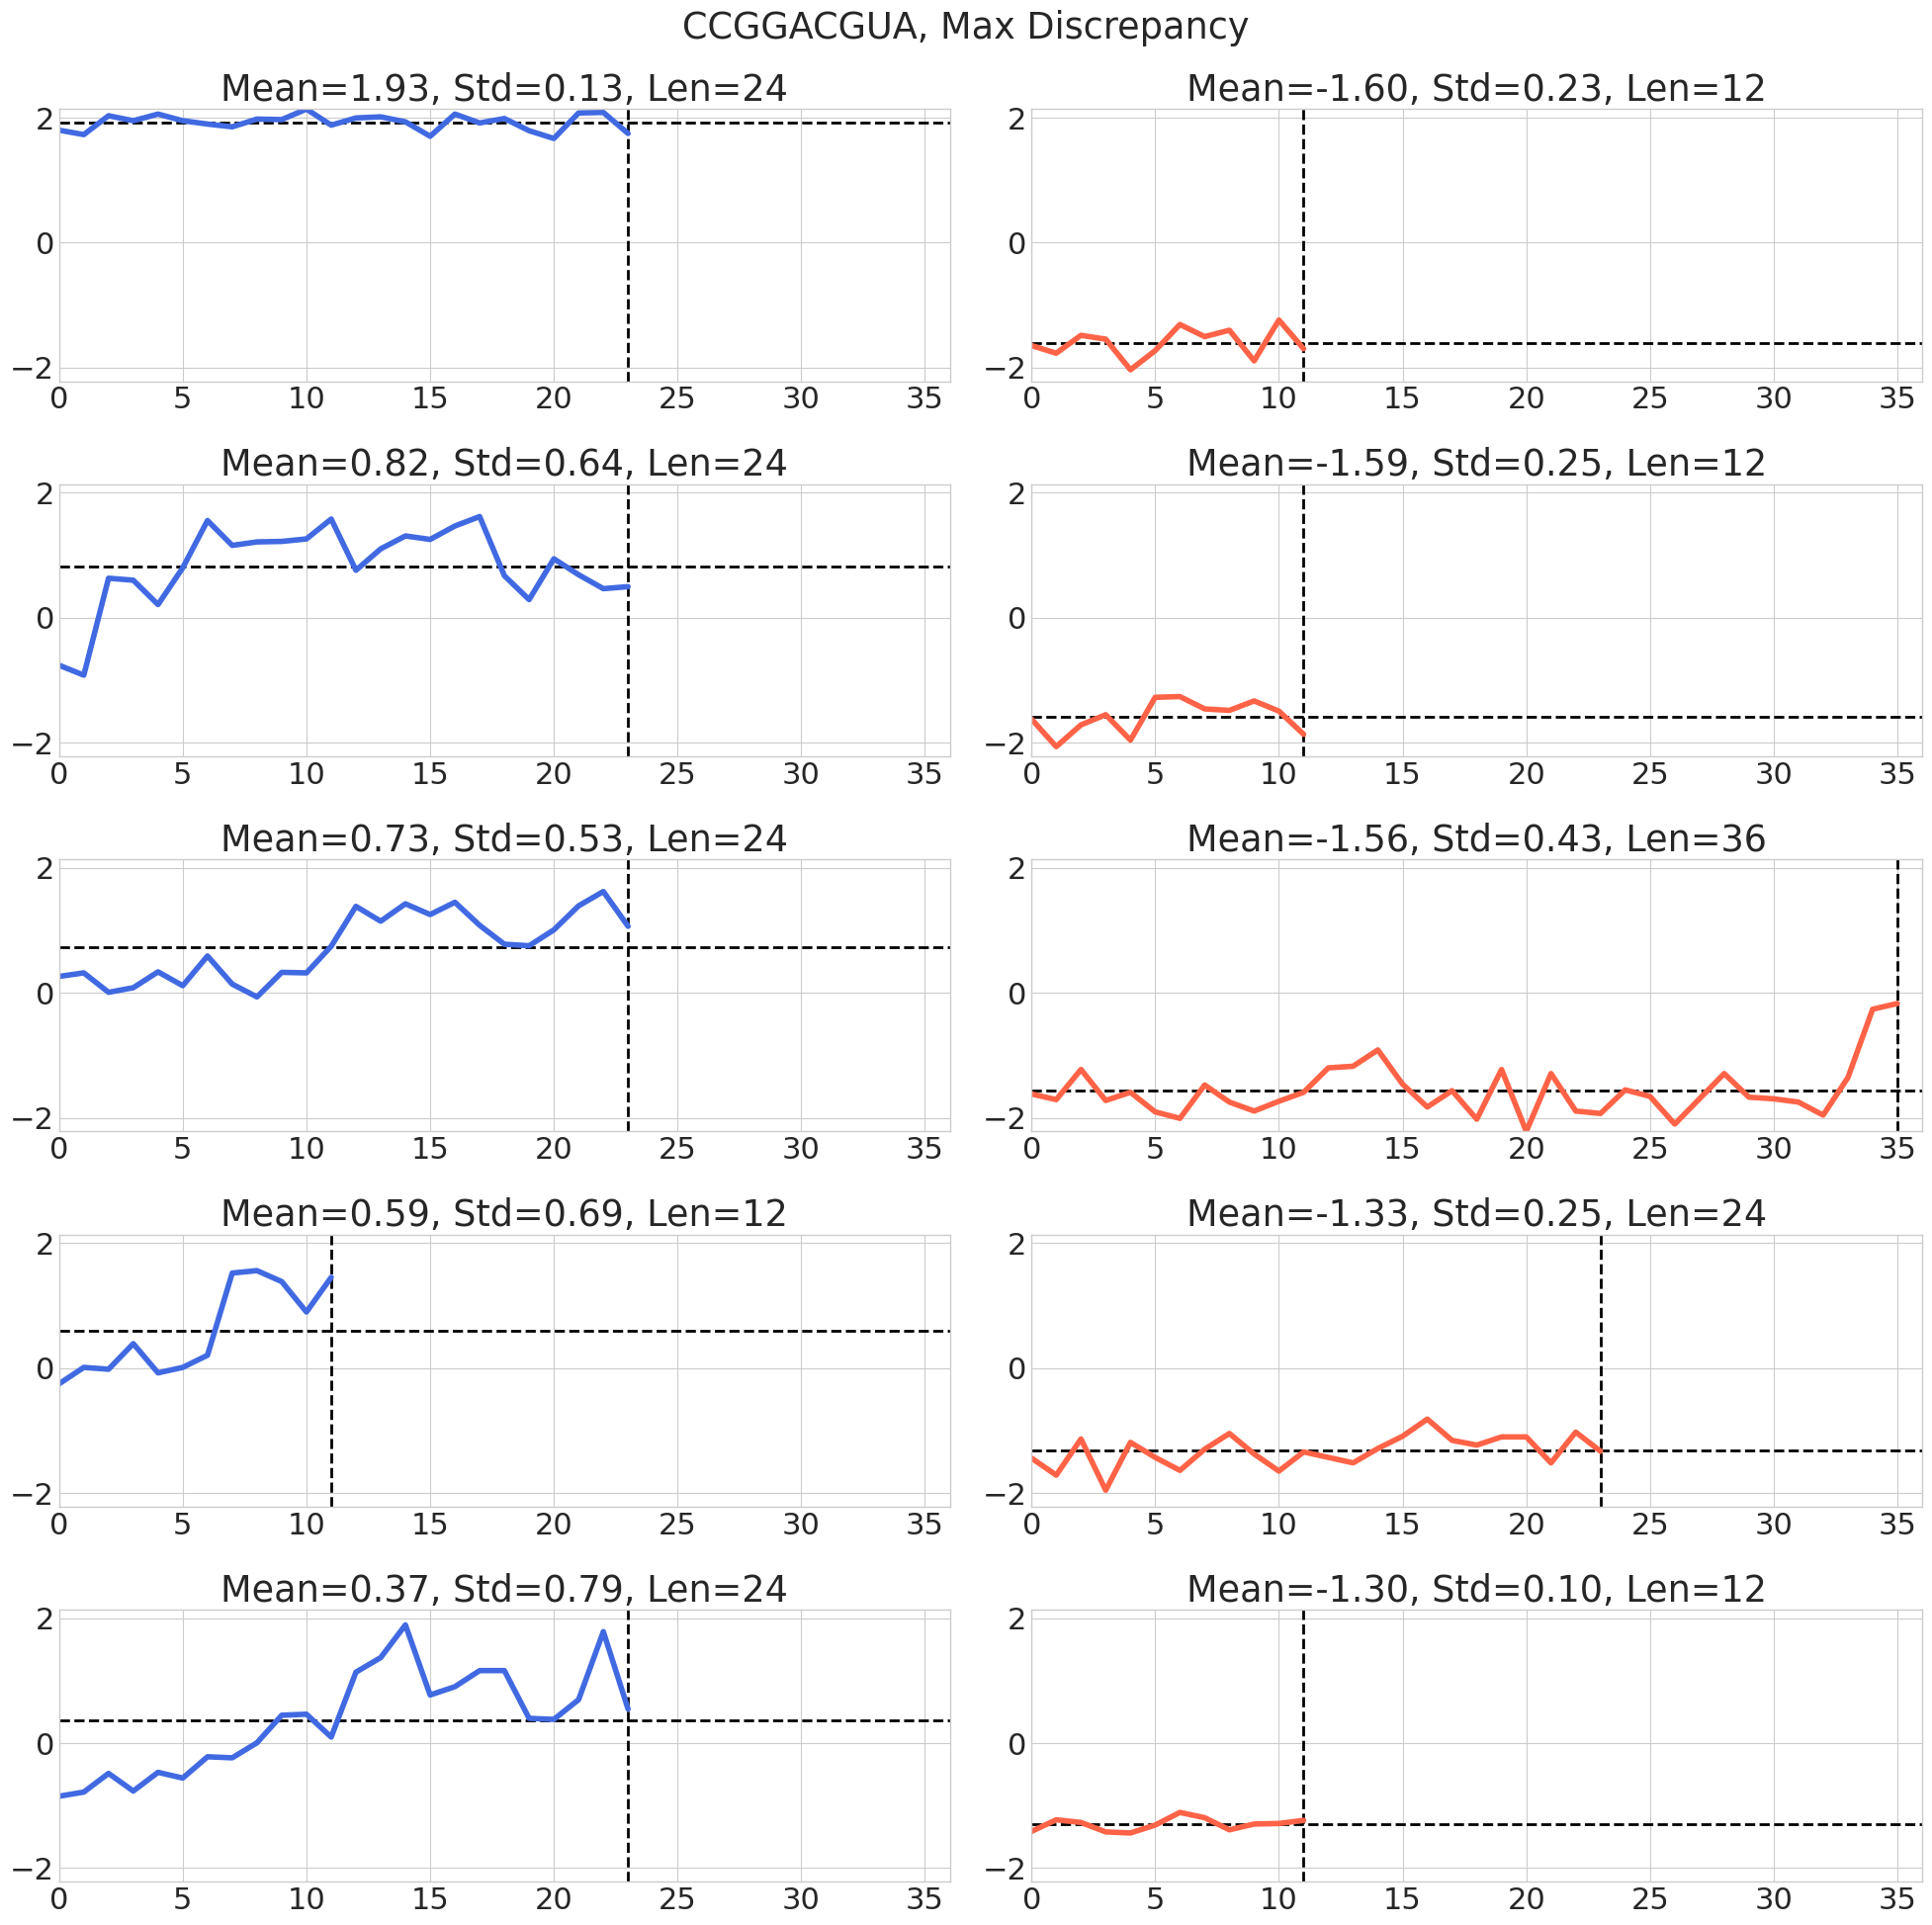

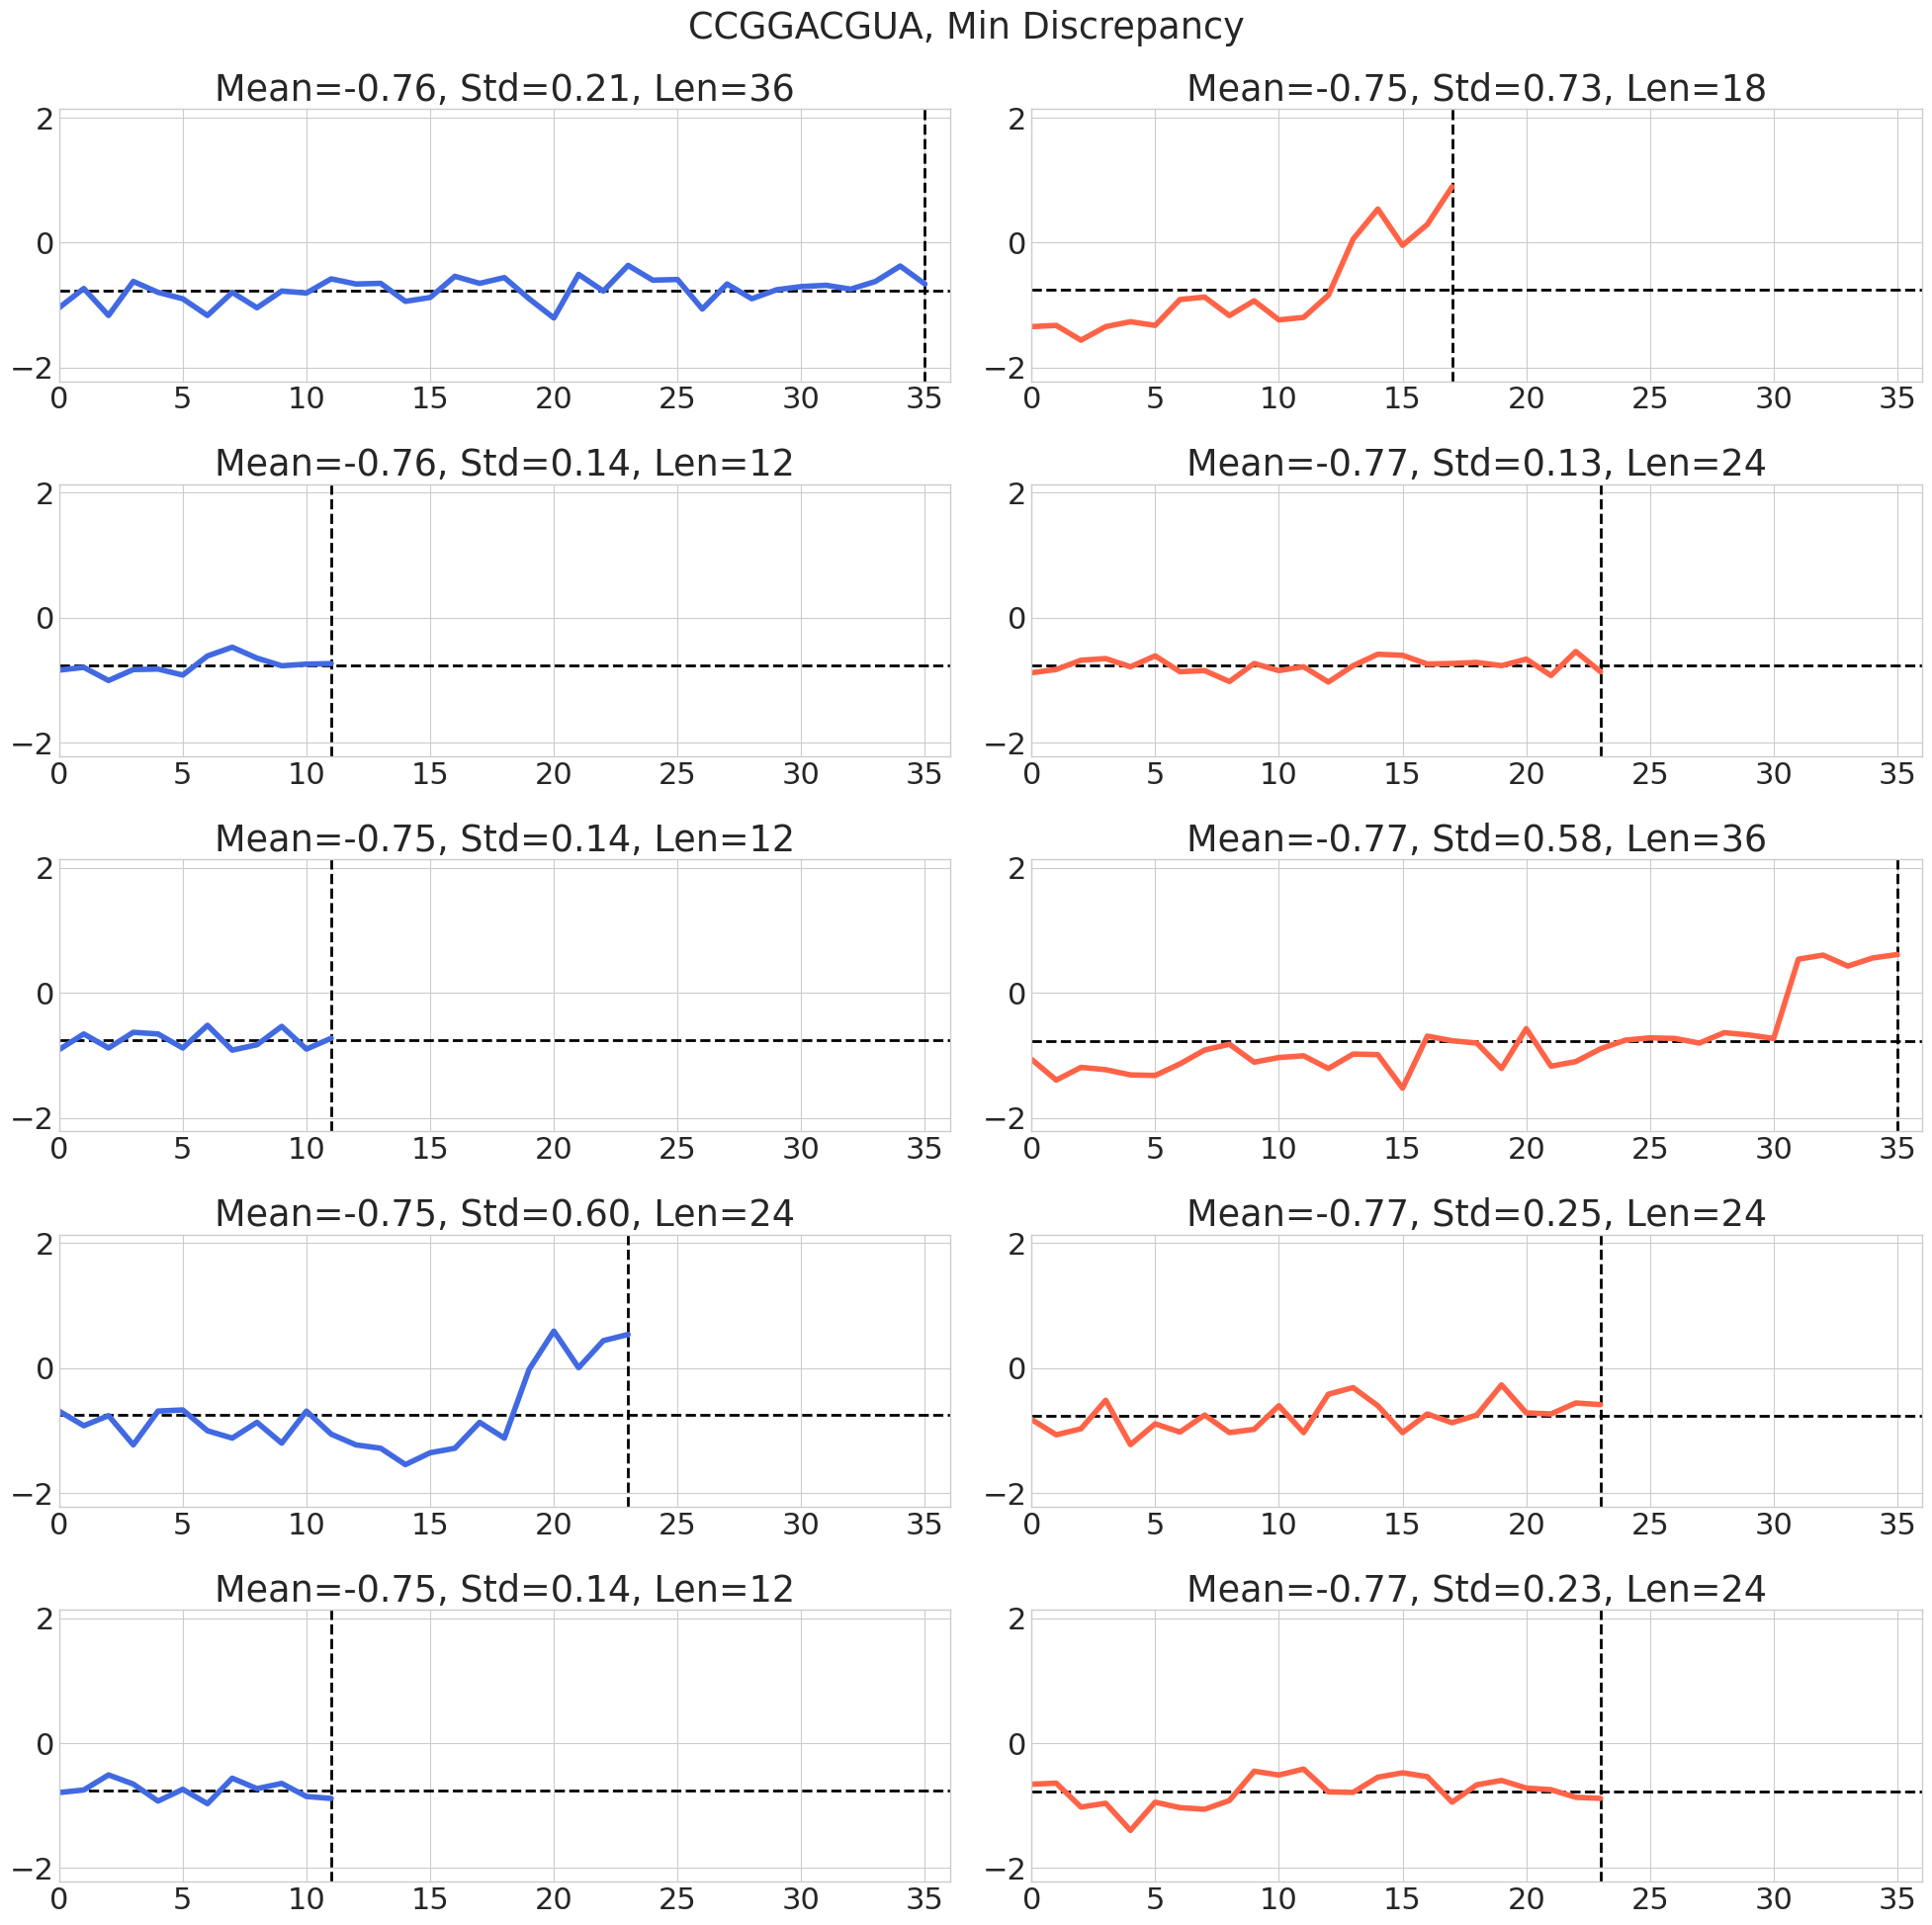

((0, 36), (-2.2159061, 2.1386104))

In [145]:
i = 3
xlim, ylim = plot_motif(motifs[i]+", Max Discrepancy", max_pair_dict_rev[motifs[i]]["index_ON0093"], max_pair_dict_rev[motifs[i]]["index_ON0099"])
plot_motif(motifs[i]+", Min Discrepancy", min_pair_dict_rev[motifs[i]]["index_ON0093"], min_pair_dict_rev[motifs[i]]["index_ON0099"],xlim, ylim)

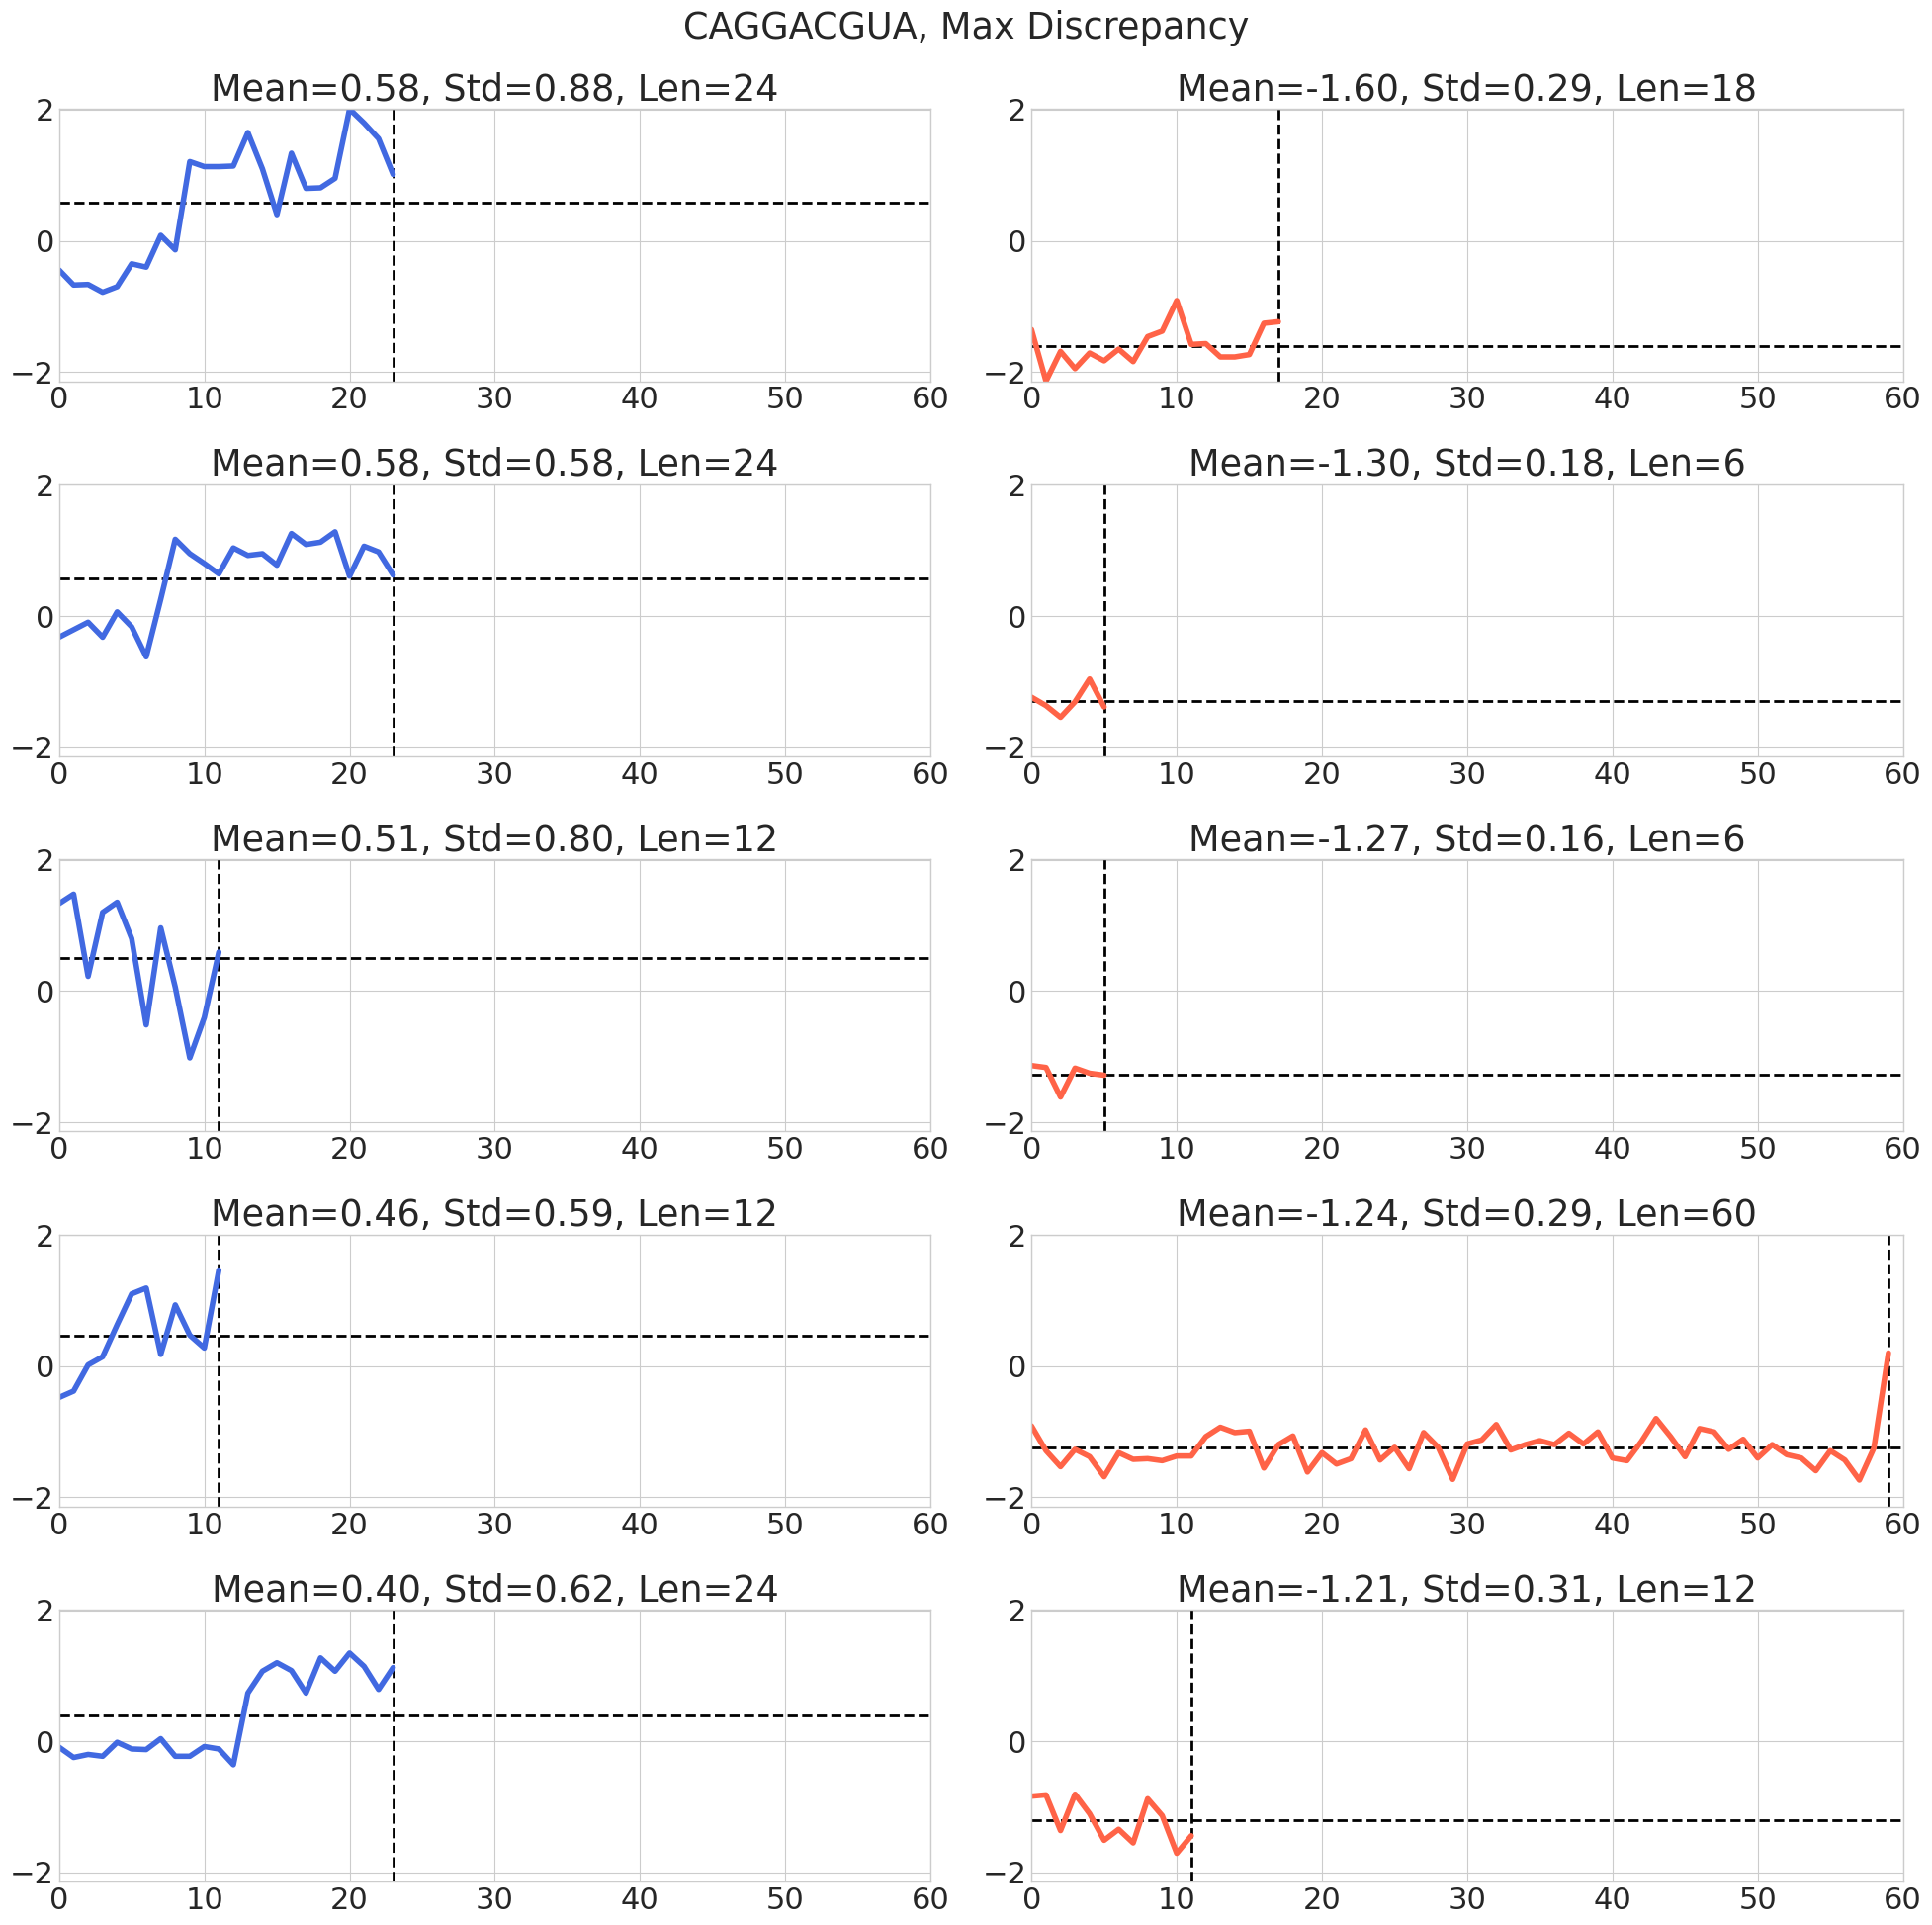

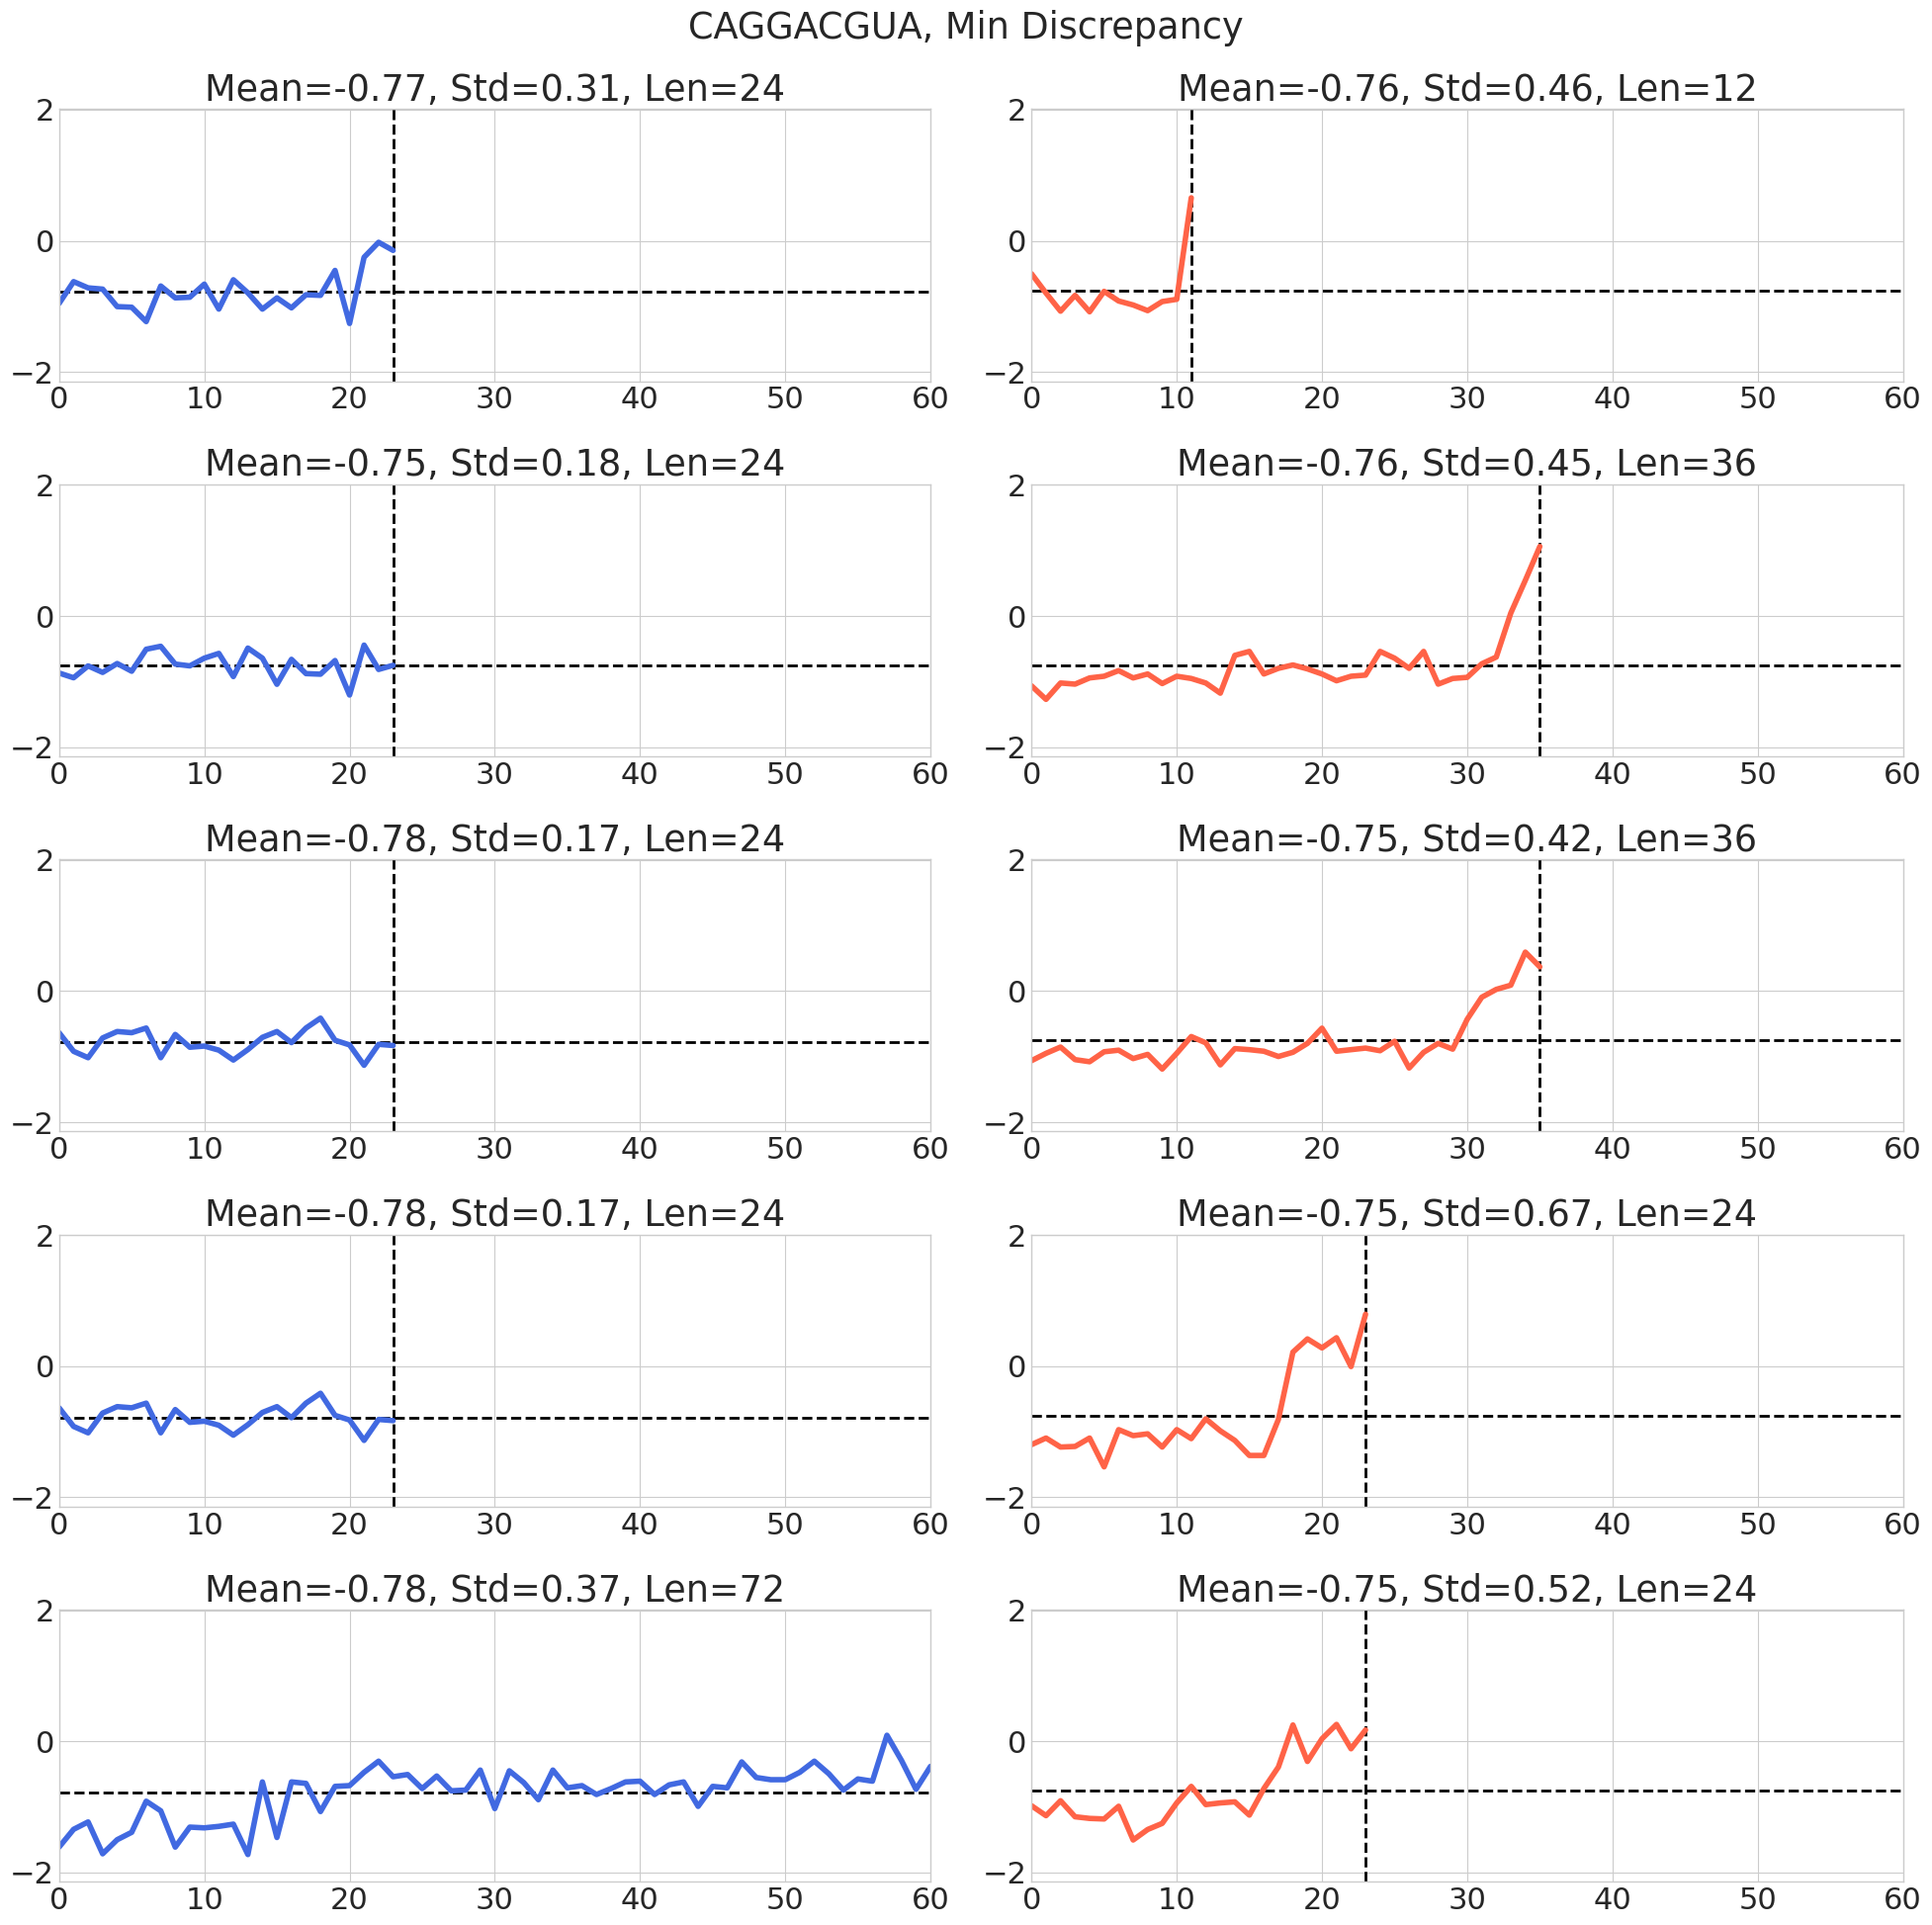

((0, 60), (-2.1394126, 2.0100503))

In [146]:
i = 4
xlim, ylim = plot_motif(motifs[i]+", Max Discrepancy", max_pair_dict_rev[motifs[i]]["index_ON0093"], max_pair_dict_rev[motifs[i]]["index_ON0099"])
plot_motif(motifs[i]+", Min Discrepancy", min_pair_dict_rev[motifs[i]]["index_ON0093"], min_pair_dict_rev[motifs[i]]["index_ON0099"],xlim, ylim)

In [147]:
print(discrepancy_df)

           ON0093_norm  ON0099_norm   discrepancy
9mer                                             
GCUGAGUCC    -0.182018     1.638651  1.820669e+00
AAACAGACA    -0.025884     1.739035  1.764919e+00
CUUCAGUCC    -0.412376     1.332758  1.745134e+00
AAUCAGUCC    -0.350024     1.381722  1.731746e+00
CAACAGACG    -0.139401     1.581028  1.720429e+00
...                ...          ...           ...
AGCCAUAUU     0.116022     0.116005  1.662987e-05
UGGUAUGCC    -0.457865    -0.457877  1.211402e-05
GCGCACUGC    -0.033575    -0.033566  8.872534e-06
GUCGACGGC    -0.201281    -0.201279  1.643737e-06
UACAAUGCC    -0.356716    -0.356715  6.309868e-07

[18641 rows x 3 columns]


In [148]:
print(ON0093_df_norm)

                          motif  cb_idx  bq_centre  signal_centre     bq_avg  \
0         ACAUGGUAGGAGGCCGGCAGA       0         31       1.157053  19.462401   
1         AUUUUAACACAUUCCGACUAU       2          6      -0.540162  10.195549   
2         UACAUGCAGCAGUUAGUGAGG       2         15      -0.317551  20.876060   
3         GCUGCCCAGGAUGGGUCGCAC       2         14       0.916022  19.197981   
4         CUGAGCAUCCAGCAAUCACUA       0         28       1.201399  17.122427   
...                         ...     ...        ...            ...        ...   
11068993  AAGUGCCCCUAAUGGGCUUAU       2         29      -0.003359  18.114360   
11068994  UGUGCGCUCCAAGUACUAUGC       1         19       2.678680  16.868136   
11068995  AACUAUGAUUAAGAUUUGUUC       2         23       2.644863  12.048876   
11068996  UGCAGCUUGCACGCUGCGCUC       0         34      -0.623835  23.430558   
11068997  AUCCAACUGUAACUGCGACGC       1         17      -0.056497  22.180492   

          signal_avg  signal_3mer  sign

In [150]:
ON0099_grouped = ON0099_df_norm.groupby("9mer")
ON0093_grouped = ON0093_df_norm.groupby("9mer")

def get_distribution(motif_list):
    motif_dict = {}
    for motif in motif_list:
        ON0093_df = ON0093_grouped.get_group(motif)
        ON0099_df = ON0099_grouped.get_group(motif)
        motif_dict[motif] = (ON0093_df["signal_centre"].values, ON0099_df["signal_centre"].values)
    return motif_dict


In [163]:
ON0093_df_unnorm_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0093/ON0093/result/dorado-070/intermediates/segmented_tokenized/signal_analysis_unnorm/temp.merged.light.pkl"
ON0099_df_unnorm_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/signal_analysis_unnorm/temp.merged.light.pkl"

ON0093_df_unnorm = pd.read_pickle(ON0093_df_unnorm_path)
ON0099_df_unnorm = pd.read_pickle(ON0099_df_unnorm_path)

In [165]:
ON0093_df_unnorm["9mer"] = ON0093_df_unnorm["motif"].apply(lambda x: x[6:15])
ON0099_df_unnorm["9mer"] = ON0099_df_unnorm["motif"].apply(lambda x: x[6:15])

In [166]:
ON0099_grouped_unnorm = ON0099_df_unnorm.groupby("9mer")
ON0093_grouped_unnorm = ON0093_df_unnorm.groupby("9mer")

def get_distribution_unnorm(motif_list):
    motif_dict = {}
    for motif in motif_list:
        ON0093_df = ON0093_grouped_unnorm.get_group(motif)
        ON0099_df = ON0099_grouped_unnorm.get_group(motif)
        motif_dict[motif] = (ON0093_df["signal_centre"].values, ON0099_df["signal_centre"].values)
    return motif_dict


In [167]:
distribution_dict_unnorm = get_distribution_unnorm(discrepancy_df.index[:20])
distribution_dict_unnorm_rev = get_distribution_unnorm(discrepancy_df_rev.index[:20])

In [151]:
distribution_dict = get_distribution(discrepancy_df.index[:20])
distribution_dict_rev = get_distribution(discrepancy_df_rev.index[:20])


In [159]:
def plot_distribution(distribution_dict, title):
    fig, axes = plt.subplots(4, 5, figsize = (20,10))
    for i, motif in enumerate(distribution_dict.keys()):
        ON0093_signal = distribution_dict[motif][0]
        ON0099_signal = distribution_dict[motif][1]
        sns.histplot(ON0093_signal, ax = axes[i//5, i%5], color = "royalblue", bins = 50, stat="density", fill=False,
                     linewidth = 3, element="step", common_norm = False)
        sns.histplot(ON0099_signal, ax = axes[i//5, i%5], color = "tomato", bins = 50, stat="density", fill=False,
                     linewidth = 3, element="step", common_norm = False)
        
        ## Vline at the mean
        axes[i//5, i%5].axvline(ON0093_signal.mean(), color = "royalblue", ls = "--", lw = 2)
        axes[i//5, i%5].axvline(ON0099_signal.mean(), color = "tomato", ls = "--", lw = 2)
    
        axes[i//5, i%5].set_title(motif)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-

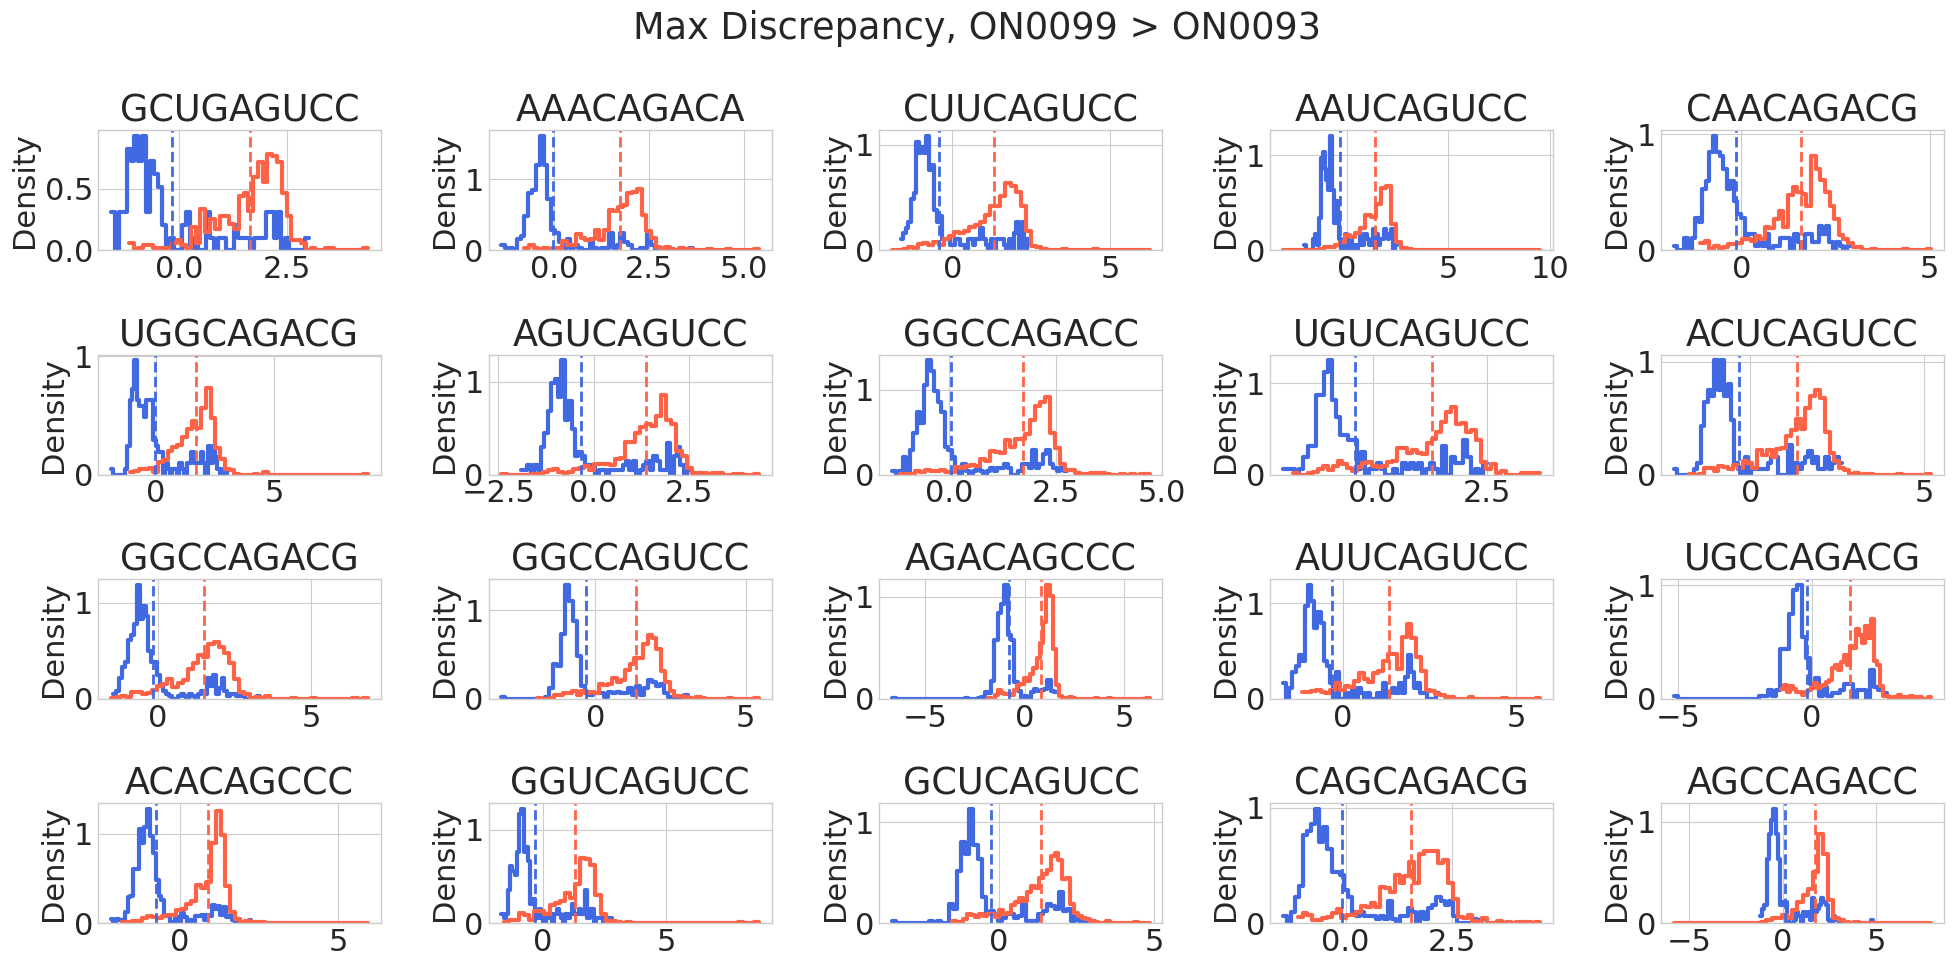

In [160]:
plot_distribution(distribution_dict, "Max Discrepancy, ON0099 > ON0093")

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-

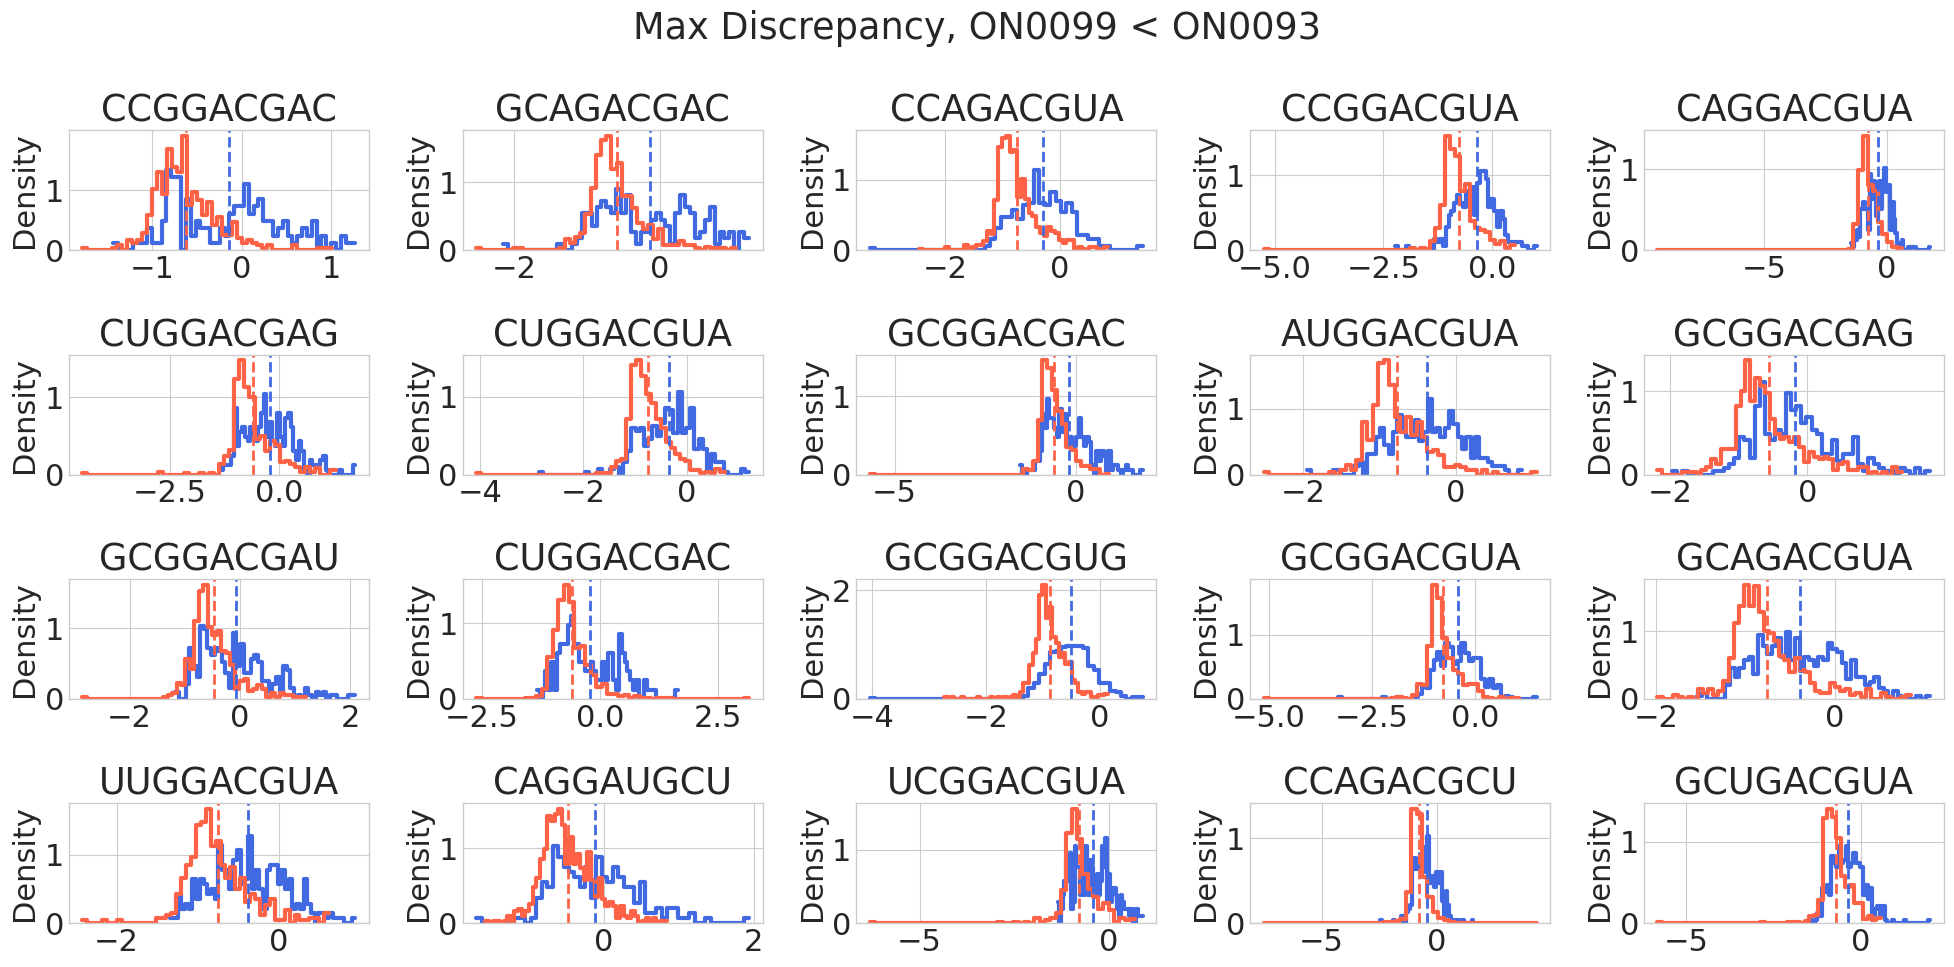

In [162]:
plot_distribution(distribution_dict_rev, "Max Discrepancy, ON0099 < ON0093")

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-

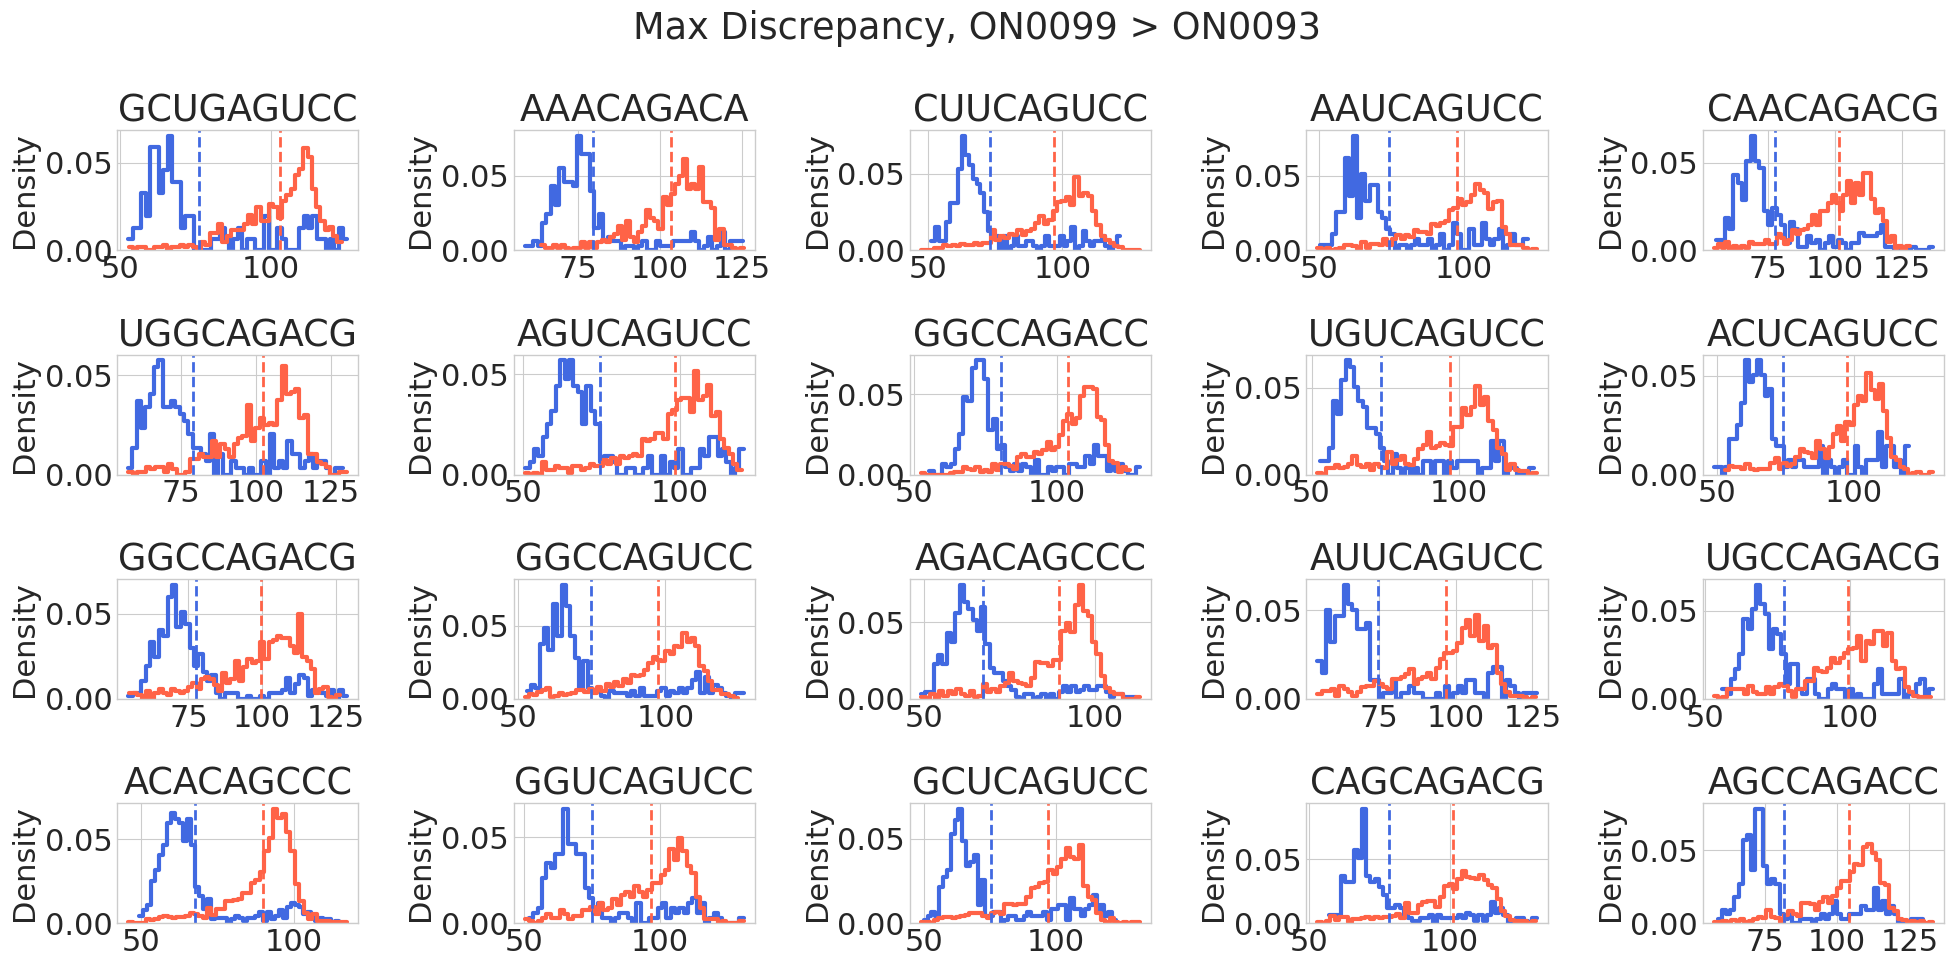

In [168]:
plot_distribution(distribution_dict_unnorm, "Max Discrepancy, ON0099 > ON0093")

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-

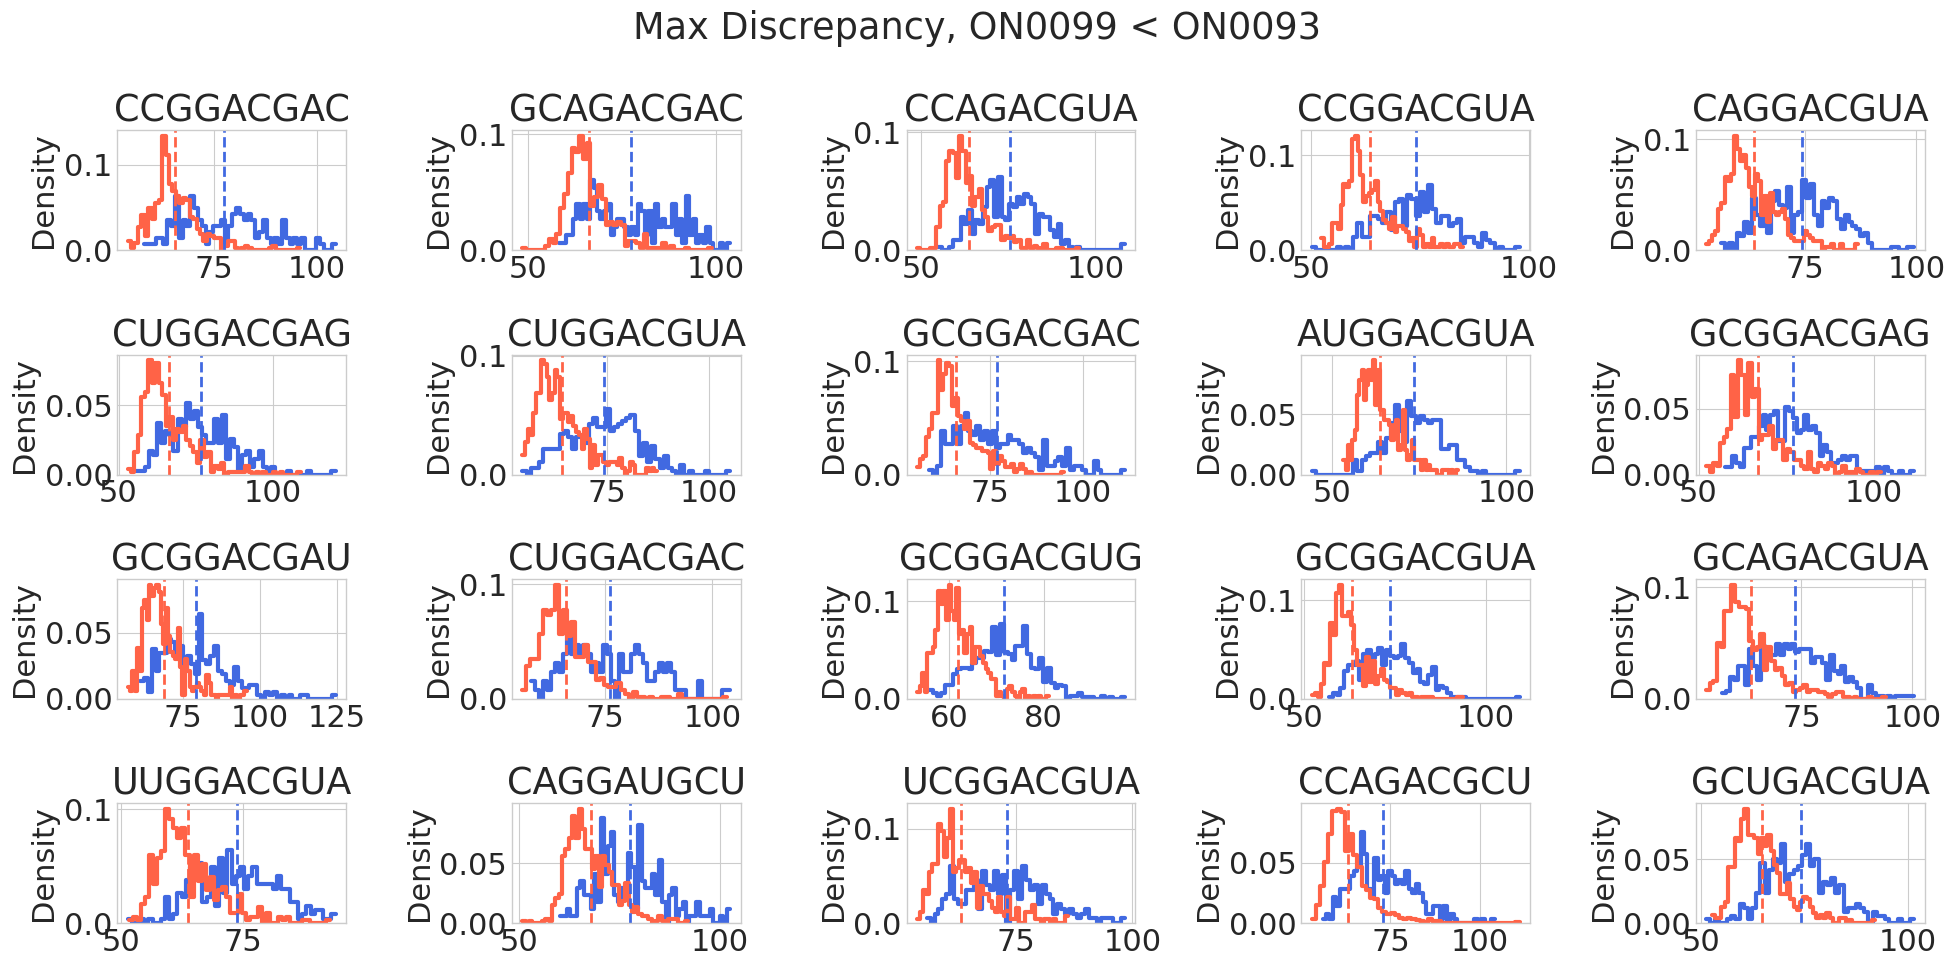

In [169]:
plot_distribution(distribution_dict_unnorm_rev, "Max Discrepancy, ON0099 < ON0093")